<a href="https://colab.research.google.com/github/ISOLCODING/-E2-0.3-F2-0.2-G2-0.5-/blob/main/Analisis_Segmentasi_Sales_Bike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 CELL 1: INSTALL & IMPORT LIBRARY


In [ ]:
# ============================================
# CELL 1: INSTALL & IMPORT SEMUA LIBRARY
# ============================================
!pip install -q plotly statsmodels

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

#visulization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

#time series
from statsmodels.tsa.seasonal import seasonal_decompose

#rfm CLUSTERING
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#warning filtters
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Tampilan Plotly interaktif di Colab
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# Set opsi pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Semua library berhasil di-import!")
print(f" Versi pandas: {pd.__version__}")
print(f" Versi plotly: {px.__version__ if hasattr(px, '__version__') else 'installed'}")

Semua library berhasil di-import!
 Versi pandas: 2.2.2
 Versi plotly: installed



# CELL 2: LOAD DATA


In [ ]:
# ============================================
# CELL 2: LOAD DATA
# ============================================

# Upload file dari local
from google.colab import files
print(" Silakan upload file CSV dataset...")
uploaded = files.upload()

# Ambil nama file yang di-upload
filename = list(uploaded.keys())[0]
print(f"File terdeteksi: {filename}")

# Load ke DataFrame
df = pd.read_csv(filename)
print(f"\n Data berhasil di-load!")
print(f" Shape dataset: {df.shape[0]} baris × {df.shape[1]} kolom")

# Lihat 5 data pertama
print("\nPREVIEW 5 DATA PERTAMA:")
display(df.head())

# Lihat 5 data terakhir
print("\nPREVIEW 5 DATA TERAKHIR:")
display(df.tail())

# Cek nama kolom
print("\n DAFTAR KOLOM:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# Info tipe data
print("\nℹ INFO TIPE DATA:")
df.info()

 Silakan upload file CSV dataset...


Saving Sales.csv to Sales.csv
File terdeteksi: Sales.csv

 Data berhasil di-load!
 Shape dataset: 113036 baris × 18 kolom

PREVIEW 5 DATA PERTAMA:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418



PREVIEW 5 DATA TERAKHIR:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260
113035,2016-03-04,4,March,2016,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",23,24,64,655,552,1207



 DAFTAR KOLOM:
   1. Date
   2. Day
   3. Month
   4. Year
   5. Customer_Age
   6. Age_Group
   7. Customer_Gender
   8. Country
   9. State
   10. Product_Category
   11. Sub_Category
   12. Product
   13. Order_Quantity
   14. Unit_Cost
   15. Unit_Price
   16. Profit
   17. Cost
   18. Revenue

ℹ INFO TIPE DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  S

#🧹 CELL 3: DATA CLEANING & FEATURE ENGINEERING

In [ ]:
# ============================================
# CELL 3: DATA CLEANING & FEATURE ENGINEERING
# ============================================

print("="*60)
print(" MEMULAI DATA CLEANING & FEATURE ENGINEERING")
print("="*60)

# ---- 3A. CEK MISSING VALUES ----
print("\nJUMLAH MISSING VALUES PER KOLOM:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0])

# Jika tidak ada missing values
if missing.sum() == 0:
    print(" Tidak ada missing values!")

# ---- 3B. CEK DUPLIKAT ----
duplicates = df.duplicated().sum()
print(f"\n Jumlah duplikat: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f" {duplicates} duplikat berhasil dihapus!")
else:
    print("Tidak ada duplikat!")

# ---- 3C. KONVERSI KOLOM TANGGAL ----
print("\n MEMPROSES KOLOM TANGGAL...")

# Cari kolom tanggal (biasanya 'Date')
date_col = None
for col in df.columns:
    if 'date' in col.lower():
        date_col = col
        break

if date_col:
    print(f"   Kolom tanggal ditemukan: '{date_col}'")
    # Konversi ke datetime
    df[date_col] = pd.to_datetime(df[date_col])

    # Ekstrak komponen waktu
    df['Year'] = df[date_col].dt.year
    df['Month'] = df[date_col].dt.month
    df['Month_Name'] = df[date_col].dt.month_name()
    df['Quarter'] = df[date_col].dt.quarter
    df['Day_of_Week'] = df[date_col].dt.day_name()
    df['Day'] = df[date_col].dt.day
    df['Week'] = df[date_col].dt.isocalendar().week.astype(int)

    print("    Komponen waktu berhasil diekstrak:")
    print(f"      - Year, Month, Month_Name, Quarter")
    print(f"      - Day_of_Week, Day, Week")
else:
    print("    Kolom tanggal tidak ditemukan, cek nama kolom secara manual")

# ---- 3D. BUAT AGE GROUP ----
print("\n MEMBUAT AGE GROUP...")

# Cari kolom umur
age_col = None
for col in df.columns:
    if 'age' in col.lower():
        age_col = col
        break

if age_col:
    print(f"   Kolom umur ditemukan: '{age_col}'")

    # Definisi bins dan labels
    bins = [0, 25, 35, 45, 100]
    labels = ['17-25 (Young Adult)', '26-35 (Adult)',
              '36-45 (Middle Age)', '46+ (Senior)']

    df['Age_Group'] = pd.cut(df[age_col], bins=bins, labels=labels, right=True)

    print("    Age group berhasil dibuat:")
    for label in labels:
        count = (df['Age_Group'] == label).sum()
        print(f"      - {label}: {count} data")
else:
    print("    Kolom umur tidak ditemukan")

# ---- 3E. BUAT PROFIT MARGIN ----
print("\n💰 MEMBUAT PROFIT MARGIN...")

if 'Profit' in df.columns and 'Revenue' in df.columns:
    df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100
    print("    Kolom Profit_Margin berhasil dibuat!")
    print(f"      - Rata-rata margin: {df['Profit_Margin'].mean():.2f}%")
    print(f"      - Margin tertinggi: {df['Profit_Margin'].max():.2f}%")
    print(f"      - Margin terendah: {df['Profit_Margin'].min():.2f}%")
else:
    print("    Kolom Profit atau Revenue tidak ditemukan")

# ---- 3F. CEK NILAI NEGATIF / ANOMALI ----
print("\n MENGECEK ANOMALI DATA...")

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()
    if neg_count > 0:
        print(f"    {col}: {neg_count} nilai negatif")
    if zero_count > 0 and col != 'Year':
        print(f"   ℹ️ {col}: {zero_count} nilai nol")

# ---- 3G. STANDARISASI NAMA KOLOM ----
df.columns = df.columns.str.strip().str.replace(' ', '_')
print(f"\n📋 Nama kolom setelah standarisasi:")
print(f"   {list(df.columns)}")

# ---- 3H. TAMPILAN AKHIR ----
print(f"\n{'='*60}")
print(f" DATA CLEANING SELESAI!")
print(f" Shape akhir: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f" Rentang tanggal: {df[date_col].min().date()} s/d {df[date_col].max().date()}")
print(f"{'='*60}")

# Simpan data bersih
df_clean = df.copy()

 MEMULAI DATA CLEANING & FEATURE ENGINEERING

JUMLAH MISSING VALUES PER KOLOM:


,Missing Count,Percentage (%)


 Tidak ada missing values!

 Jumlah duplikat: 1000
 1000 duplikat berhasil dihapus!

 MEMPROSES KOLOM TANGGAL...
   Kolom tanggal ditemukan: 'Date'
    Komponen waktu berhasil diekstrak:
      - Year, Month, Month_Name, Quarter
      - Day_of_Week, Day, Week

 MEMBUAT AGE GROUP...
   Kolom umur ditemukan: 'Customer_Age'
    Age group berhasil dibuat:
      - 17-25 (Young Adult): 20684 data
      - 26-35 (Adult): 39210 data
      - 36-45 (Middle Age): 29817 data
      - 46+ (Senior): 22325 data

💰 MEMBUAT PROFIT MARGIN...
    Kolom Profit_Margin berhasil dibuat!
      - Rata-rata margin: 47.21%
      - Margin tertinggi: 75.00%
      - Margin terendah: -3.70%

 MENGECEK ANOMALI DATA...
    Profit: 58 nilai negatif
   ℹ️ Profit: 424 nilai nol
    Profit_Margin: 58 nilai negatif
   ℹ️ Profit_Margin: 424 nilai nol

📋 Nama kolom setelah standarisasi:
   ['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Pr

#📈 CELL 4: ANALISIS TREN PENJUALAN - Yearly & Monthly

 ANALISIS TREN PENJUALAN - Yearly & Monthly

 4a. Tren Revenue & Profit Per Tahun

  Tren Revenue & Profit Per Tahun:


,Year,Revenue,Profit,Order_Quantity
0,2011,8951966,2877185,5254
1,2012,9133795,2938519,5328
2,2013,15117327,5912432,292144
3,2014,14040192,5818522,376231
4,2015,19945703,7497361,286897
5,2016,17637789,7002220,367851


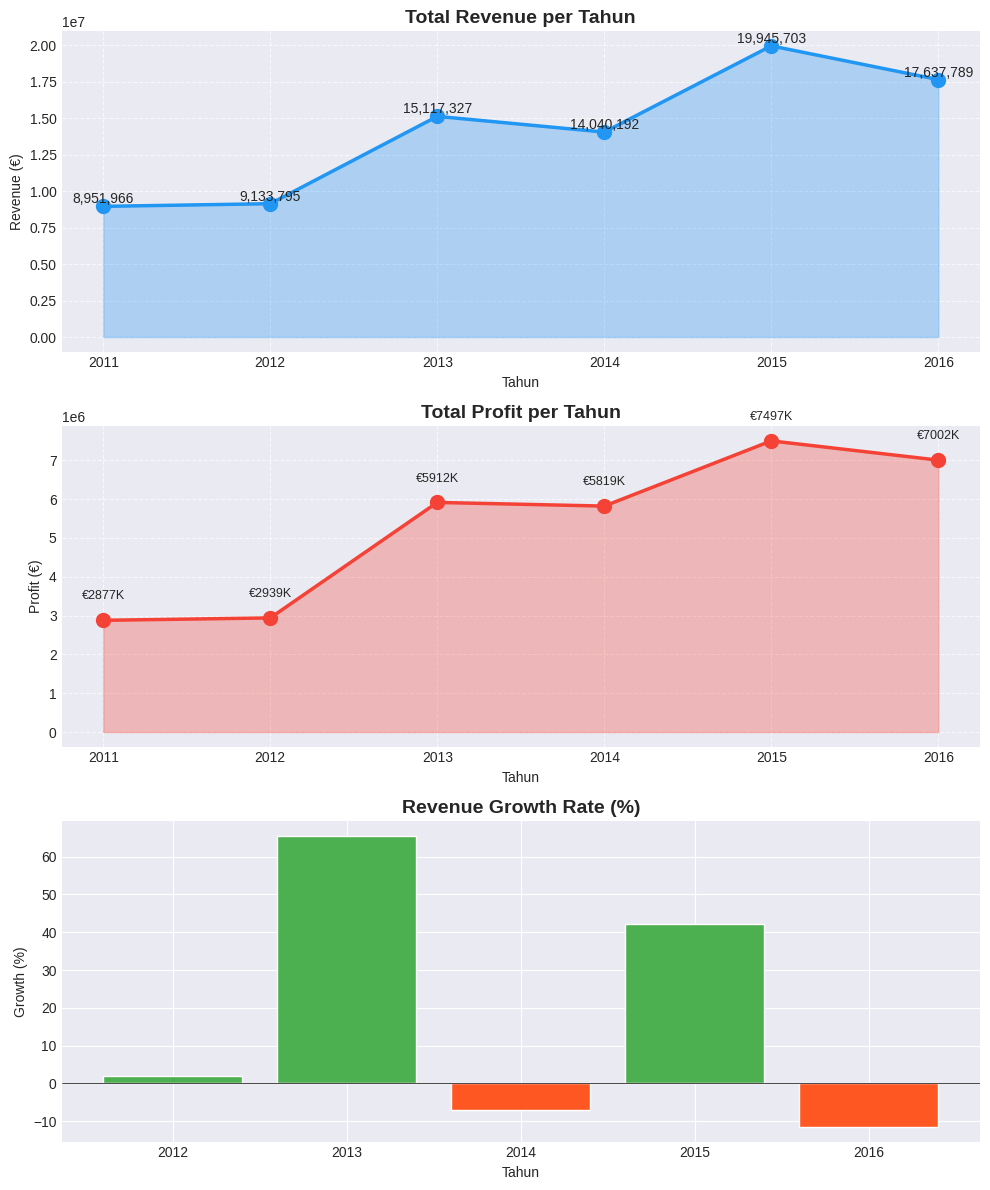


Insight: Rata-rata growth rate tahunan adalah 18.18%
Insight: Penjualan meningkat secara signifikan setiap tahun.
 tahun terbaik : 2013.0(€19,945,703)
 tahun terburuk : 2016.0(€8,951,966)

 4c. Tren Penjualan Per Hari dalam Seminggu

  Tren Penjualan Per Hari dalam Seminggu:


,Day_of_Week,Revenue,Profit,Order_Quantity
0,Friday,12079275,4512101,188584
1,Monday,12007965,4541823,188468
2,Saturday,12488578,4722589,194203
3,Sunday,12268543,4636229,189607
4,Thursday,11831242,4517802,192967
5,Tuesday,11934925,4520833,191030
6,Wednesday,12216244,4594862,188846


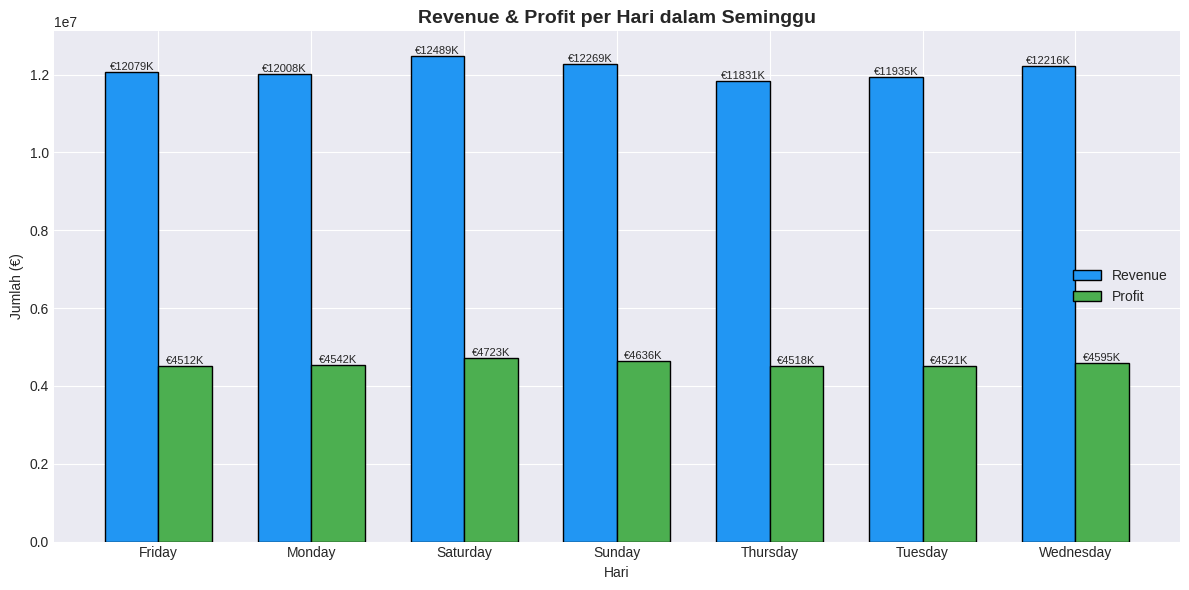


💡 INSIGHT: Hari paling ramai adalah Saturday


In [ ]:
# ============================================
# CELL 4: ANALISIS TREN PENJUALAN
# ============================================
print("=============================================")
print(" ANALISIS TREN PENJUALAN - Yearly & Monthly")
print("============================================")

# ---- 4a. tren revenue & profit per tahun ----
print("\n 4a. Tren Revenue & Profit Per Tahun")

yearly = df_clean.groupby('Year').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Order_Quantity': 'sum' if 'Order_Quantity' in df_clean.columns else 'Revenue'
}).reset_index()

#urutan berdasarkan tahun
yearly = yearly.sort_values(by='Year')
print("\n  Tren Revenue & Profit Per Tahun:")
display(yearly)

#visualisasi
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12)) # Changed nrows to 3


# Revenue per tahun
axes[0].plot(yearly['Year'], yearly['Revenue'], marker='o', linewidth=2.5,
             markersize=10, color='#2196F3')
axes[0].fill_between(yearly['Year'], yearly['Revenue'], alpha=0.3, color='#2196F3')
axes[0].set_title('Total Revenue per Tahun', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Revenue (€)')
axes[0].grid(True, linestyle='--', alpha=0.7)
# tambahan label nilai
for x, y in zip(yearly['Year'], yearly['Revenue']):
    axes[0].text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=10)

# Profit per tahun
axes[1].plot(yearly['Year'], yearly['Profit'], marker='o', linewidth=2.5,
             markersize=10, color='#F44336')
axes[1].fill_between(yearly['Year'], yearly['Profit'], alpha=0.3, color='#F44336')
axes[1].set_title('Total Profit per Tahun', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Profit (€)')
axes[1].grid(True, linestyle='--', alpha=0.7)
for x, y in zip(yearly['Year'], yearly['Profit']):
    axes[1].annotate(f'€{y/1000:.0f}K', (x, y), textcoords="offset points",
                    xytext=(0,15), ha='center', fontsize=9)
# Growth rate

# Growth rate
yearly['Revenue_Growth'] = yearly['Revenue'].pct_change() * 100
yearly_growth = yearly.dropna()
axes[2].bar(yearly_growth['Year'], yearly_growth['Revenue_Growth'],
            color=['#FF5722' if x < 0 else '#4CAF50' for x in yearly_growth['Revenue_Growth']])
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('Revenue Growth Rate (%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tahun')
axes[2].set_ylabel('Growth (%)')
plt.tight_layout() # Added to prevent overlap
plt.show()

#INSIGHT OTOMATIS
if len(yearly_growth) > 1:
    avg_growth = yearly_growth['Revenue_Growth'].mean()
    print(f"\nInsight: Rata-rata growth rate tahunan adalah {avg_growth:.2f}%")
    if avg_growth > 0:
        print("Insight: Penjualan meningkat secara signifikan setiap tahun.")
    elif avg_growth < 0:
        print("Insight: Penjualan menurun secara signifikan setiap tahun.")
    print(f" tahun terbaik : {yearly_growth.loc[yearly_growth['Revenue_Growth'].idxmax()]['Year']}" + f"(€{yearly['Revenue'].max():,.0f})")
    print(f" tahun terburuk : {yearly_growth.loc[yearly_growth['Revenue_Growth'].idxmin()]['Year']}" + f"(€{yearly['Revenue'].min():,.0f})")
else:
    print("\nInsight: Tidak ada data untuk perhitungan growth rate.")
# 4c  tren per hari dalam seminggu
print("\n 4c. Tren Penjualan Per Hari dalam Seminggu")
print("\n  Tren Penjualan Per Hari dalam Seminggu:")
daily = df_clean.groupby('Day_of_Week').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Order_Quantity': 'sum' if 'Order_Quantity' in df_clean.columns else 'Revenue'
}).reset_index()
display(daily)


# Visualisasi
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(daily))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], daily['Revenue'], width,
               label='Revenue', color='#2196F3', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], daily['Profit'], width,
               label='Profit', color='#4CAF50', edgecolor='black')

ax.set_title('Revenue & Profit per Hari dalam Seminggu', fontsize=14, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Jumlah (€)')
ax.set_xticks(x)
ax.set_xticklabels(daily['Day_of_Week'])
ax.legend()
# Tambahkan label
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'€{height/1000:.0f}K',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'€{height/1000:.0f}K',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('tren_harian.png', dpi=150, bbox_inches='tight')
plt.show()

best_day = daily.loc[daily['Revenue'].idxmax(), 'Day_of_Week']
print(f"\n💡 INSIGHT: Hari paling ramai adalah {best_day}")

# CELL 5: DEKOMPOSISI TIME SERIES


🔄 DEKOMPOSISI TIME SERIES
📅 Data time series harian:
   - Tanggal mulai: 2011-01-01
   - Tanggal akhir: 2016-07-31
   - Jumlah hari: 2039


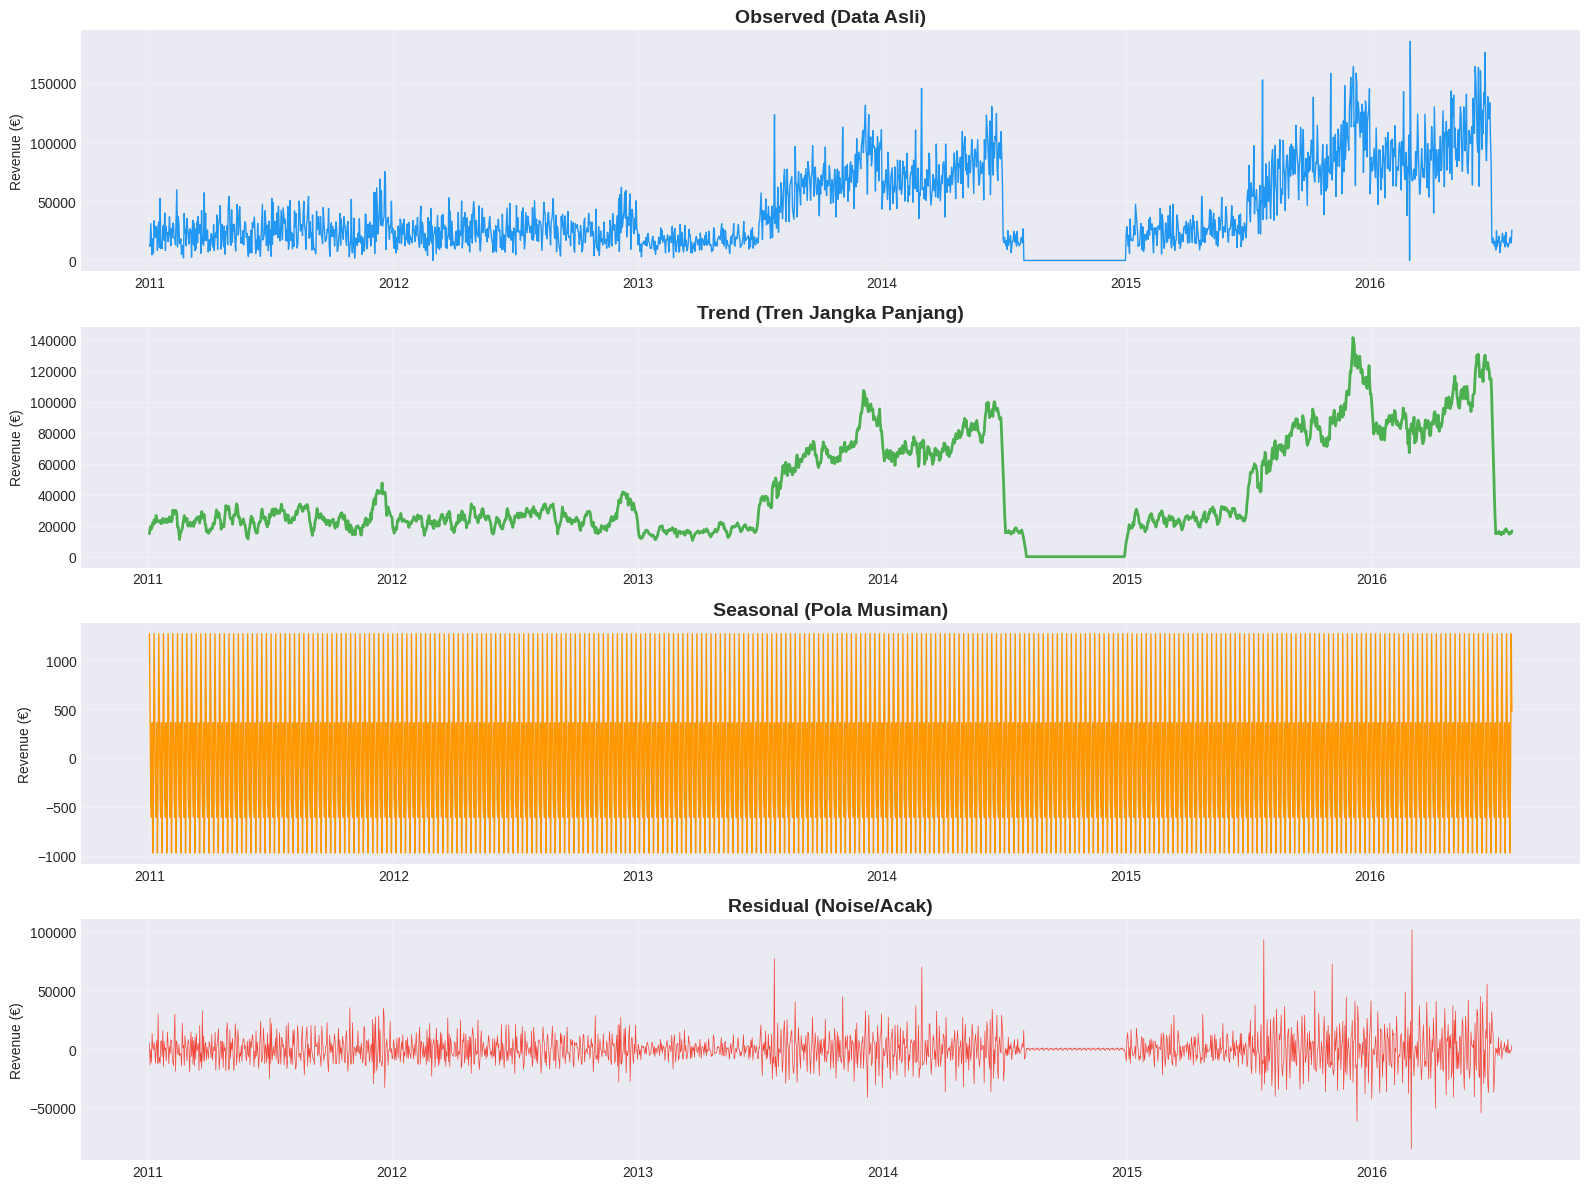


💡 INSIGHT:
   - Lihat grafik TREND: apakah garisnya naik, turun, atau datar?
   - Lihat grafik SEASONAL: apakah ada pola berulang setiap 7 hari?
   - Lihat grafik RESIDUAL: apakah ada spike besar yang tidak bisa dijelaskan?


In [ ]:
# ============================================
# CELL 5: DEKOMPOSISI TIME SERIES
# ============================================

print("="*60)
print("🔄 DEKOMPOSISI TIME SERIES")
print("="*60)

# Siapkan data time series
# Cari kolom tanggal
date_col = None
for col in df_clean.columns:
    if 'date' in col.lower():
        date_col = col
        break

if date_col:
    # Set index ke tanggal
    ts_data = df_clean.set_index(date_col).copy()

    # Resample ke harian
    daily_ts = ts_data['Revenue'].resample('D').sum()

    # Isi missing dates dengan 0
    daily_ts = daily_ts.fillna(0)

    print(f"📅 Data time series harian:")
    print(f"   - Tanggal mulai: {daily_ts.index.min().date()}")
    print(f"   - Tanggal akhir: {daily_ts.index.max().date()}")
    print(f"   - Jumlah hari: {len(daily_ts)}")

    # Pilih periode dekomposisi (30 hari untuk musiman bulanan, 7 untuk mingguan)
    period = 7  # musiman mingguan

    # Lakukan dekomposisi
    decomposition = seasonal_decompose(daily_ts, model='additive', period=period)

    # Visualisasi
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))

    # Observed
    axes[0].plot(decomposition.observed, linewidth=1, color='#2196F3')
    axes[0].set_title('Observed (Data Asli)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Revenue (€)')
    axes[0].grid(True, alpha=0.3)

    # Trend
    axes[1].plot(decomposition.trend, linewidth=2, color='#4CAF50')
    axes[1].set_title('Trend (Tren Jangka Panjang)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Revenue (€)')
    axes[1].grid(True, alpha=0.3)

    # Seasonal
    axes[2].plot(decomposition.seasonal, linewidth=1, color='#FF9800')
    axes[2].set_title('Seasonal (Pola Musiman)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Revenue (€)')
    axes[2].grid(True, alpha=0.3)

    # Residual
    axes[3].plot(decomposition.resid, linewidth=0.5, color='#F44336')
    axes[3].set_title('Residual (Noise/Acak)', fontsize=14, fontweight='bold')
    axes[3].set_ylabel('Revenue (€)')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('dekomposisi_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n💡 INSIGHT:")
    print("   - Lihat grafik TREND: apakah garisnya naik, turun, atau datar?")
    print("   - Lihat grafik SEASONAL: apakah ada pola berulang setiap 7 hari?")
    print("   - Lihat grafik RESIDUAL: apakah ada spike besar yang tidak bisa dijelaskan?")
else:
    print("⚠️ Kolom tanggal tidak ditemukan, dekomposisi tidak bisa dilakukan")

# PERFORMANCE PRODUK PER TAHUN

📦 ANALISIS PERFORMANCE PRODUK PER TAHUN
✅ Kolom produk: 'Product'
✅ Kolom kategori: 'Sub_Category'

📊 6A. TOP 10 PRODUK TERLARIS TIAP TAHUN


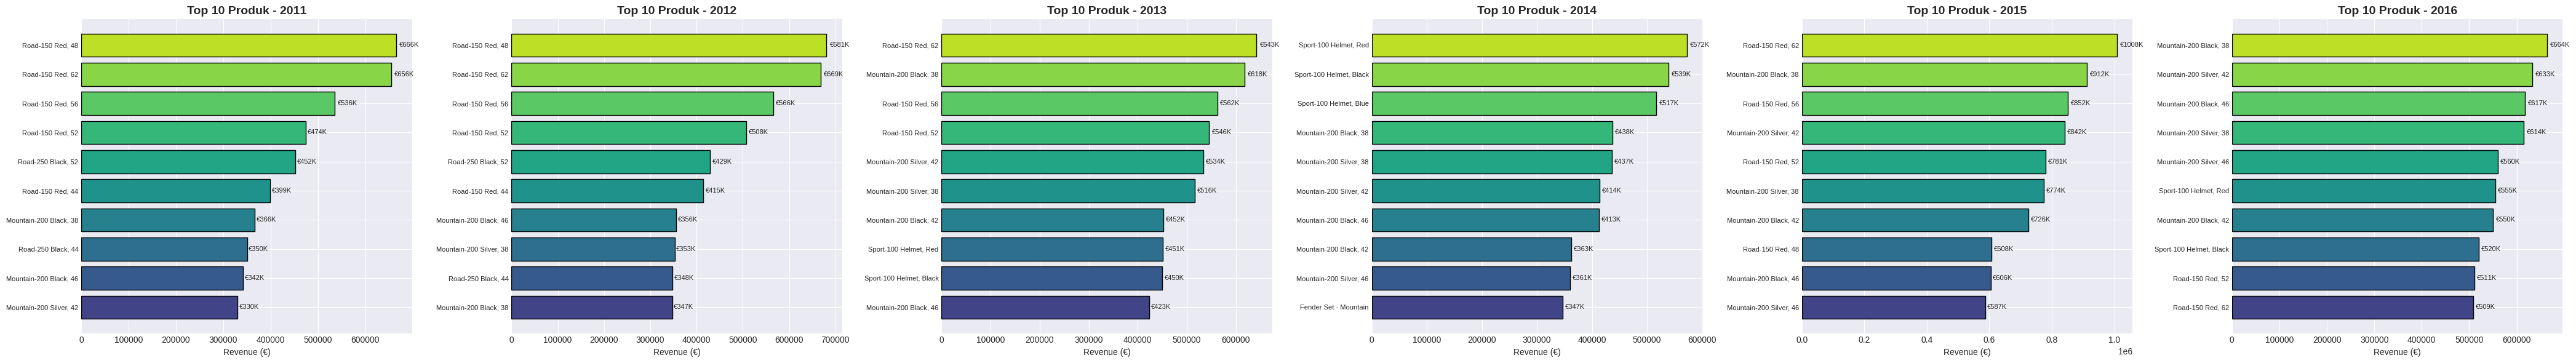


📋 TOP 3 PRODUK PER TAHUN:

🏆 Tahun 2011:
   1. Road-150 Red, 48                         €     665,977 (7.4%)
   2. Road-150 Red, 62                         €     655,603 (7.3%)
   3. Road-150 Red, 56                         €     536,054 (6.0%)

🏆 Tahun 2012:
   1. Road-150 Red, 48                         €     680,910 (7.5%)
   2. Road-150 Red, 62                         €     668,802 (7.3%)
   3. Road-150 Red, 56                         €     565,614 (6.2%)

🏆 Tahun 2013:
   1. Road-150 Red, 62                         €     642,518 (4.3%)
   2. Mountain-200 Black, 38                   €     618,435 (4.1%)
   3. Road-150 Red, 56                         €     562,222 (3.7%)

🏆 Tahun 2014:
   1. Sport-100 Helmet, Red                    €     572,170 (4.1%)
   2. Sport-100 Helmet, Black                  €     539,175 (3.8%)
   3. Sport-100 Helmet, Blue                   €     516,590 (3.7%)

🏆 Tahun 2015:
   1. Road-150 Red, 62                         €   1,008,304 (5.1%)
   2. Mountain

Sub_Category,Bike Racks,Bike Stands,Bottles and Cages,Caps,Cleaners,Fenders,Gloves,Helmets,Hydration Packs,Jerseys,Mountain Bikes,Road Bikes,Shorts,Socks,Tires and Tubes,Touring Bikes,Vests
Year,,,,,,,,,,,,,,,,,
2011,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,24.56,75.44,0.00,0.00,0.00,0.00,0.00
2012,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,23.85,76.15,0.00,0.00,0.00,0.00,0.00
2013,0.74,0.62,1.91,0.77,0.28,1.88,1.27,8.49,1.57,6.32,24.53,31.54,2.96,0.22,6.73,8.48,1.67
2014,1.09,0.59,2.96,1.15,0.41,2.47,1.78,11.59,1.88,8.05,21.01,21.20,3.10,0.30,9.38,11.39,1.63
2015,0.54,0.45,1.41,0.57,0.21,1.39,0.93,6.27,1.16,4.65,27.91,36.31,2.17,0.16,4.95,9.69,1.24
2016,0.82,0.43,2.29,0.89,0.32,1.91,1.38,8.94,1.46,6.24,25.05,25.25,2.40,0.23,7.24,13.89,1.26


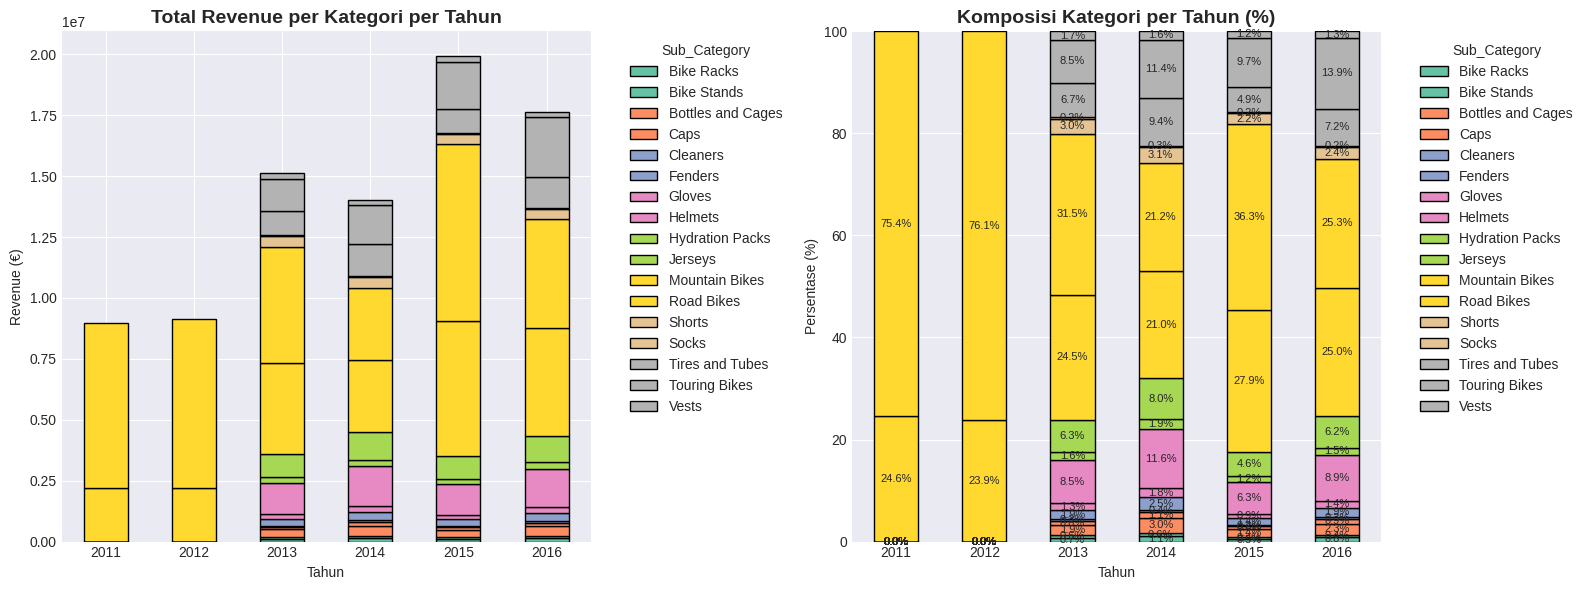


💡 INSIGHT: Perubahan komposisi kategori dari 2011 ke 2016:
   📈 Bike Racks: 0.0% → 0.8% (Δ +0.8%)
   📈 Bike Stands: 0.0% → 0.4% (Δ +0.4%)
   📈 Bottles and Cages: 0.0% → 2.3% (Δ +2.3%)
   📈 Caps: 0.0% → 0.9% (Δ +0.9%)
   📈 Cleaners: 0.0% → 0.3% (Δ +0.3%)
   📈 Fenders: 0.0% → 1.9% (Δ +1.9%)
   📈 Gloves: 0.0% → 1.4% (Δ +1.4%)
   📈 Helmets: 0.0% → 8.9% (Δ +8.9%)
   📈 Hydration Packs: 0.0% → 1.5% (Δ +1.5%)
   📈 Jerseys: 0.0% → 6.2% (Δ +6.2%)
   📈 Mountain Bikes: 24.6% → 25.0% (Δ +0.5%)
   📉 Road Bikes: 75.4% → 25.3% (Δ -50.2%)
   📈 Shorts: 0.0% → 2.4% (Δ +2.4%)
   📈 Socks: 0.0% → 0.2% (Δ +0.2%)
   📈 Tires and Tubes: 0.0% → 7.2% (Δ +7.2%)
   📈 Touring Bikes: 0.0% → 13.9% (Δ +13.9%)
   📈 Vests: 0.0% → 1.3% (Δ +1.3%)

📊 6C. PROFIT MARGIN PER KATEGORI

📋 Profit Margin per Kategori:


,Revenue,Profit,Profit_Margin,Order_Quantity
Sub_Category,,,,
Road Bikes,33150708,10012631,29.15,19638
Mountain Bikes,21020794,8117801,38.61,11935
Touring Bikes,7262982,2269294,30.64,4628
Helmets,5738482,3378696,58.55,181522
Tires and Tubes,4598124,2685467,55.01,505889
Jerseys,4112382,603440,14.16,88095
Shorts,1740710,1034342,58.99,27168
Bottles and Cages,1390570,799882,56.81,238610
Fenders,1245733,748914,59.75,62138


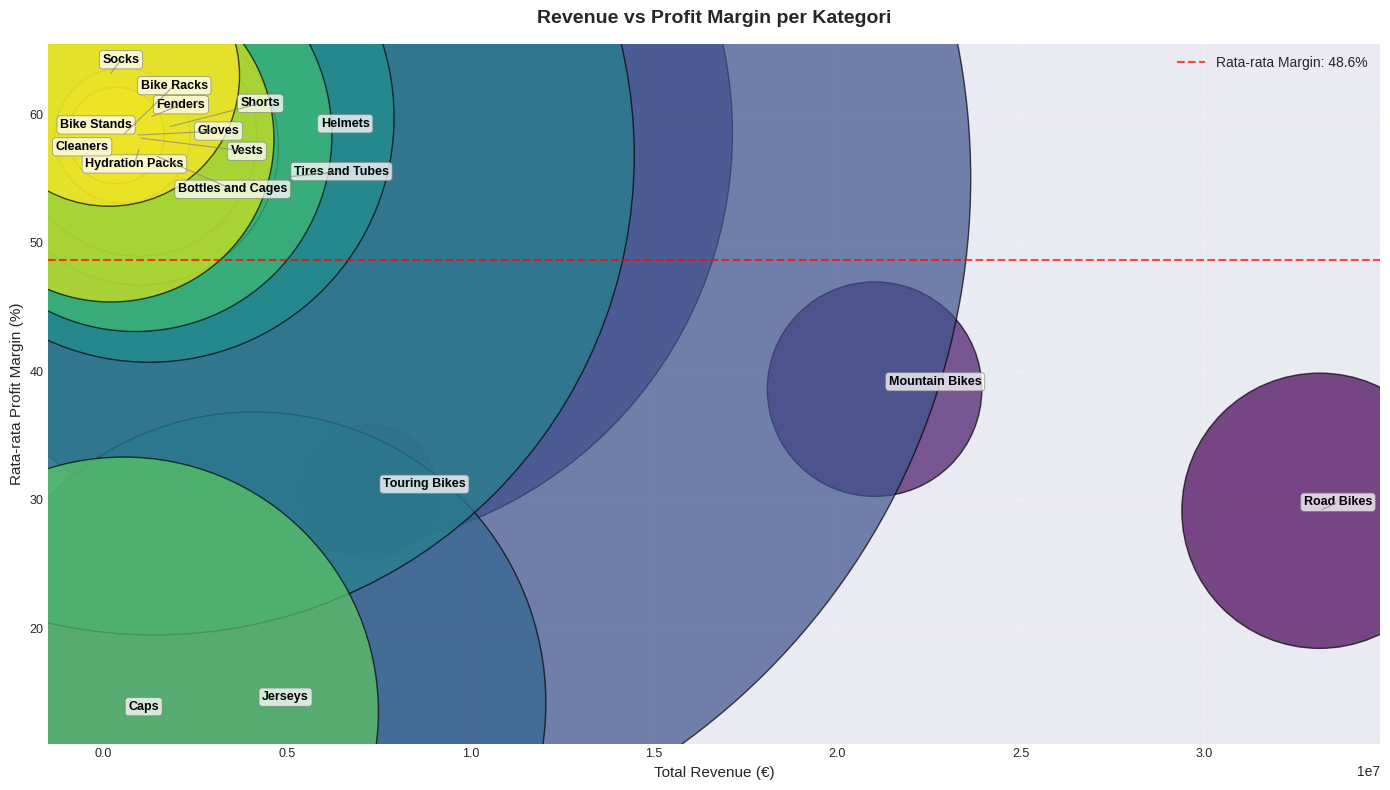


📊 6D. ANALISIS PARETO (PRINSIP 80/20)


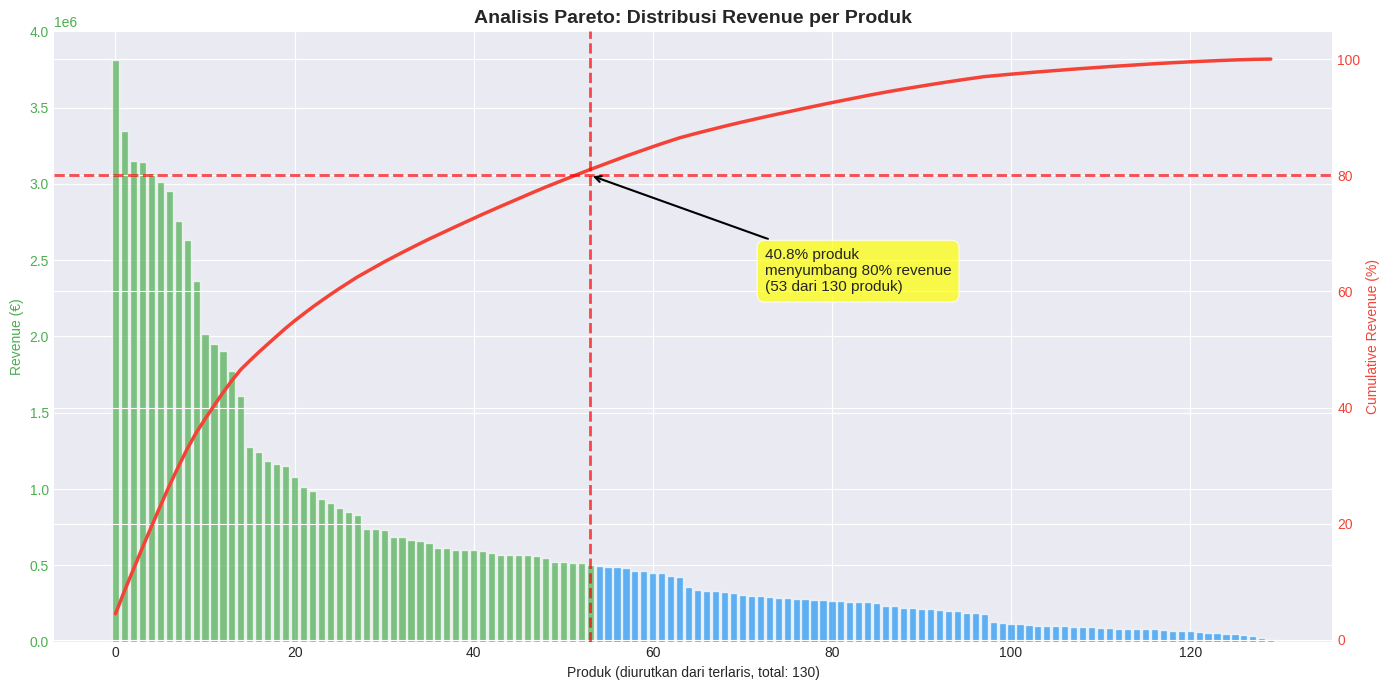


💡 INSIGHT PARETO:
   - 40.8% produk (53 dari 130) menyumbang 80% total revenue
   - Fokuskan stok, marketing, dan optimasi pada 53 produk tersebut
   - 77 produk sisanya hanya menyumbang 20% revenue

📊 6E. GROWTH RATE PRODUK TAHUN-KE-TAHUN

📈 TOP 5 PRODUK DENGAN GROWTH TERTINGGI (2015 → 2016):


Year,2015,2016,Growth_2015_to_2016
Product,,,
"Road-650 Red, 44",4197.00,29671.00,606.96
"Road-650 Red, 52",2098.00,6968.00,232.13
"Road-650 Black, 44",9426.00,24812.00,163.23
"Touring-3000 Blue, 62",14891.00,36989.00,148.40
"Touring-3000 Yellow, 50",19283.00,45375.00,135.31



📉 TOP 5 PRODUK DENGAN GROWTH TERENDAH (2015 → 2016):


Year,2015,2016,Growth_2015_to_2016
Product,,,
"Mountain-100 Black, 44",114314.00,18022.00,-84.23
"Road-650 Black, 58",39791.00,10337.00,-74.02
"Mountain-100 Silver, 38",130322.00,40086.00,-69.24
"Mountain-100 Silver, 48",102442.00,32674.00,-68.10
"Road-350-W Yellow, 48",314206.00,109227.00,-65.24


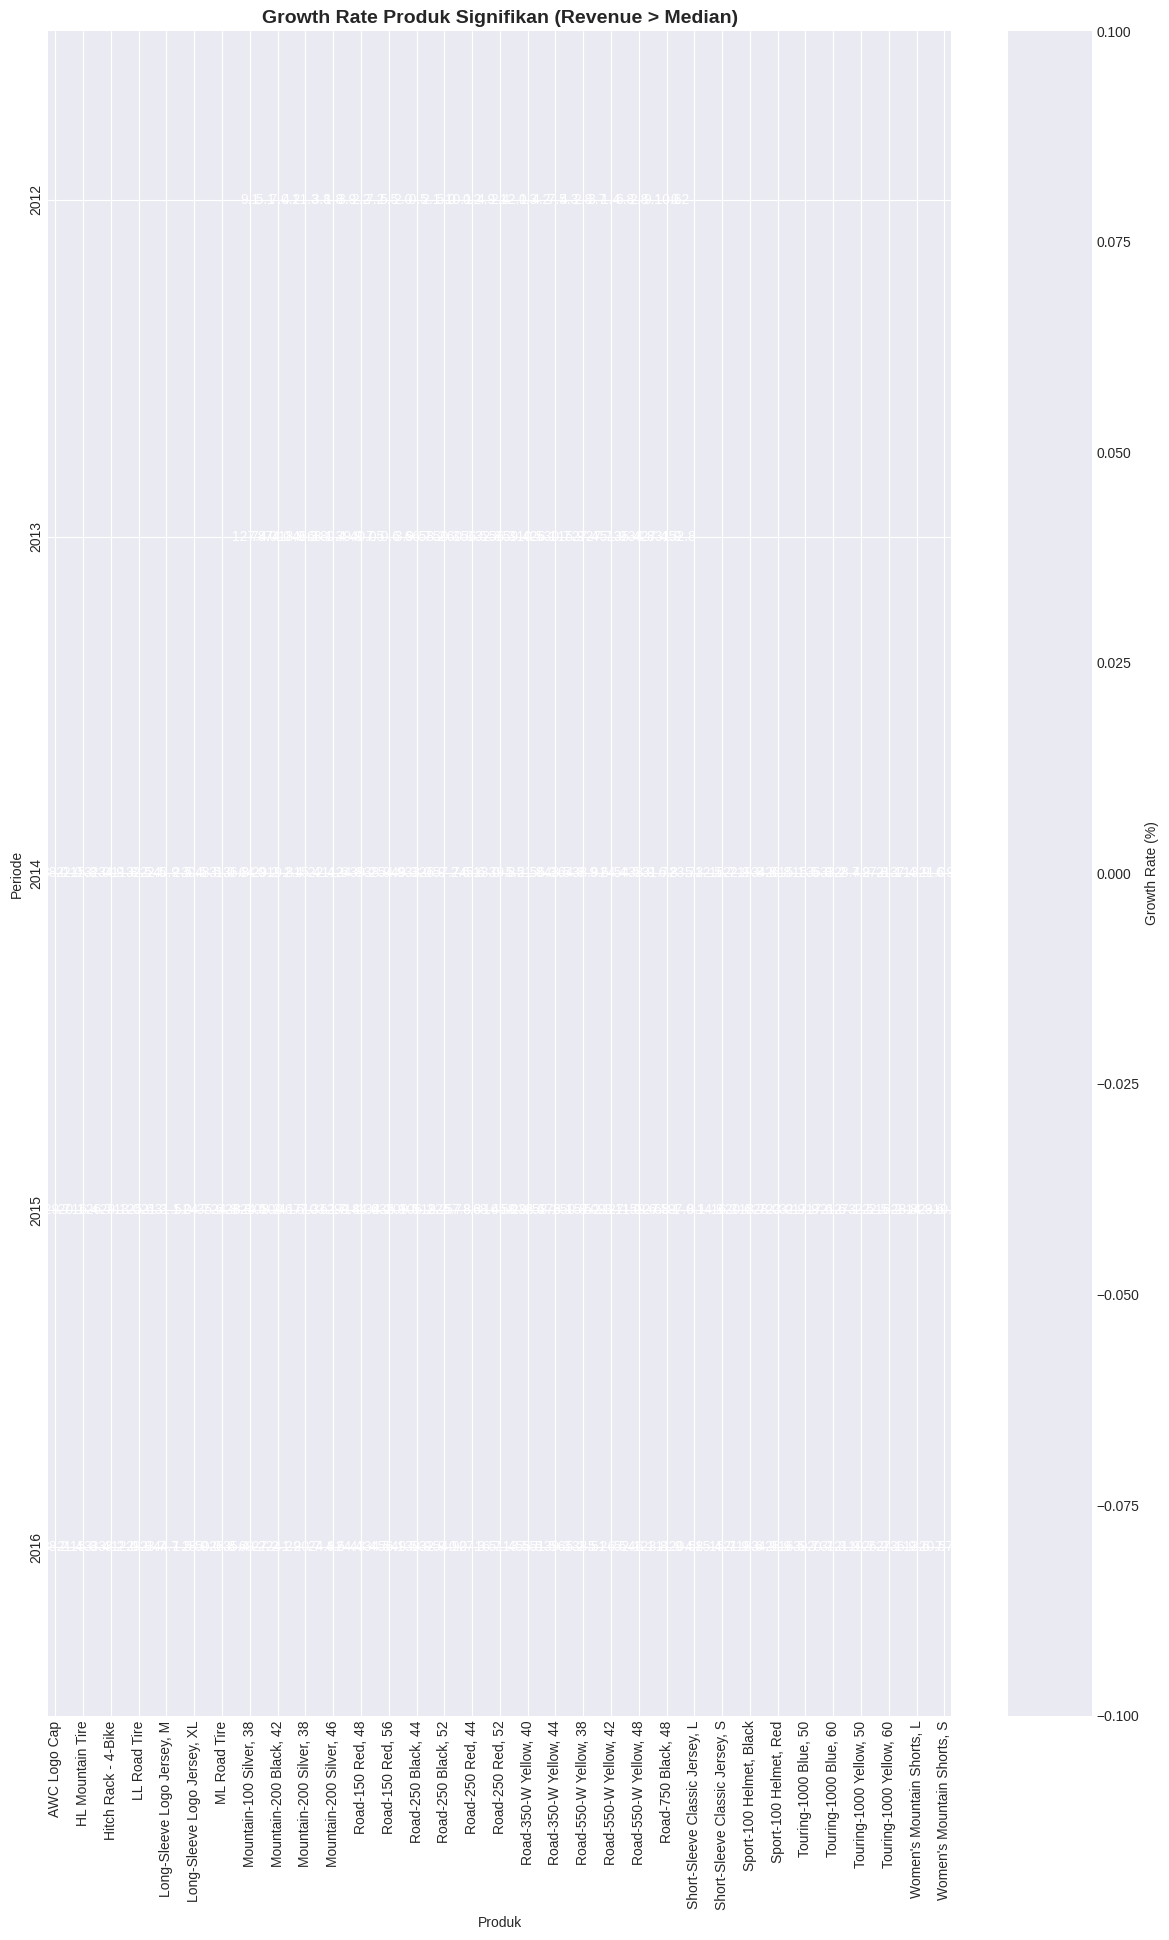

In [ ]:
# ============================================
# CELL 6: ANALISIS PERFORMANCE PRODUK PER TAHUN
# ============================================

print("="*60)
print("📦 ANALISIS PERFORMANCE PRODUK PER TAHUN")
print("="*60)

# Cari kolom produk dan kategori
product_col = None
category_col = None

for col in df_clean.columns:
    if 'product' in col.lower() and 'category' not in col.lower():
        product_col = col
    if 'category' in col.lower():
        category_col = col

if product_col is None:
    product_col = 'Product'
    print(f"⚠️ Kolom produk tidak ditemukan, gunakan '{product_col}' sebagai default")
else:
    print(f"✅ Kolom produk: '{product_col}'")

if category_col is None:
    category_col = 'Product_Category'
    print(f"⚠️ Kolom kategori tidak ditemukan, gunakan '{category_col}' sebagai default")
else:
    print(f"✅ Kolom kategori: '{category_col}'")

# ---- 6A. TOP 10 PRODUK TERLARIS TIAP TAHUN ----
print("\n📊 6A. TOP 10 PRODUK TERLARIS TIAP TAHUN")

years = sorted(df_clean['Year'].unique())
n_years = len(years)

# Buat subplot untuk tiap tahun
fig, axes = plt.subplots(1, n_years, figsize=(7*n_years, 6))
if n_years == 1:
    axes = [axes]

for i, year in enumerate(years):
    # Filter data per tahun
    data_year = df_clean[df_clean['Year'] == year]

    # Groupby produk, sum revenue
    product_rev = data_year.groupby(product_col)['Revenue'].sum().sort_values(ascending=True)

    # Ambil top 10
    top10 = product_rev.tail(10)

    # Plot horizontal bar
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top10)))
    axes[i].barh(range(len(top10)), top10.values, color=colors, edgecolor='black')
    axes[i].set_yticks(range(len(top10)))
    axes[i].set_yticklabels([name[:25] for name in top10.index], fontsize=8)
    axes[i].set_title(f'Top 10 Produk - {year}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Revenue (€)')

    # Tambahkan label nilai
    for j, v in enumerate(top10.values):
        axes[i].text(v + v*0.01, j, f'€{v/1000:.0f}K', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('top10_produk_tahunan.png', dpi=150, bbox_inches='tight')
plt.show()

# Tampilkan tabel
print("\n📋 TOP 3 PRODUK PER TAHUN:")
for year in years:
    data_year = df_clean[df_clean['Year'] == year]
    top3 = data_year.groupby(product_col)['Revenue'].sum().nlargest(3)
    print(f"\n🏆 Tahun {year}:")
    for rank, (prod, rev) in enumerate(top3.items(), 1):
        pct = (rev / data_year['Revenue'].sum()) * 100
        print(f"   {rank}. {prod[:40]:<40} €{rev:>12,.0f} ({pct:.1f}%)")

# ---- 6B. KONTRIBUSI KATEGORI PER TAHUN ----
print("\n" + "="*60)
print("📊 6B. KONTRIBUSI REVENUE PER KATEGORI")

# Pivot table: tahun vs kategori
if category_col in df_clean.columns:
    cat_pivot = df_clean.pivot_table(
        values='Revenue', index='Year', columns=category_col, aggfunc='sum'
    ).fillna(0)

    # Convert ke persentase
    cat_pivot_pct = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100

    print("\n📋 Persentase Revenue per Kategori:")
    display(cat_pivot_pct.round(2))

    # Stacked bar chart (nilai absolut)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    cat_pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2', edgecolor='black')
    ax1.set_title('Total Revenue per Kategori per Tahun', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Tahun')
    ax1.set_ylabel('Revenue (€)')
    ax1.legend(title=category_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.tick_params(axis='x', rotation=0)

    # 100% stacked bar
    cat_pivot_pct.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2', edgecolor='black')
    ax2.set_title('Komposisi Kategori per Tahun (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Tahun')
    ax2.set_ylabel('Persentase (%)')
    ax2.legend(title=category_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=0)
    ax2.set_ylim(0, 100)

    # Tambahkan label persen
    for c in ax2.containers:
        ax2.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('kontribusi_kategori.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Insight
    first_year = cat_pivot_pct.index[0]
    last_year = cat_pivot_pct.index[-1]
    print(f"\n💡 INSIGHT: Perubahan komposisi kategori dari {first_year} ke {last_year}:")
    for cat in cat_pivot_pct.columns:
        change = cat_pivot_pct.loc[last_year, cat] - cat_pivot_pct.loc[first_year, cat]
        arrow = "📈" if change > 0 else "📉"
        print(f"   {arrow} {cat}: {cat_pivot_pct.loc[first_year, cat]:.1f}% → " +
              f"{cat_pivot_pct.loc[last_year, cat]:.1f}% (Δ {change:+.1f}%)")

# ---- 6C. PROFIT MARGIN PER KATEGORI ----
# ============================================
# ---- 6C. PROFIT MARGIN PER KATEGORI ----
print("\n" + "="*60)
print("📊 6C. PROFIT MARGIN PER KATEGORI")

if 'Profit_Margin' in df_clean.columns and category_col in df_clean.columns:
    margin_by_cat = df_clean.groupby(category_col).agg({
        'Revenue': 'sum',
        'Profit': 'sum',
        'Profit_Margin': 'mean',
        'Order_Quantity': 'sum' if 'Order_Quantity' in df_clean.columns else 'Revenue'
    }).round(2)

    margin_by_cat = margin_by_cat.sort_values('Revenue', ascending=False)

    print("\n📋 Profit Margin per Kategori:")
    display(margin_by_cat)

    # Install adjustText jika belum ada
    try:
        from adjustText import adjust_text
    except ImportError:
        import subprocess
        subprocess.run(['pip', 'install', 'adjustText', '-q'])
        from adjustText import adjust_text

    fig, ax = plt.subplots(figsize=(14, 8))

    scatter = ax.scatter(
        margin_by_cat['Revenue'],
        margin_by_cat['Profit_Margin'],
        s=margin_by_cat.iloc[:, 3] * 2,
        c=range(len(margin_by_cat)),
        cmap='viridis',
        alpha=0.7,
        edgecolors='black',
        linewidth=1
    )

    # Buat semua label sekaligus lalu adjust
    texts = []
    for cat, row in margin_by_cat.iterrows():
        txt = ax.text(
            row['Revenue'],
            row['Profit_Margin'],
            cat[:25],
            fontsize=9,
            fontweight='bold',
            color='black',
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='white',
                edgecolor='gray',
                alpha=0.75,
                linewidth=0.6
            )
        )
        texts.append(txt)

    # Auto-adjust posisi label agar tidak saling tumpuk
    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.8, 1.8),
        expand_text=(1.4, 1.4),
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            lw=0.8,
            alpha=0.7
        ),
        force_points=(0.5, 0.8),
        force_text=(0.5, 0.5),
        only_move={'points': 'y', 'texts': 'xy'}
    )

    # Garis rata-rata margin
    avg_margin = margin_by_cat['Profit_Margin'].mean()
    ax.axhline(
        y=avg_margin,
        color='red',
        linestyle='--',
        alpha=0.7,
        linewidth=1.5,
        label=f'Rata-rata Margin: {avg_margin:.1f}%'
    )

    ax.set_title('Revenue vs Profit Margin per Kategori', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Total Revenue (€)', fontsize=11)
    ax.set_ylabel('Rata-rata Profit Margin (%)', fontsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.savefig('profit_margin_kategori.png', dpi=150, bbox_inches='tight')
    plt.show()

# ---- 6D. ANALISIS PARETO (80/20) ----
print("\n" + "="*60)
print("📊 6D. ANALISIS PARETO (PRINSIP 80/20)")

# Hitung revenue per produk
product_rev = df_clean.groupby(product_col)['Revenue'].sum().sort_values(ascending=False)

# Hitung cumulative
cumulative_rev = product_rev.cumsum()
cumulative_rev_pct = (cumulative_rev / product_rev.sum()) * 100
cumulative_prod_pct = (np.arange(1, len(product_rev)+1) / len(product_rev)) * 100

# Cari produk yang menyumbang 80% revenue
n_80 = np.argmax(cumulative_rev_pct >= 80) + 1
pct_80 = (n_80 / len(product_rev)) * 100

# Visualisasi
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart
colors = ['#4CAF50' if i <= n_80 else '#2196F3' for i in range(len(product_rev))]
ax1.bar(range(len(product_rev)), product_rev.values, color=colors, alpha=0.7)
ax1.set_xlabel(f'Produk (diurutkan dari terlaris, total: {len(product_rev)})')
ax1.set_ylabel('Revenue (€)', color='#4CAF50')
ax1.tick_params(axis='y', labelcolor='#4CAF50')
ax1.set_title('Analisis Pareto: Distribusi Revenue per Produk', fontsize=14, fontweight='bold')

# Line cumulative
ax2 = ax1.twinx()
ax2.plot(range(len(product_rev)), cumulative_rev_pct, color='#F44336', linewidth=2.5)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax2.axvline(x=n_80, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax2.set_ylabel('Cumulative Revenue (%)', color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')

# Anotasi titik 80%
ax2.annotate(f'{pct_80:.1f}% produk\nmenyumbang 80% revenue\n({n_80} dari {len(product_rev)} produk)',
            xy=(n_80, 80), xytext=(n_80 + len(product_rev)*0.15, 60),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=11, bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 INSIGHT PARETO:")
print(f"   - {pct_80:.1f}% produk ({n_80} dari {len(product_rev)}) menyumbang 80% total revenue")
print(f"   - Fokuskan stok, marketing, dan optimasi pada {n_80} produk tersebut")
print(f"   - {len(product_rev) - n_80} produk sisanya hanya menyumbang 20% revenue")

# ---- 6E. GROWTH RATE PRODUK ----
print("\n" + "="*60)
print("📊 6E. GROWTH RATE PRODUK TAHUN-KE-TAHUN")

if len(years) >= 2:
    # Pivot table produk vs tahun
    product_yearly = df_clean.pivot_table(
        values='Revenue', index=product_col, columns='Year', aggfunc='sum'
    ).fillna(0)

    # Hitung growth rate untuk semua tahun
    growth_cols = []
    for i in range(len(years)-1):
        col_name = f'Growth_{years[i]}_to_{years[i+1]}'
        product_yearly[col_name] = (
            (product_yearly[years[i+1]] - product_yearly[years[i]])
            / product_yearly[years[i]].replace(0, np.nan)
        ) * 100
        growth_cols.append(col_name)

    # Tampilkan produk dengan growth tertinggi dan terendah
    last_growth = growth_cols[-1]
    top_growth = product_yearly.nlargest(5, last_growth)
    bottom_growth = product_yearly.nsmallest(5, last_growth)

    print(f"\n📈 TOP 5 PRODUK DENGAN GROWTH TERTINGGI ({years[-2]} → {years[-1]}):")
    display(top_growth[[years[-2], years[-1], last_growth]].round(2))

    print(f"\n📉 TOP 5 PRODUK DENGAN GROWTH TERENDAH ({years[-2]} → {years[-1]}):")
    display(bottom_growth[[years[-2], years[-1], last_growth]].round(2))

    # Heatmap growth (untuk produk dengan revenue significant)
    min_revenue = product_yearly[years].sum(axis=1).quantile(0.5)  # top 50%
    significant_products = product_yearly[product_yearly[years].sum(axis=1) >= min_revenue]

    fig, ax = plt.subplots(figsize=(len(years)*2, max(10, len(significant_products)*0.3)))
    sns.heatmap(significant_products[years].pct_change(axis=1).drop(years[0], axis=1).T * 100,
               annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax,
               cbar_kws={'label': 'Growth Rate (%)'})
    ax.set_title(f'Growth Rate Produk Signifikan (Revenue > Median)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Periode')
    ax.set_xlabel('Produk')

    plt.tight_layout()
    plt.savefig('growth_rate_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# CELL 7: SEGMENTASI DEMOGRAFIS

👥 SEGMENTASI PELANGGAN - DEMOGRAFIS

📊 7A. REVENUE BY AGE GROUP

📋 Revenue by Age Group:


,Revenue,Profit,Profit_Margin
Age_Group,,,
17-25 (Young Adult),14194911,5291293,47.63
26-35 (Adult),31186542,11540302,46.36
36-45 (Middle Age),24801138,9377689,47.12
46+ (Senior),14644181,5836955,48.45


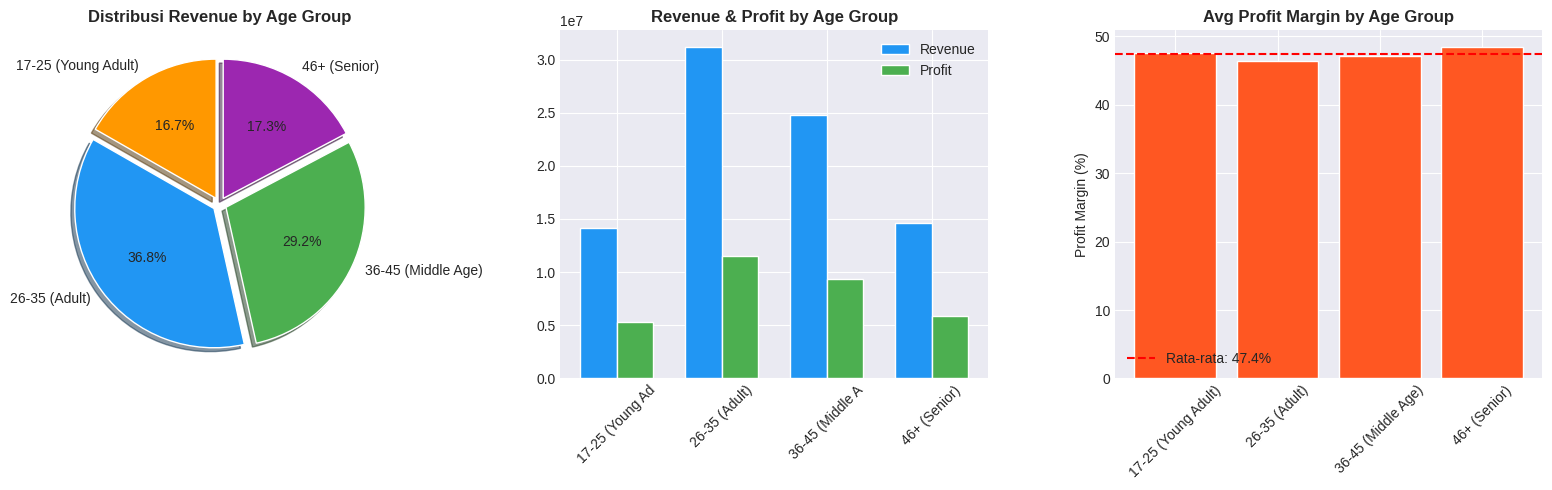


💡 INSIGHT: Age group dengan revenue tertinggi: 26-35 (Adult)
   (€31,186,542, margin 46.4%)

📊 7B. REVENUE BY GENDER
   Kolom gender: 'Customer_Gender'

📋 Revenue by Gender:


,Revenue,Profit,Revenue_Pct,Profit_Pct
Customer_Gender,,,,
F,41694689,15641819,49.15,48.81
M,43132083,16404420,50.85,51.19


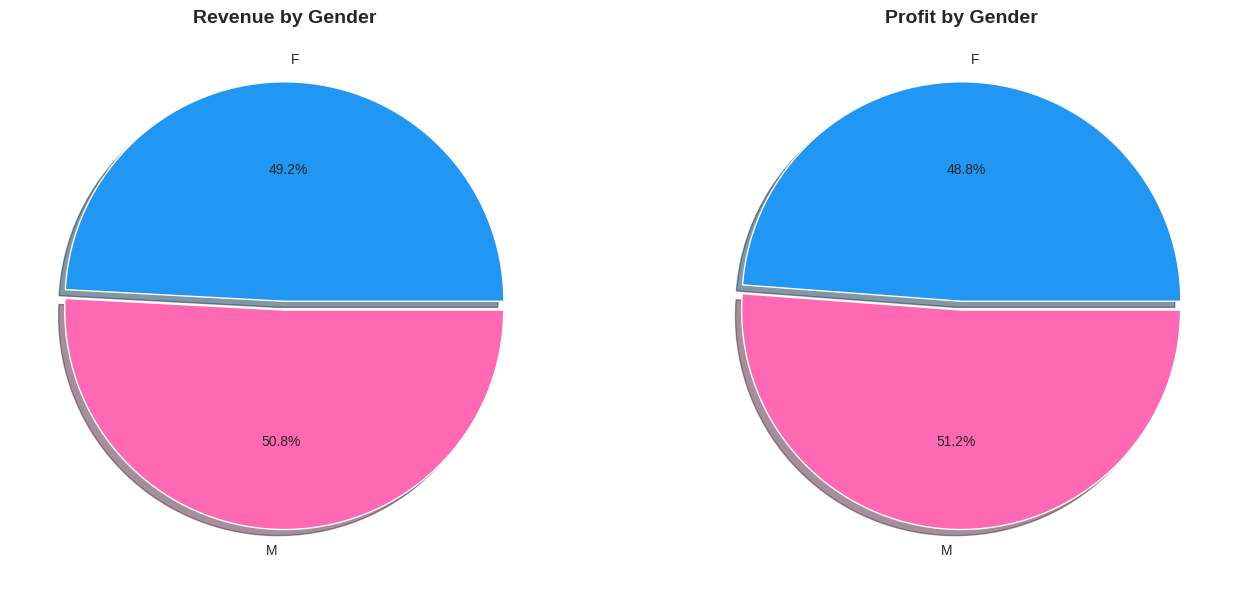


📊 7C. REVENUE BY COUNTRY

📋 Revenue by Country:


,Revenue,Profit,Profit_Margin,Revenue_Pct
Country,,,,
United States,27777098,10997638,48.15,32.75
Australia,21196395,6740522,41.84,24.99
United Kingdom,10575628,4383987,50.00,12.47
Germany,8956724,3349991,45.95,10.56
France,8414745,2872082,43.63,9.92
Canada,7906182,3702019,54.80,9.32


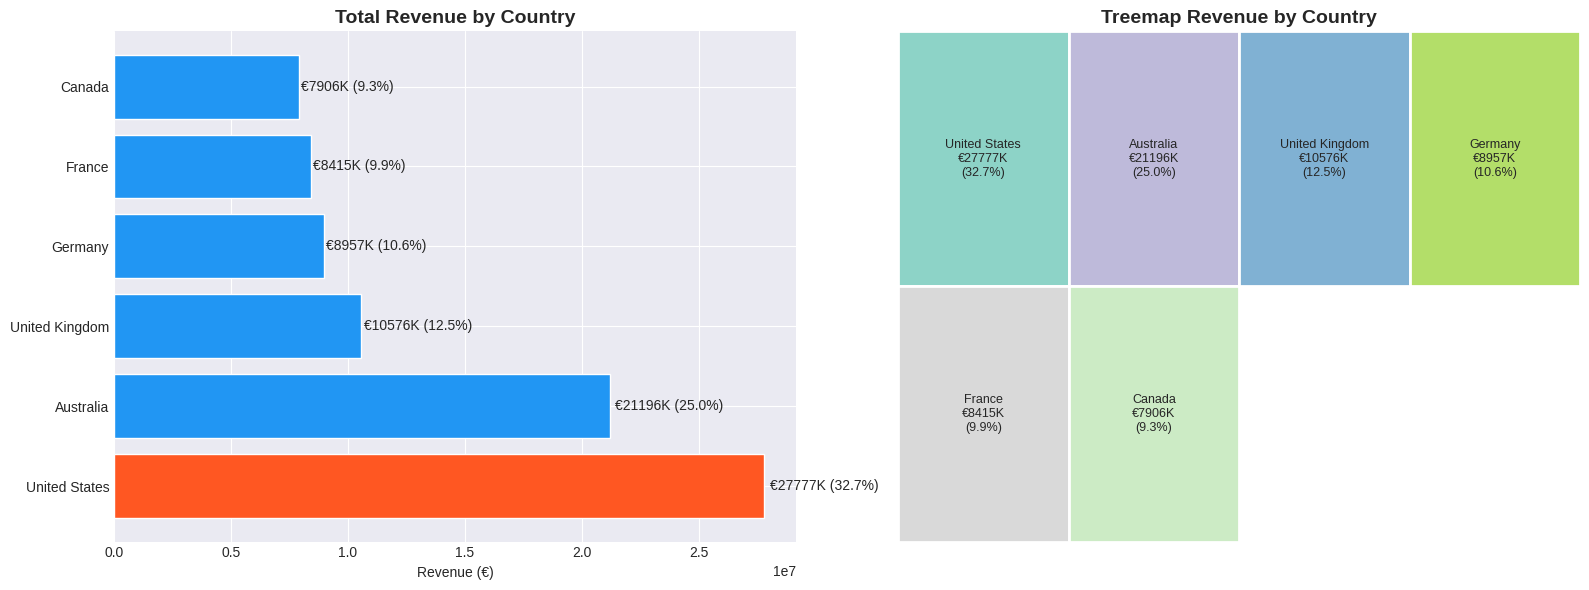


💡 INSIGHT: Negara dengan revenue terbesar: United States (32.7%)


In [ ]:
# ============================================
# CELL 7: SEGMENTASI PELANGGAN - DEMOGRAFIS
# ============================================

print("="*60)
print("👥 SEGMENTASI PELANGGAN - DEMOGRAFIS")
print("="*60)

# ---- 7A. REVENUE BY AGE GROUP ----
print("\n📊 7A. REVENUE BY AGE GROUP")

if 'Age_Group' in df_clean.columns:
    age_data = df_clean.groupby('Age_Group').agg({
        'Revenue': 'sum',
        'Profit': 'sum',
        'Profit_Margin': 'mean'
    }).round(2)

    # Urutkan
    age_order = ['17-25 (Young Adult)', '26-35 (Adult)',
                 '36-45 (Middle Age)', '46+ (Senior)']
    age_data = age_data.reindex(age_order)

    print("\n📋 Revenue by Age Group:")
    display(age_data)

    # Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Pie chart
    colors = ['#FF9800', '#2196F3', '#4CAF50', '#9C27B0']
    axes[0].pie(age_data['Revenue'].dropna(), labels=age_data.dropna().index,
               autopct='%1.1f%%', colors=colors, explode=(0.05, 0.05, 0.05, 0.05),
               shadow=True, startangle=90)
    axes[0].set_title('Distribusi Revenue by Age Group', fontsize=12, fontweight='bold')

    # Bar chart revenue & profit
    x = range(len(age_data.dropna()))
    width = 0.35
    axes[1].bar([i - width/2 for i in x], age_data['Revenue'].dropna(),
               width, label='Revenue', color='#2196F3')
    axes[1].bar([i + width/2 for i in x], age_data['Profit'].dropna(),
               width, label='Profit', color='#4CAF50')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([label[:15] for label in age_data.dropna().index], rotation=45)
    axes[1].set_title('Revenue & Profit by Age Group', fontsize=12, fontweight='bold')
    axes[1].legend()

    # Profit margin
    axes[2].bar(age_data.dropna().index, age_data['Profit_Margin'].dropna(),
               color='#FF5722')
    axes[2].axhline(y=age_data['Profit_Margin'].mean(), color='red',
                   linestyle='--', label=f'Rata-rata: {age_data["Profit_Margin"].mean():.1f}%')
    axes[2].set_title('Avg Profit Margin by Age Group', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Profit Margin (%)')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('segmentasi_age.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Insight
    best_age = age_data['Revenue'].idxmax()
    print(f"\n💡 INSIGHT: Age group dengan revenue tertinggi: {best_age}")
    print(f"   (€{age_data.loc[best_age, 'Revenue']:,.0f}, " +
          f"margin {age_data.loc[best_age, 'Profit_Margin']:.1f}%)")
else:
    print("⚠️ Kolom Age_Group tidak tersedia")

# ---- 7B. REVENUE BY GENDER ----
print("\n" + "="*60)
print("📊 7B. REVENUE BY GENDER")

# Cari kolom gender
gender_col = None
for col in df_clean.columns:
    if 'gender' in col.lower() or col.lower() == 'sex':
        gender_col = col
        break

if gender_col:
    print(f"   Kolom gender: '{gender_col}'")
    gender_data = df_clean.groupby(gender_col).agg({
        'Revenue': 'sum',
        'Profit': 'sum'
    }).round(2)

    gender_data['Revenue_Pct'] = (gender_data['Revenue'] / gender_data['Revenue'].sum()) * 100
    gender_data['Profit_Pct'] = (gender_data['Profit'] / gender_data['Profit'].sum()) * 100

    print("\n📋 Revenue by Gender:")
    display(gender_data)

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Revenue pie - fixed explode length to match categories (F and M)
    axes[0].pie(gender_data['Revenue'], labels=gender_data.index,
               autopct='%1.1f%%', colors=['#2196F3', '#FF69B4', '#9E9E9E'],
               explode=(0.02, 0.02), shadow=True)
    axes[0].set_title('Revenue by Gender', fontsize=14, fontweight='bold')

    # Profit pie - fixed explode length to match categories (F and M)
    axes[1].pie(gender_data['Profit'], labels=gender_data.index,
               autopct='%1.1f%%', colors=['#2196F3', '#FF69B4', '#9E9E9E'],
               explode=(0.02, 0.02), shadow=True)
    axes[1].set_title('Profit by Gender', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('segmentasi_gender.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Kolom gender tidak ditemukan")

# ---- 7C. REVENUE BY COUNTRY ----
print("\n" + "="*60)
print("📊 7C. REVENUE BY COUNTRY")

# Cari kolom country
country_col = None
for col in df_clean.columns:
    if 'country' in col.lower():
        country_col = col
        break

if country_col:
    country_data = df_clean.groupby(country_col).agg({
        'Revenue': 'sum',
        'Profit': 'sum',
        'Profit_Margin': 'mean'
    }).round(2).sort_values('Revenue', ascending=False)

    country_data['Revenue_Pct'] = (country_data['Revenue'] / country_data['Revenue'].sum()) * 100

    print("\n📋 Revenue by Country:")
    display(country_data)

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    colors = ['#FF5722' if x == country_data['Revenue'].iloc[0] else '#2196F3'
             for x in country_data['Revenue']]
    axes[0].barh(country_data.index, country_data['Revenue'], color=colors)
    axes[0].set_title('Total Revenue by Country', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Revenue (€)')
    for i, (v, pct) in enumerate(zip(country_data['Revenue'], country_data['Revenue_Pct'])):
        axes[0].text(v + v*0.01, i, f'€{v/1000:.0f}K ({pct:.1f}%)', va='center')

    # Treemap
    axes[1].axis('off')
    sizes = country_data['Revenue'].values
    labels = [f'{c}\n€{r/1000:.0f}K\n({p:.1f}%)'
             for c, r, p in zip(country_data.index,
                               country_data['Revenue'],
                               country_data['Revenue_Pct'])]

    n_cols = 4
    n_rows = int(np.ceil(len(sizes) / n_cols))

    for i, (size, label) in enumerate(zip(sizes, labels)):
        row = i // n_cols
        col = i % n_cols
        rect = plt.Rectangle((col/n_cols, 1-(row+1)/n_rows),
                            1/n_cols, 1/n_rows,
                            facecolor=plt.cm.Set3(i/len(sizes)),
                            edgecolor='white', linewidth=2)
        axes[1].add_patch(rect)
        axes[1].text(col/n_cols + 1/(2*n_cols),
                    1-(row+1)/n_rows + 1/(2*n_rows),
                    label, ha='center', va='center', fontsize=9)

    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Treemap Revenue by Country', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('segmentasi_country.png', dpi=150, bbox_inches='tight')
    plt.show()

    top_country = country_data.index[0]
    top_pct = country_data['Revenue_Pct'].iloc[0]
    print(f"\n💡 INSIGHT: Negara dengan revenue terbesar: {top_country} ({top_pct:.1f}%)")
else:
    print("⚠️ Kolom country tidak ditemukan")

# SEGMENTASI PELANGGAN - DEMOGRAFIS

👥 SEGMENTASI PELANGGAN - DEMOGRAFIS

📊 7A. REVENUE BY AGE GROUP

📋 Revenue by Age Group:


,Revenue,Profit,Profit_Margin,Order_Quantity
Age_Group,,,,
17-25 (Young Adult),14194911,5291293,47.63,247722
26-35 (Adult),31186542,11540302,46.36,455828
36-45 (Middle Age),24801138,9377689,47.12,349726
46+ (Senior),14644181,5836955,48.45,280429


4

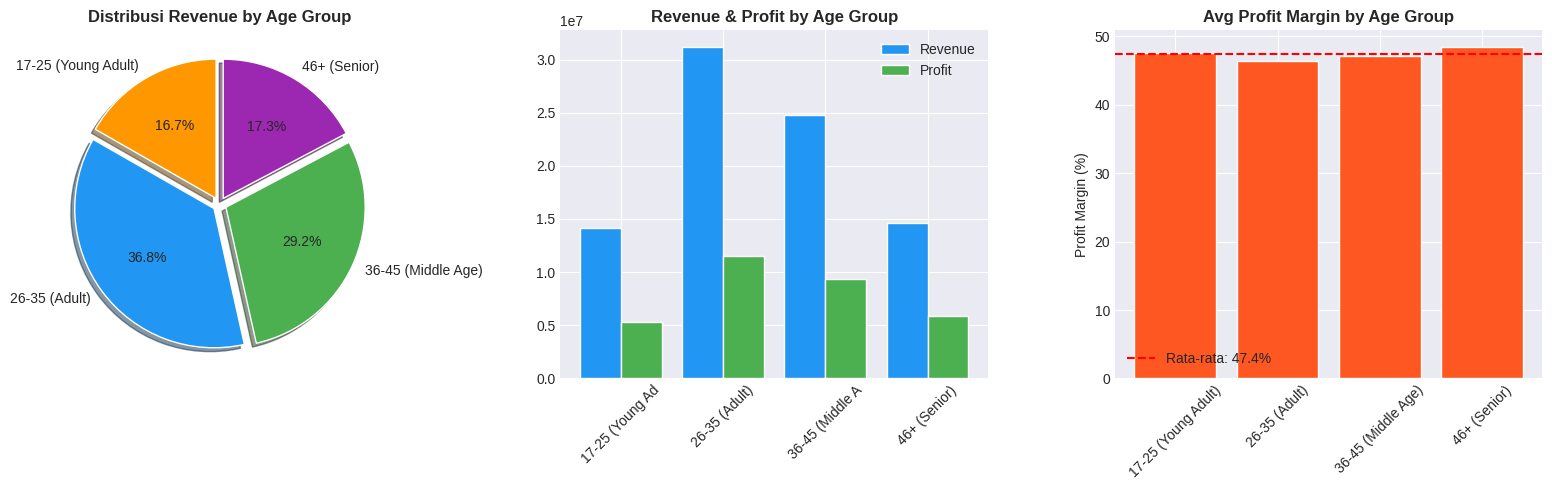


💡 INSIGHT: Age group dengan revenue tertinggi: 26-35 (Adult)
   (€31,186,542, margin 46.4%)

 7B. REVENUE BY GENDER
   Kolom gender: 'Customer_Gender'

📋 Revenue by Gender:


,Revenue,Profit,Revenue_Pct,Profit_Pct
Customer_Gender,,,,
F,41694689,15641819,49.15,4.88
M,43132083,16404420,50.85,5.12


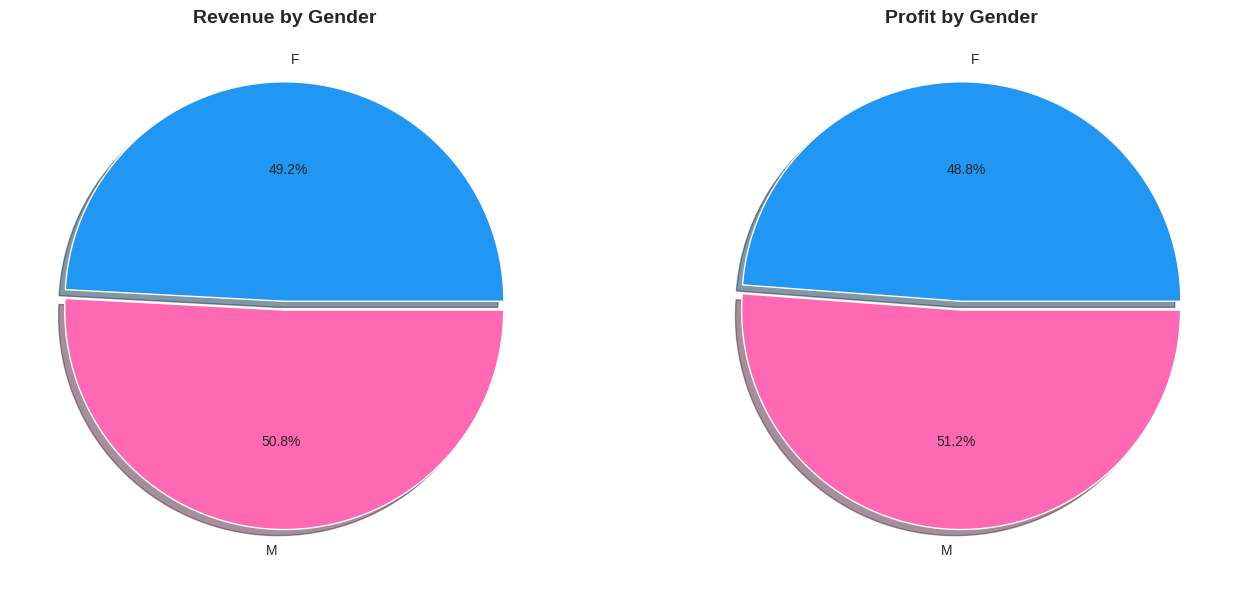


📊 7C. REVENUE BY COUNTRY

📋 Revenue by Country:


,Revenue,Profit,Profit_Margin,Revenue_Pct
Country,,,,
United States,27777098,10997638,48.15,32.75
Australia,21196395,6740522,41.84,24.99
United Kingdom,10575628,4383987,50.00,12.47
Germany,8956724,3349991,45.95,10.56
France,8414745,2872082,43.63,9.92
Canada,7906182,3702019,54.80,9.32


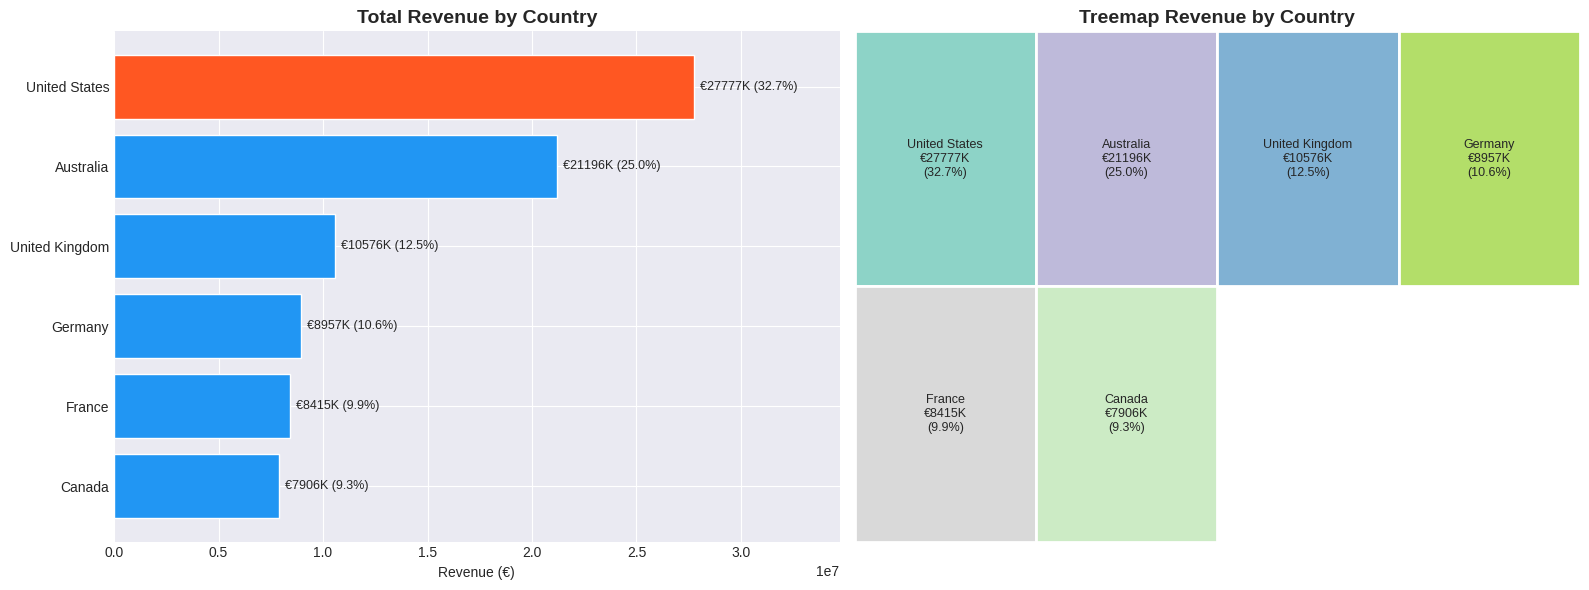


💡 INSIGHT: Negara dengan revenue terbesar: United States (32.7%)


In [ ]:
# ============================================
# CELL 7: SEGMENTASI PELANGGAN - DEMOGRAFIS
# ============================================
print("="*60)
print("👥 SEGMENTASI PELANGGAN - DEMOGRAFIS")
print("="*60)
# ----- 7a revenue by age group

print("\n📊 7A. REVENUE BY AGE GROUP")
if 'Age_Group' in df_clean.columns:
    age_data = df_clean.groupby('Age_Group').agg({
        'Revenue': 'sum',
        'Profit': 'sum',
        'Profit_Margin': 'mean',
        'Order_Quantity': 'sum' if 'Order_Quantity' in df_clean.columns else 'Revenue'
    }).round(2)

    age_order = ['17-25 (Young Adult)', '26-35 (Adult)',
                 '36-45 (Middle Age)', '46+ (Senior)']
    age_data = age_data.reindex(age_order).dropna()

    print("\n📋 Revenue by Age Group:")
    display(age_data)

    fig, axes = plt.subplots(1,3,figsize=(16,5))

    #pie chart - explode & colors dinamis
    n_age = len(age_data)
    display(n_age)
    age_colors = ['#FF9800', '#2196F3', '#4CAF50', '#9C27B0'][:n_age]
    age_explode = tuple([0.05] * n_age)

    axes[0].pie(age_data['Revenue'].dropna(), labels=age_data.dropna().index,
               autopct='%1.1f%%', colors=age_colors, explode=age_explode,
               shadow=True, startangle=90)
    axes[0].set_title('Distribusi Revenue by Age Group', fontsize=12, fontweight='bold')
    #bar cahrt revenue & profit
    x = range(n_age)
    width = 0.4
    axes[1].bar([i - width/2 for i in x], age_data['Revenue'].dropna(),
               width, label='Revenue', color='#2196F3')
    axes[1].bar([i + width/2 for i in x], age_data['Profit'].dropna(),
               width, label='Profit', color='#4CAF50')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([label[:15] for label in age_data.dropna().index], rotation=45)
    axes[1].set_title('Revenue & Profit by Age Group', fontsize=12, fontweight='bold')
    axes[1].legend()

    #profit margin
    axes[2].bar(age_data.dropna().index, age_data['Profit_Margin'].dropna(),
               color='#FF5722')
    axes[2].axhline(y=age_data['Profit_Margin'].mean(), color='red',
                   linestyle='--', label=f'Rata-rata: {age_data["Profit_Margin"].mean():.1f}%')
    axes[2].set_title('Avg Profit Margin by Age Group', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Profit Margin (%)')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('segmentasi_age.png', dpi=150, bbox_inches='tight')
    plt.show()

    best_age = age_data['Revenue'].idxmax()
    print(f"\n💡 INSIGHT: Age group dengan revenue tertinggi: {best_age}")
    print(f"   (€{age_data.loc[best_age, 'Revenue']:,.0f}, " +
          f"margin {age_data.loc[best_age, 'Profit_Margin']:.1f}%)")
else:
    print("⚠️ Kolom Age_Group tidak tersedia")

 # ---- 7B. REVENUE BY GENDER ----
print("\n" + "="*60)
print(" 7B. REVENUE BY GENDER")

gender_col =None
for col in df_clean.columns:
    if 'gender' in col.lower() or col.lower() == 'sex':
        gender_col = col
        break

if gender_col:
    print(f"   Kolom gender: '{gender_col}'")
    gender_data = df_clean.groupby(gender_col).agg({
        'Revenue': 'sum',
        'Profit': 'sum'
    }).round(2)

    gender_data['Revenue_Pct'] = (gender_data['Revenue'] / gender_data['Revenue'].sum()) * 100
    gender_data['Profit_Pct'] = (gender_data['Profit'] / gender_data['Profit'].sum()) * 10
    print("\n📋 Revenue by Gender:")
    display(gender_data)

    fig, axes = plt.subplots(1, 2, figsize=(14,6))
# ✅ explode & colors dinamis sesuai jumlah gender
    n_gender = len(gender_data)
    gender_palette = ['#2196F3', '#FF69B4', '#9E9E9E', '#FF9800']
    gender_colors  = gender_palette[:n_gender]
    gender_explode = tuple([0.02] * n_gender)

    axes[0].pie(gender_data['Revenue'], labels=gender_data.index,
               autopct='%1.1f%%', colors=gender_colors,
               explode=gender_explode, shadow=True)
    axes[0].set_title('Revenue by Gender', fontsize=14, fontweight='bold')

    axes[1].pie(gender_data['Profit'], labels=gender_data.index,
               autopct='%1.1f%%', colors=gender_colors,
               explode=gender_explode, shadow=True)
    axes[1].set_title('Profit by Gender', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('segmentasi_gender.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Kolom gender tidak ditemukan")


# ---- 7C. REVENUE BY COUNTRY ----
print("\n" + "="*60)
print("📊 7C. REVENUE BY COUNTRY")

country_col = None
for col in df_clean.columns:
    if 'country' in col.lower():
        country_col = col
        break

if country_col:
    country_data = df_clean.groupby(country_col).agg({
        'Revenue': 'sum',
        'Profit': 'sum',
        'Profit_Margin': 'mean'
    }).round(2).sort_values('Revenue', ascending=False)

    country_data['Revenue_Pct'] = (country_data['Revenue'] / country_data['Revenue'].sum()) * 100

    print("\n📋 Revenue by Country:")
    display(country_data)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Horizontal bar chart
    bar_colors = ['#FF5722' if i == 0 else '#2196F3'
                  for i in range(len(country_data))]
    axes[0].barh(country_data.index, country_data['Revenue'], color=bar_colors)
    axes[0].set_title('Total Revenue by Country', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Revenue (€)')
    axes[0].invert_yaxis()  # negara terbesar di atas

    max_rev = country_data['Revenue'].max()
    for i, (v, pct) in enumerate(zip(country_data['Revenue'], country_data['Revenue_Pct'])):
        axes[0].text(v + max_rev * 0.01, i, f'€{v/1000:.0f}K ({pct:.1f}%)', va='center', fontsize=9)
    axes[0].set_xlim(0, max_rev * 1.25)  # beri ruang untuk label

    # ✅ Treemap proporsional berdasarkan revenue (squarify jika tersedia)
    try:
        import squarify
        axes[1].axis('off')
        squarify.plot(
            sizes=country_data['Revenue'].values,
            label=[f"{c}\n€{r/1000:.0f}K\n({p:.1f}%)"
                   for c, r, p in zip(country_data.index,
                                      country_data['Revenue'],
                                      country_data['Revenue_Pct'])],
            color=[plt.cm.Set3(i / len(country_data)) for i in range(len(country_data))],
            alpha=0.85,
            text_kwargs={'fontsize': 9},
            ax=axes[1]
        )
        axes[1].set_title('Treemap Revenue by Country', fontsize=14, fontweight='bold')
        axes[1].axis('off')
    except ImportError:
        # Fallback: treemap manual grid (sama seperti sebelumnya)
        axes[1].axis('off')
        n_cols = 4
        n_rows = int(np.ceil(len(country_data) / n_cols))
        for i, (c, r, p) in enumerate(zip(country_data.index,
                                           country_data['Revenue'],
                                           country_data['Revenue_Pct'])):
            row, col = i // n_cols, i % n_cols
            rect = plt.Rectangle(
                (col / n_cols, 1 - (row + 1) / n_rows),
                1 / n_cols, 1 / n_rows,
                facecolor=plt.cm.Set3(i / len(country_data)),
                edgecolor='white', linewidth=2
            )
            axes[1].add_patch(rect)
            axes[1].text(col / n_cols + 1 / (2 * n_cols),
                         1 - (row + 1) / n_rows + 1 / (2 * n_rows),
                         f'{c}\n€{r/1000:.0f}K\n({p:.1f}%)',
                         ha='center', va='center', fontsize=9)
        axes[1].set_xlim(0, 1)
        axes[1].set_ylim(0, 1)
        axes[1].set_title('Treemap Revenue by Country', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('segmentasi_country.png', dpi=150, bbox_inches='tight')
    plt.show()

    top_country = country_data.index[0]
    top_pct = country_data['Revenue_Pct'].iloc[0]
    print(f"\n💡 INSIGHT: Negara dengan revenue terbesar: {top_country} ({top_pct:.1f}%)")
else:
    print("⚠️ Kolom country tidak ditemukan")

🎯 RFM SEGMENTATION - SEGMENTASI PERILAKU PELANGGAN

🔍 STEP 1: Deteksi kolom untuk RFM...
   📅 Kolom Tanggal  : Date
   👤 Kolom Customer : Customer_Age
   💰 Kolom Revenue  : Revenue
   📦 Kolom Order    : Order_Quantity

📦 STEP 2: Persiapan data RFM...
   📆 Snapshot Date  : 2016-08-01
   👥 Total Customer : 70

📐 STEP 3: Menghitung nilai Recency, Frequency, Monetary...

📋 Sample Data RFM (5 baris pertama):


,Customer_Age,Recency,Frequency,Monetary
0,17,1,1289,723548
1,18,3,1746,1301624
2,19,1,1989,1403659
3,20,3,2000,892779
4,21,1,2209,1236169



📊 Statistik RFM:


,Recency,Frequency,Monetary
count,70.00,70.00,70.00
mean,25.97,1600.51,1211811.03
std,51.49,1463.40,1199163.19
min,1.00,4.00,251.00
25%,1.00,48.50,25407.00
50%,3.00,1470.50,961918.50
75%,22.25,2961.75,2426894.75
max,250.00,4343.00,4046719.00



🎯 STEP 4: Scoring RFM (skala 1–5)...

🏷️  STEP 5: Segmentasi pelanggan berdasarkan skor RFM...

📋 Ringkasan Segmen RFM:


,Jumlah_Customer,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Customer
Segment,,,,,,
Champions,19,1.16,3193.58,2541227.42,48283321,27.10
Loyal Customers,21,2.05,1930.10,1322565.24,27773870,30.00
At Risk,2,5.00,3694.00,3430104.50,6860209,2.90
Need Attention,10,18.20,241.60,143020.30,1430203,14.30
Potential Loyalists,2,3.00,385.50,190127.00,380254,2.90
Hibernating,6,36.50,24.17,11807.17,70843,8.60
Lost,10,133.60,10.60,2807.20,28072,14.30



📊 STEP 6: Visualisasi RFM...


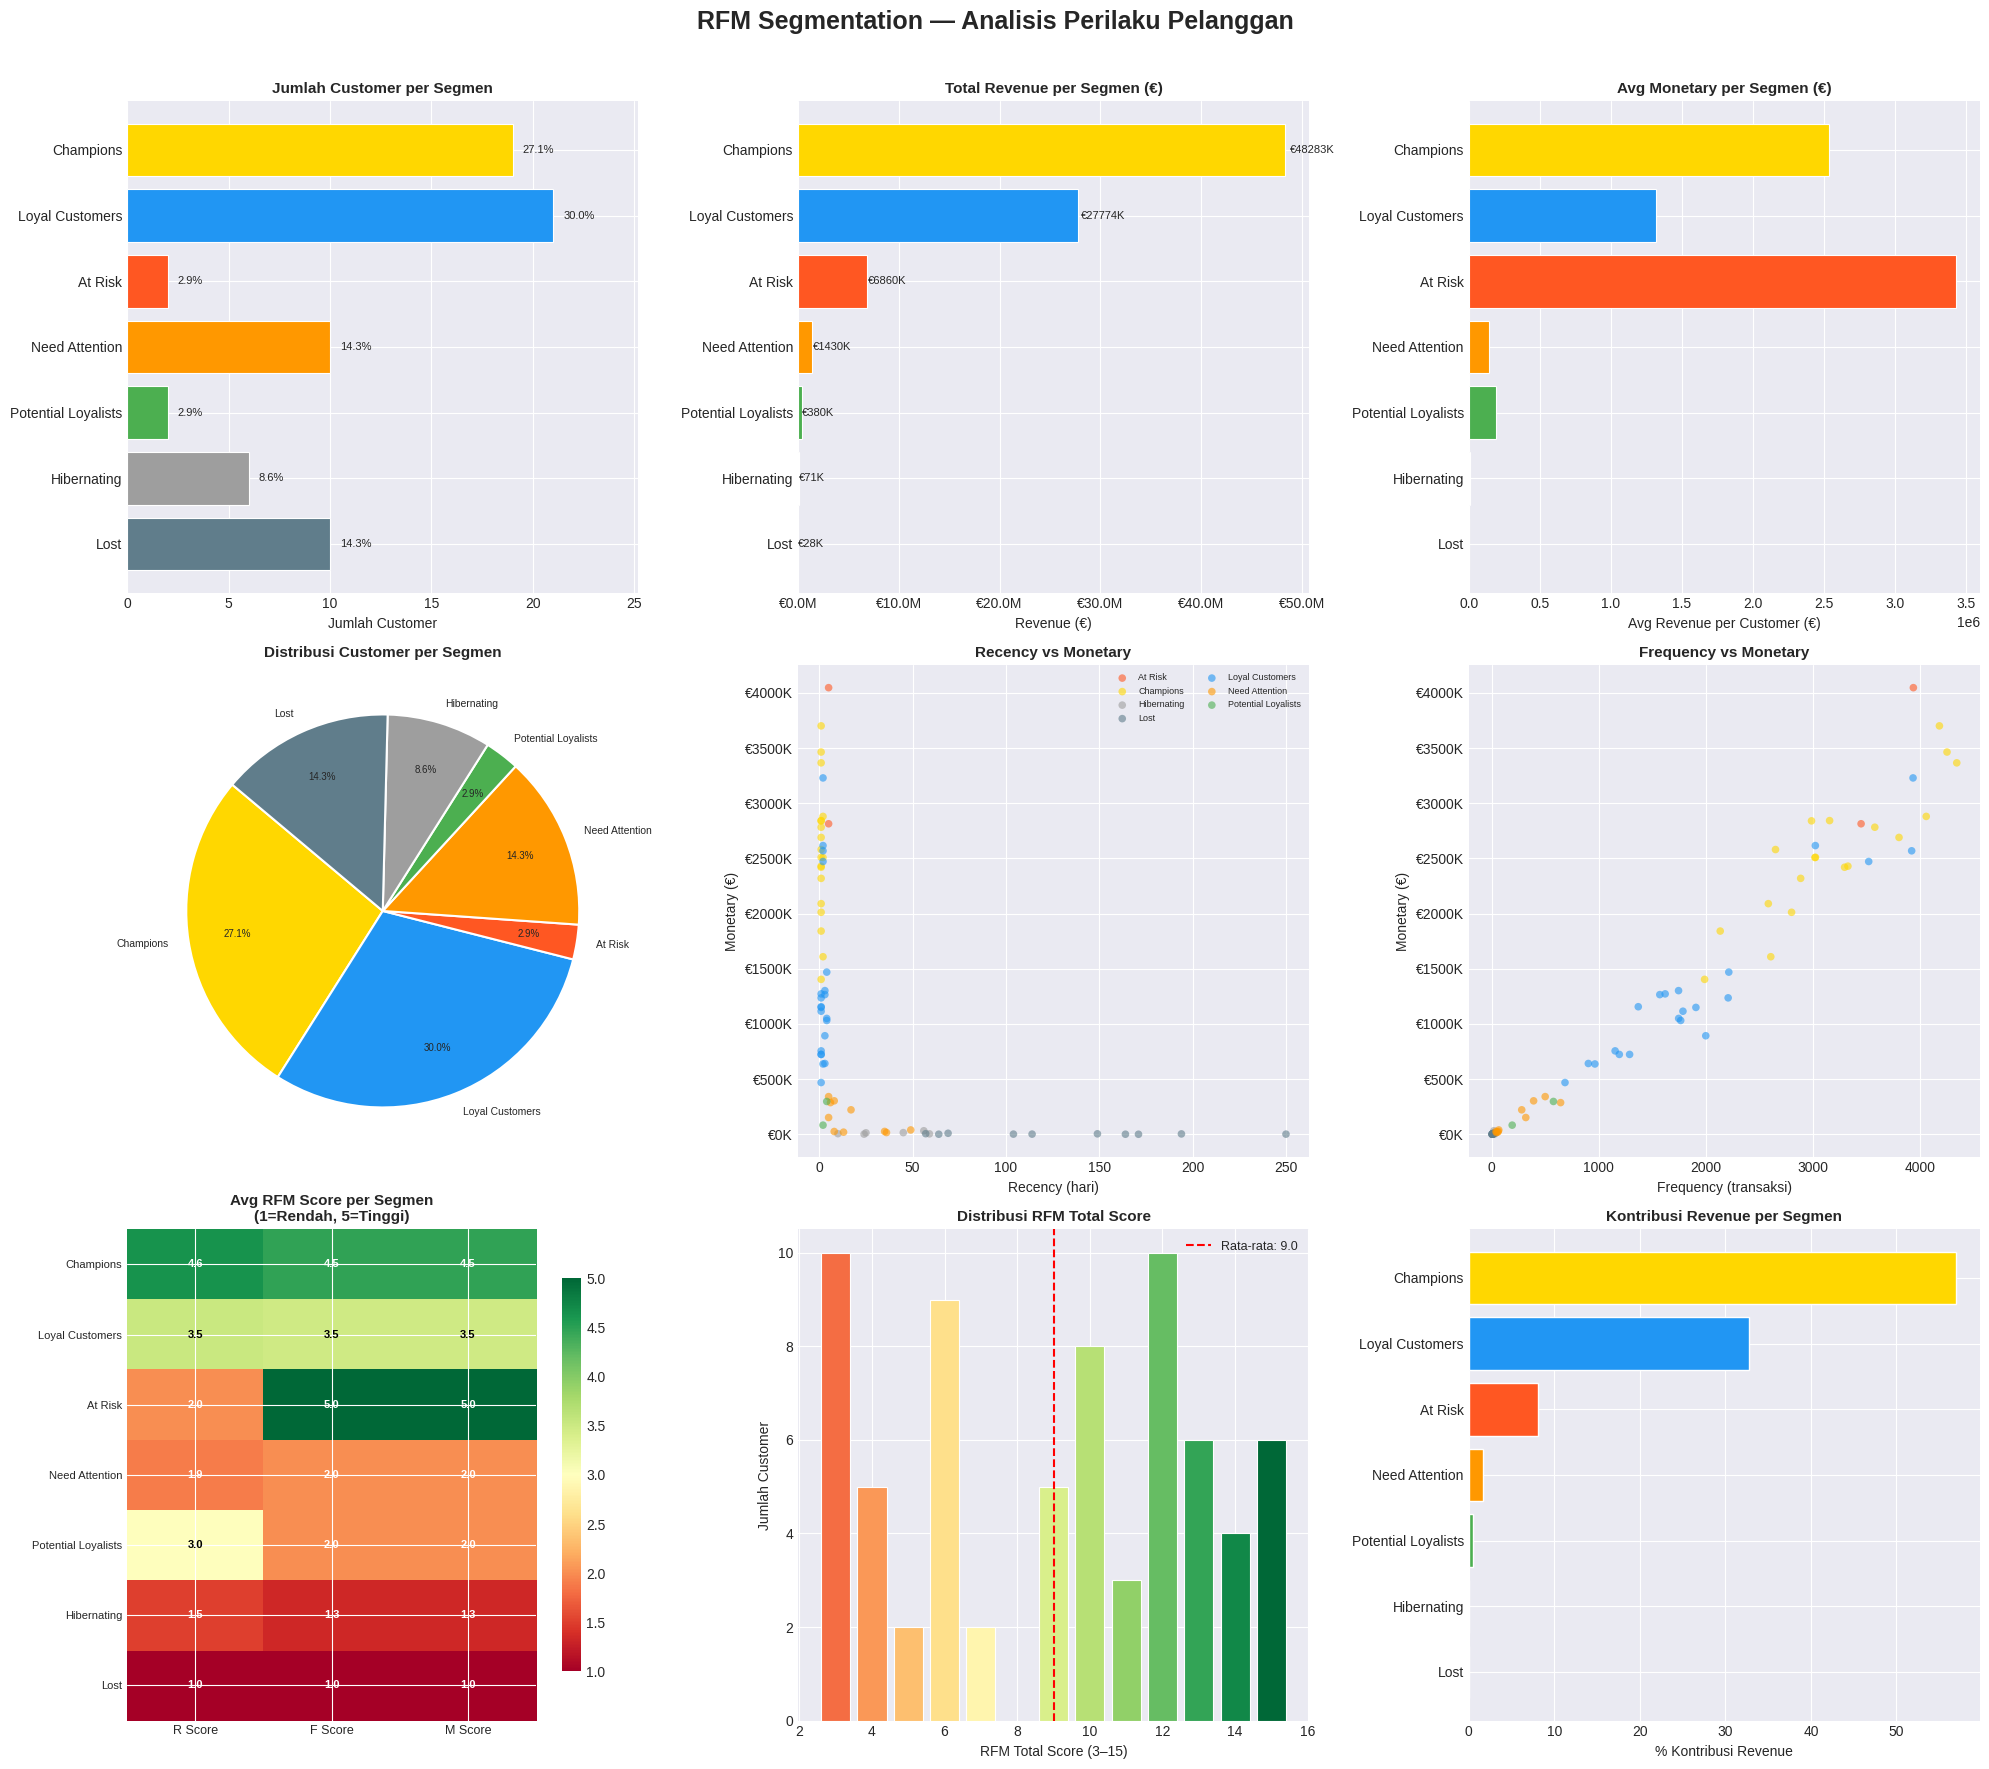


💡 INSIGHT & REKOMENDASI STRATEGI PER SEGMEN

▸ Champions (19 customer | 27.1% | €48,283,321 revenue)
  🏆 Reward mereka! Ajak jadi brand ambassador, beri early access produk baru.

▸ Loyal Customers (21 customer | 30.0% | €27,773,870 revenue)
  💙 Maintain dengan loyalty program & exclusive offers.

▸ At Risk (2 customer | 2.9% | €6,860,209 revenue)
  🚨 Kirim email personal, tanyakan feedback, beri penawaran retention.

▸ Need Attention (10 customer | 14.3% | €1,430,203 revenue)
  ⚠️  Buat campaign reaktivasi, tawarkan bundle atau diskon terbatas.

▸ Potential Loyalists (2 customer | 2.9% | €380,254 revenue)
  🌱 Tawarkan membership program, upsell produk premium.

▸ Hibernating (6 customer | 8.6% | €70,843 revenue)
  😴 Kirim konten inspiratif + promo kecil untuk bangunkan mereka.

▸ Lost (10 customer | 14.3% | €28,072 revenue)
  💤 Re-engagement campaign terakhir. Jika tidak respons, fokus ke segmen lain.

📌 RINGKASAN EKSEKUTIF
   👥 Total Customer        : 70
   💰 Total Revenue         :

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CELL 8: RFM SEGMENTATION (SEGMENTASI PERILAKU)
# ============================================================

print("="*60)
print("🎯 RFM SEGMENTATION - SEGMENTASI PERILAKU PELANGGAN")
print("="*60)

# ============================================================
# STEP 1: DETEKSI KOLOM YANG DIPERLUKAN
# ============================================================
print("\n🔍 STEP 1: Deteksi kolom untuk RFM...")

# Deteksi kolom tanggal
date_col = None
for col in df_clean.columns:
    if any(k in col.lower() for k in ['date', 'order_date', 'tanggal', 'transaction']):
        date_col = col
        break

# Deteksi kolom customer ID
customer_col = None
for col in df_clean.columns:
    if any(k in col.lower() for k in ['customer_id', 'customer', 'cust_id', 'pelanggan']):
        customer_col = col
        break

# Deteksi kolom revenue & order
revenue_col  = 'Revenue' if 'Revenue' in df_clean.columns else None
order_col    = 'Order_Quantity' if 'Order_Quantity' in df_clean.columns else None

print(f"   📅 Kolom Tanggal  : {date_col}")
print(f"   👤 Kolom Customer : {customer_col}")
print(f"   💰 Kolom Revenue  : {revenue_col}")
print(f"   📦 Kolom Order    : {order_col}")

if not all([date_col, customer_col, revenue_col]):
    print("\n⚠️  Kolom wajib tidak lengkap untuk RFM. Proses dihentikan.")
else:
    # ============================================================
    # STEP 2: PERSIAPAN DATA
    # ============================================================
    print("\n📦 STEP 2: Persiapan data RFM...")

    df_rfm_raw = df_clean[[customer_col, date_col, revenue_col]].copy()
    df_rfm_raw[date_col] = pd.to_datetime(df_rfm_raw[date_col], errors='coerce')
    df_rfm_raw = df_rfm_raw.dropna(subset=[date_col])

    # Snapshot date = 1 hari setelah transaksi terakhir
    snapshot_date = df_rfm_raw[date_col].max() + pd.Timedelta(days=1)
    print(f"   📆 Snapshot Date  : {snapshot_date.date()}")
    print(f"   👥 Total Customer : {df_rfm_raw[customer_col].nunique():,}")

    # ============================================================
    # STEP 3: HITUNG R, F, M
    # ============================================================
    print("\n📐 STEP 3: Menghitung nilai Recency, Frequency, Monetary...")

    rfm = df_rfm_raw.groupby(customer_col).agg(
        Recency   = (date_col,    lambda x: (snapshot_date - x.max()).days),
        Frequency = (date_col,    'count'),
        Monetary  = (revenue_col, 'sum')
    ).reset_index()

    rfm['Monetary'] = rfm['Monetary'].round(2)

    print("\n📋 Sample Data RFM (5 baris pertama):")
    display(rfm.head())
    print(f"\n📊 Statistik RFM:")
    display(rfm[['Recency','Frequency','Monetary']].describe().round(2))

    # ============================================================
    # STEP 4: SCORING R, F, M (skala 1–5)
    # ============================================================
    print("\n🎯 STEP 4: Scoring RFM (skala 1–5)...")

    # Recency: semakin kecil semakin bagus → skor 5
    rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5,
                              labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

    # Frequency: semakin besar semakin bagus → skor 5
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5,
                              labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

    # Monetary: semakin besar semakin bagus → skor 5
    rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5,
                              labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

    # RFM Score gabungan (string) & total
    rfm['RFM_Score']  = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
    rfm['RFM_Total']  = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

    # ============================================================
    # STEP 5: SEGMENTASI PELANGGAN
    # ============================================================
    print("\n🏷️  STEP 5: Segmentasi pelanggan berdasarkan skor RFM...")

    def rfm_segment(row):
        r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
        total = row['RFM_Total']

        if r >= 4 and f >= 4 and m >= 4:
            return 'Champions'
        elif r >= 3 and f >= 3 and m >= 3:
            return 'Loyal Customers'
        elif r >= 4 and f <= 2:
            return 'New Customers'
        elif r >= 3 and f >= 2 and m >= 2:
            return 'Potential Loyalists'
        elif r >= 4 and f >= 1 and m >= 1:
            return 'Recent Customers'
        elif r == 3 and f <= 2:
            return 'Promising'
        elif r <= 2 and f >= 4 and m >= 4:
            return 'At Risk'
        elif r <= 2 and f >= 2 and m >= 2:
            return 'Need Attention'
        elif r <= 2 and f <= 2 and m >= 3:
            return 'Cant Lose Them'
        elif r == 1 and f == 1 and m == 1:
            return 'Lost'
        else:
            return 'Hibernating'

    rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

    # Ringkasan per segmen
    segment_summary = rfm.groupby('Segment').agg(
        Jumlah_Customer = ('Segment', 'count'),
        Avg_Recency     = ('Recency',   'mean'),
        Avg_Frequency   = ('Frequency', 'mean'),
        Avg_Monetary    = ('Monetary',  'mean'),
        Total_Revenue   = ('Monetary',  'sum')
    ).round(2).sort_values('Total_Revenue', ascending=False)

    segment_summary['Pct_Customer'] = (
        segment_summary['Jumlah_Customer'] / segment_summary['Jumlah_Customer'].sum() * 100
    ).round(1)

    print("\n📋 Ringkasan Segmen RFM:")
    display(segment_summary)

    # ============================================================
    # STEP 6: VISUALISASI
    # ============================================================
    print("\n📊 STEP 6: Visualisasi RFM...")

    # Warna per segmen
    segment_colors = {
        'Champions'          : '#FFD700',
        'Loyal Customers'    : '#2196F3',
        'Potential Loyalists': '#4CAF50',
        'New Customers'      : '#00BCD4',
        'Recent Customers'   : '#8BC34A',
        'Promising'          : '#03A9F4',
        'Need Attention'     : '#FF9800',
        'At Risk'            : '#FF5722',
        'Cant Lose Them'     : '#E91E63',
        'Hibernating'        : '#9E9E9E',
        'Lost'               : '#607D8B',
    }

    seg_colors_list = [segment_colors.get(s, '#CCCCCC') for s in segment_summary.index]

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle('RFM Segmentation — Analisis Perilaku Pelanggan',
                 fontsize=18, fontweight='bold', y=0.98)

    # ── Plot 1: Distribusi Jumlah Customer per Segmen ──────────
    ax1 = fig.add_subplot(3, 3, 1)
    bars = ax1.barh(segment_summary.index, segment_summary['Jumlah_Customer'],
                    color=seg_colors_list, edgecolor='white', linewidth=0.8)
    ax1.set_title('Jumlah Customer per Segmen', fontweight='bold', fontsize=11)
    ax1.set_xlabel('Jumlah Customer')
    for bar, pct in zip(bars, segment_summary['Pct_Customer']):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=8)
    ax1.set_xlim(0, segment_summary['Jumlah_Customer'].max() * 1.2)
    ax1.invert_yaxis()

    # ── Plot 2: Total Revenue per Segmen ───────────────────────
    ax2 = fig.add_subplot(3, 3, 2)
    bars2 = ax2.barh(segment_summary.index, segment_summary['Total_Revenue'],
                     color=seg_colors_list, edgecolor='white', linewidth=0.8)
    ax2.set_title('Total Revenue per Segmen (€)', fontweight='bold', fontsize=11)
    ax2.set_xlabel('Revenue (€)')
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v/1e6:.1f}M'))
    for bar in bars2:
        ax2.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                 f'€{bar.get_width()/1000:.0f}K', va='center', fontsize=8)
    ax2.invert_yaxis()

    # ── Plot 3: Avg Monetary per Segmen ────────────────────────
    ax3 = fig.add_subplot(3, 3, 3)
    bars3 = ax3.barh(segment_summary.index, segment_summary['Avg_Monetary'],
                     color=seg_colors_list, edgecolor='white', linewidth=0.8)
    ax3.set_title('Avg Monetary per Segmen (€)', fontweight='bold', fontsize=11)
    ax3.set_xlabel('Avg Revenue per Customer (€)')
    ax3.invert_yaxis()

    # ── Plot 4: Pie Chart distribusi customer ──────────────────
    ax4 = fig.add_subplot(3, 3, 4)
    wedges, texts, autotexts = ax4.pie(
        segment_summary['Jumlah_Customer'],
        labels=segment_summary.index,
        autopct='%1.1f%%',
        colors=seg_colors_list,
        startangle=140,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for text in texts:
        text.set_fontsize(7.5)
    for at in autotexts:
        at.set_fontsize(7)
    ax4.set_title('Distribusi Customer per Segmen', fontweight='bold', fontsize=11)

    # ── Plot 5: Scatter Recency vs Monetary (warna = segmen) ───
    ax5 = fig.add_subplot(3, 3, 5)
    for seg, grp in rfm.groupby('Segment'):
        ax5.scatter(grp['Recency'], grp['Monetary'],
                    c=segment_colors.get(seg, '#CCCCCC'),
                    label=seg, alpha=0.6, s=30, edgecolors='none')
    ax5.set_xlabel('Recency (hari)')
    ax5.set_ylabel('Monetary (€)')
    ax5.set_title('Recency vs Monetary', fontweight='bold', fontsize=11)
    ax5.legend(fontsize=6.5, loc='upper right', ncol=2)
    ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v/1000:.0f}K'))

    # ── Plot 6: Scatter Frequency vs Monetary ──────────────────
    ax6 = fig.add_subplot(3, 3, 6)
    for seg, grp in rfm.groupby('Segment'):
        ax6.scatter(grp['Frequency'], grp['Monetary'],
                    c=segment_colors.get(seg, '#CCCCCC'),
                    label=seg, alpha=0.6, s=30, edgecolors='none')
    ax6.set_xlabel('Frequency (transaksi)')
    ax6.set_ylabel('Monetary (€)')
    ax6.set_title('Frequency vs Monetary', fontweight='bold', fontsize=11)
    ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v/1000:.0f}K'))

    # ── Plot 7: Heatmap Avg RFM Score per Segmen ───────────────
    ax7 = fig.add_subplot(3, 3, 7)
    heatmap_data = rfm.groupby('Segment')[['R_Score','F_Score','M_Score']].mean().round(2)
    heatmap_data = heatmap_data.reindex(segment_summary.index)  # urutan sama

    im = ax7.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
                    vmin=1, vmax=5)
    ax7.set_xticks(range(3))
    ax7.set_xticklabels(['R Score', 'F Score', 'M Score'], fontsize=9)
    ax7.set_yticks(range(len(heatmap_data)))
    ax7.set_yticklabels(heatmap_data.index, fontsize=8)
    ax7.set_title('Avg RFM Score per Segmen\n(1=Rendah, 5=Tinggi)',
                  fontweight='bold', fontsize=11)
    for i in range(len(heatmap_data)):
        for j in range(3):
            val = heatmap_data.values[i, j]
            ax7.text(j, i, f'{val:.1f}', ha='center', va='center',
                     fontsize=8, fontweight='bold',
                     color='white' if val < 2.5 or val > 4 else 'black')
    plt.colorbar(im, ax=ax7, shrink=0.8)

    # ── Plot 8: Bar RFM Total Score Distribution ───────────────
    ax8 = fig.add_subplot(3, 3, 8)
    rfm_dist = rfm['RFM_Total'].value_counts().sort_index()
    ax8.bar(rfm_dist.index, rfm_dist.values,
            color=plt.cm.RdYlGn(rfm_dist.index / 15),
            edgecolor='white', linewidth=0.8)
    ax8.set_xlabel('RFM Total Score (3–15)')
    ax8.set_ylabel('Jumlah Customer')
    ax8.set_title('Distribusi RFM Total Score', fontweight='bold', fontsize=11)
    ax8.axvline(x=rfm['RFM_Total'].mean(), color='red', linestyle='--',
                label=f'Rata-rata: {rfm["RFM_Total"].mean():.1f}')
    ax8.legend(fontsize=9)

    # ── Plot 9: Treemap-style — kontribusi revenue ─────────────
    ax9 = fig.add_subplot(3, 3, 9)
    try:
        import squarify
        squarify.plot(
            sizes=segment_summary['Total_Revenue'].values,
            label=[f"{s}\n{n} cust\n€{r/1000:.0f}K"
                   for s, n, r in zip(segment_summary.index,
                                      segment_summary['Jumlah_Customer'],
                                      segment_summary['Total_Revenue'])],
            color=seg_colors_list,
            alpha=0.85,
            text_kwargs={'fontsize': 7.5},
            ax=ax9
        )
        ax9.axis('off')
    except ImportError:
        # Fallback: horizontal bar
        ax9.barh(segment_summary.index,
                 segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100,
                 color=seg_colors_list)
        ax9.set_xlabel('% Kontribusi Revenue')
        ax9.invert_yaxis()
    ax9.set_title('Kontribusi Revenue per Segmen', fontweight='bold', fontsize=11)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================================
    # STEP 7: INSIGHT & REKOMENDASI STRATEGI
    # ============================================================
    print("\n" + "="*60)
    print("💡 INSIGHT & REKOMENDASI STRATEGI PER SEGMEN")
    print("="*60)

    strategi = {
        'Champions'          : '🏆 Reward mereka! Ajak jadi brand ambassador, beri early access produk baru.',
        'Loyal Customers'    : '💙 Maintain dengan loyalty program & exclusive offers.',
        'Potential Loyalists': '🌱 Tawarkan membership program, upsell produk premium.',
        'New Customers'      : '👋 Onboarding yang kuat, edukasi produk, sambut dengan welcome offer.',
        'Recent Customers'   : '🆕 Bantu mereka kembali — kirim rekomendasi produk terkait.',
        'Promising'          : '🔮 Bangun hubungan — beri trial premium atau diskon kedua pembelian.',
        'Need Attention'     : '⚠️  Buat campaign reaktivasi, tawarkan bundle atau diskon terbatas.',
        'At Risk'            : '🚨 Kirim email personal, tanyakan feedback, beri penawaran retention.',
        'Cant Lose Them'     : '🆘 Hubungi langsung! Beri penawaran eksklusif sebelum terlambat.',
        'Hibernating'        : '😴 Kirim konten inspiratif + promo kecil untuk bangunkan mereka.',
        'Lost'               : '💤 Re-engagement campaign terakhir. Jika tidak respons, fokus ke segmen lain.',
    }

    for seg in segment_summary.index:
        n   = segment_summary.loc[seg, 'Jumlah_Customer']
        rev = segment_summary.loc[seg, 'Total_Revenue']
        pct = segment_summary.loc[seg, 'Pct_Customer']
        print(f"\n▸ {seg} ({n} customer | {pct:.1f}% | €{rev:,.0f} revenue)")
        print(f"  {strategi.get(seg, '—')}")

    print("\n" + "="*60)
    print("📌 RINGKASAN EKSEKUTIF")
    print("="*60)

    top_seg     = segment_summary['Total_Revenue'].idxmax()
    top_rev     = segment_summary.loc[top_seg, 'Total_Revenue']
    top_cust    = segment_summary.loc[top_seg, 'Jumlah_Customer']
    total_cust  = rfm.shape[0]
    total_rev   = rfm['Monetary'].sum()
    avg_rfm     = rfm['RFM_Total'].mean()
    champions_n = segment_summary.loc['Champions', 'Jumlah_Customer'] if 'Champions' in segment_summary.index else 0
    at_risk_n   = segment_summary.loc['At Risk', 'Jumlah_Customer'] if 'At Risk' in segment_summary.index else 0

    print(f"   👥 Total Customer        : {total_cust:,}")
    print(f"   💰 Total Revenue         : €{total_rev:,.2f}")
    print(f"   📊 Avg RFM Score         : {avg_rfm:.1f} / 15")
    print(f"   🏆 Champions             : {champions_n:,} customer")
    print(f"   🚨 At Risk               : {at_risk_n:,} customer (prioritas retention!)")
    print(f"   🥇 Segmen Revenue Terbesar: {top_seg} (€{top_rev:,.0f} | {top_cust} cust)")

    # Simpan hasil RFM ke dataframe baru
    rfm_final = rfm.copy()
    print(f"\n✅ Data RFM tersimpan di variabel: rfm_final")
    print(f"   Kolom: {list(rfm_final.columns)}")


🌍 ANALISIS GEOGRAFIS - CHOROPLETH MAP

📋 Data per Negara:


,Country,Revenue,Profit,Profit_Margin,Order_Quantity
5,United States,27777098,10997638,48.15,473880
0,Australia,21196395,6740522,41.84,261227
4,United Kingdom,10575628,4383987,50.00,155769
3,Germany,8956724,3349991,45.95,124755
2,France,8414745,2872082,43.63,127872
1,Canada,7906182,3702019,54.80,190202



🗺️ Membuat peta interaktif...
   Scope peta: world


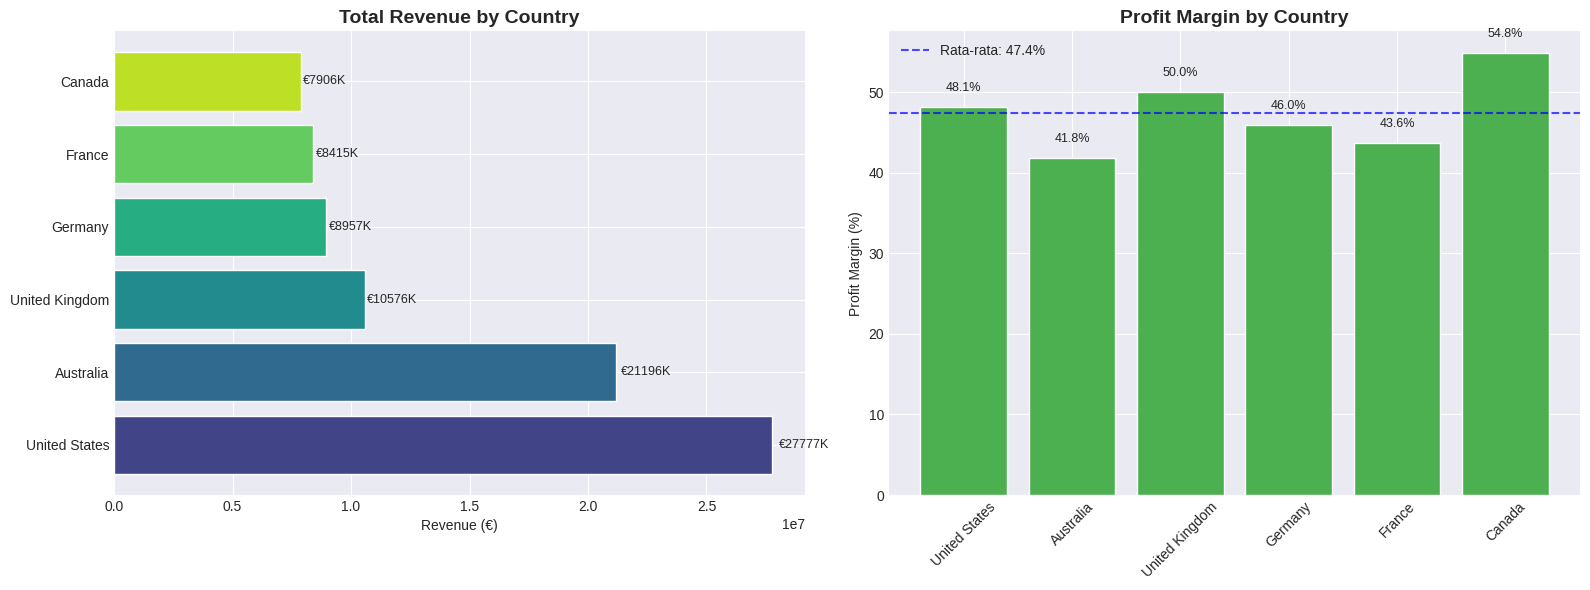


💡 INSIGHT GEOGRAFIS:
   🌟 Top performer: United States (Revenue: €27,777,098, Margin: 48.1%)


In [39]:
# ============================================
# CELL 9: ANALISIS GEOGRAFIS
# ============================================

print("="*60)
print("🌍 ANALISIS GEOGRAFIS - CHOROPLETH MAP")
print("="*60)

# Cari kolom country
country_col = None
for col in df_clean.columns:
    if 'country' in col.lower():
        country_col = col
        break

if country_col:
    # Agregasi per negara
    geo_data = df_clean.groupby(country_col).agg({
        'Revenue': 'sum',
        'Profit': 'sum',
        'Profit_Margin': 'mean',
        'Order_Quantity': 'sum' if 'Order_Quantity' in df_clean.columns else 'Revenue'
    }).round(2).reset_index()

    geo_data = geo_data.sort_values('Revenue', ascending=False)

    print("\n📋 Data per Negara:")
    display(geo_data)

    # ---- CHOROPLETH MAP INTERAKTIF ----
    print("\n🗺️ Membuat peta interaktif...")

    # Mapping nama negara ke ISO code jika perlu
    country_mapping = {
        'United Kingdom': 'GBR',
        'United States': 'USA',
        'France': 'FRA',
        'Germany': 'DEU',
        'Italy': 'ITA',
        'Spain': 'ESP',
        'Netherlands': 'NLD',
        'Belgium': 'BEL',
        'Austria': 'AUT',
        'Switzerland': 'CHE',
        'Portugal': 'PRT',
        'Sweden': 'SWE',
        'Denmark': 'DNK',
        'Norway': 'NOR',
        'Finland': 'FIN',
        'Ireland': 'IRL',
        'Poland': 'POL',
        'Czech Republic': 'CZE'
    }

    geo_data['Country_Code'] = geo_data[country_col].map(country_mapping)

    # Jika ada yang tidak ter-mapping, gunakan nama asli
    geo_data['Country_Code'] = geo_data['Country_Code'].fillna(geo_data[country_col])

    # Cek apakah data untuk Eropa
    european_countries = ['GBR', 'FRA', 'DEU', 'ITA', 'ESP', 'NLD', 'BEL', 'AUT',
                         'CHE', 'PRT', 'SWE', 'DNK', 'NOR', 'FIN', 'IRL', 'POL', 'CZE']
    is_europe = geo_data['Country_Code'].isin(european_countries).all()

    scope = 'europe' if is_europe else 'world'
    print(f"   Scope peta: {scope}")

    # Buat choropleth
    fig = px.choropleth(
        geo_data,
        locations='Country_Code',
        color='Revenue',
        hover_name=country_col,
        hover_data={
            'Revenue': ':,.0f',
            'Profit': ':,.0f',
            'Profit_Margin': ':.1f',
            'Country_Code': False
        },
        color_continuous_scale='Viridis',
        title=f'Revenue by Country - Bike Store Sales ({df_clean["Year"].min()}-{df_clean["Year"].max()})',
        scope=scope
    )

    fig.update_geos(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="Black",
        showland=True,
        landcolor="lightgray"
    )

    fig.update_layout(
        height=600,
        title_x=0.5,
        title_font_size=16
    )

    fig.show()

    # ---- BAR CHART REVENUE PER NEGARA ----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Horizontal bar
    bars = ax1.barh(geo_data[country_col], geo_data['Revenue'],
                   color=plt.cm.viridis(np.linspace(0.2, 0.9, len(geo_data))))
    ax1.set_title('Total Revenue by Country', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Revenue (€)')
    for bar, (_, row) in zip(bars, geo_data.iterrows()):
        width = bar.get_width()
        ax1.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
                f'€{row["Revenue"]/1000:.0f}K', va='center', fontsize=9)

    # Profit margin
    colors_margin = ['#4CAF50' if x > 0 else '#F44336' for x in geo_data['Profit_Margin']]
    ax2.bar(geo_data[country_col], geo_data['Profit_Margin'], color=colors_margin)
    ax2.axhline(y=0, color='black', linewidth=0.5)
    ax2.axhline(y=geo_data['Profit_Margin'].mean(), color='blue',
               linestyle='--', alpha=0.7,
               label=f'Rata-rata: {geo_data["Profit_Margin"].mean():.1f}%')
    ax2.set_title('Profit Margin by Country', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Profit Margin (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend()
    for i, v in enumerate(geo_data['Profit_Margin']):
        ax2.text(i, v + (2 if v >= 0 else -4), f'{v:.1f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('geo_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ---- INSIGHT ----
    print("\n💡 INSIGHT GEOGRAFIS:")
    print(f"   🌟 Top performer: {geo_data.iloc[0][country_col]} " +
          f"(Revenue: €{geo_data.iloc[0]['Revenue']:,.0f}, " +
          f"Margin: {geo_data.iloc[0]['Profit_Margin']:.1f}%)")

    if 'Profit_Margin' in geo_data.columns:
        negative_margin = geo_data[geo_data['Profit_Margin'] < 0]
        if len(negative_margin) > 0:
            print(f"   ⚠️ Negara dengan margin negatif:")
            for _, row in negative_margin.iterrows():
                print(f"      - {row[country_col]}: {row['Profit_Margin']:.1f}%")
else:
    print("⚠️ Kolom country tidak ditemukan")

In [49]:
# ============================================================
# CELL 11: EXPORT HASIL ANALISIS - LENGKAP (Excel + Charts)
# ============================================================

print("📁 Mengexport hasil analisis ke Excel lengkap...")

import os
import pandas as pd
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import (
    Font, PatternFill, Alignment, Border, Side, numbers
)
from openpyxl.chart import BarChart, LineChart, PieChart, Reference
from openpyxl.chart.series import DataPoint
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows

os.makedirs('/content/output', exist_ok=True)

# ── Helper styles ──────────────────────────────────────────
BLUE_DARK   = "1F4E79"
BLUE_MED    = "2E75B6"
BLUE_LIGHT  = "BDD7EE"
GREEN_DARK  = "375623"
GREEN_LIGHT = "E2EFDA"
ORANGE      = "F4B942"
WHITE       = "FFFFFF"
GRAY_LIGHT  = "F2F2F2"
GRAY_BORDER = "BFBFBF"

def header_style(cell, bg=BLUE_DARK, fg=WHITE, bold=True, size=11, center=True):
    cell.font = Font(name="Arial", bold=bold, color=fg, size=size)
    cell.fill = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(
        horizontal="center" if center else "left",
        vertical="center", wrap_text=True
    )

def subheader_style(cell, bg=BLUE_MED, fg=WHITE):
    cell.font = Font(name="Arial", bold=True, color=fg, size=10)
    cell.fill = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(horizontal="center", vertical="center")

def data_style(cell, bg=WHITE, center=False, currency=False, pct=False):
    cell.font = Font(name="Arial", size=10)
    cell.fill = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(
        horizontal="center" if center else "right",
        vertical="center"
    )
    if currency:
        cell.number_format = '#,##0'
    elif pct:
        cell.number_format = '0.0%'

def alt_row(row_idx):
    return GRAY_LIGHT if row_idx % 2 == 0 else WHITE

def thin_border():
    side = Side(style="thin", color=GRAY_BORDER)
    return Border(left=side, right=side, top=side, bottom=side)

def apply_border_range(ws, min_row, max_row, min_col, max_col):
    for row in ws.iter_rows(min_row=min_row, max_row=max_row,
                             min_col=min_col, max_col=max_col):
        for cell in row:
            cell.border = thin_border()

def set_col_widths(ws, widths: dict):
    for col, w in widths.items():
        ws.column_dimensions[col].width = w

def freeze_and_filter(ws, freeze_cell, filter_range=None):
    ws.freeze_panes = freeze_cell
    if filter_range:
        ws.auto_filter.ref = filter_range

# ── Pastikan kolom wajib ada ───────────────────────────────
required_cols = {'Year', 'Revenue', 'Profit'}
missing = required_cols - set(df_clean.columns)
if missing:
    raise ValueError(f"Kolom tidak ditemukan di df_clean: {missing}")

# Deteksi kolom opsional
def find_col(keywords, df):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match:
            return match[0]
    return None

product_col   = find_col(['product'], df_clean) or 'Product'
category_col  = find_col(['category'], df_clean)
region_col    = find_col(['region', 'country', 'state', 'city'], df_clean)
month_col     = find_col(['month'], df_clean)
qty_col       = find_col(['quantity', 'qty', 'units'], df_clean)
cost_col      = find_col(['cost', 'cogs'], df_clean)

# ── Aggregasi dasar ────────────────────────────────────────
yearly = df_clean.groupby('Year').agg(
    Revenue=('Revenue', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Revenue', 'count'),
).reset_index()
yearly['Profit_Margin'] = yearly['Profit'] / yearly['Revenue']
yearly['YoY_Revenue'] = yearly['Revenue'].pct_change()
yearly['YoY_Profit']  = yearly['Profit'].pct_change()

top_products = (
    df_clean.groupby(product_col)['Revenue'].sum()
    .sort_values(ascending=False).reset_index()
)
top_products.columns = ['Product', 'Revenue']
top_products['Revenue_Share'] = top_products['Revenue'] / top_products['Revenue'].sum()
top_products['Cumulative_Share'] = top_products['Revenue_Share'].cumsum()

wb = Workbook()

# ════════════════════════════════════════════════════════════
# SHEET 1: DASHBOARD SUMMARY
# ════════════════════════════════════════════════════════════
ws_dash = wb.active
ws_dash.title = "📊 Dashboard"
ws_dash.sheet_view.showGridLines = False

# Title
ws_dash.merge_cells("A1:H2")
ws_dash["A1"] = "🚴 BIKE STORE — LAPORAN ANALISIS PENJUALAN"
header_style(ws_dash["A1"], bg=BLUE_DARK, size=16)
ws_dash.row_dimensions[1].height = 35
ws_dash.row_dimensions[2].height = 5

# KPI Cards row
kpi_labels = ["Total Revenue", "Total Profit", "Profit Margin", "Total Orders",
              "Total Produk", "Tahun Analisis"]
total_rev  = df_clean['Revenue'].sum()
total_prof = df_clean['Profit'].sum()
margin     = total_prof / total_rev if total_rev else 0
orders     = len(df_clean)
n_products = df_clean[product_col].nunique() if product_col in df_clean.columns else 0
n_years    = df_clean['Year'].nunique()
kpi_values = [
    f"Rp {total_rev:,.0f}", f"Rp {total_prof:,.0f}",
    f"{margin:.1%}", f"{orders:,}",
    str(n_products), str(n_years)
]
kpi_colors = [BLUE_MED, "2E8B57", "8B4513", "8B0000", "4B0082", ORANGE]

ws_dash.row_dimensions[3].height = 18
ws_dash.row_dimensions[4].height = 32
ws_dash.row_dimensions[5].height = 28
ws_dash.row_dimensions[6].height = 8

for i, (lbl, val, clr) in enumerate(zip(kpi_labels, kpi_values, kpi_colors)):
    col = get_column_letter(i + 1)
    # Label
    lbl_cell = ws_dash[f"{col}3"]
    lbl_cell.value = lbl
    lbl_cell.font = Font(name="Arial", bold=True, color=WHITE, size=9)
    lbl_cell.fill = PatternFill("solid", start_color=BLUE_DARK)
    lbl_cell.alignment = Alignment(horizontal="center", vertical="center")
    # Value
    val_cell = ws_dash[f"{col}4"]
    val_cell.value = val
    val_cell.font = Font(name="Arial", bold=True, color=WHITE, size=12)
    val_cell.fill = PatternFill("solid", start_color=clr)
    val_cell.alignment = Alignment(horizontal="center", vertical="center")
    ws_dash.column_dimensions[col].width = 18

apply_border_range(ws_dash, 3, 4, 1, 6)

# ── Yearly Performance table ───────────────────────────────
r = 8
ws_dash[f"A{r}"] = "📅 KINERJA TAHUNAN"
ws_dash.merge_cells(f"A{r}:G{r}")
header_style(ws_dash[f"A{r}"], bg=BLUE_MED, size=12)
ws_dash.row_dimensions[r].height = 24

headers_yr = ["Tahun", "Revenue (Rp)", "Profit (Rp)", "Margin (%)",
              "Jumlah Order", "YoY Revenue", "YoY Profit"]
r += 1
for j, h in enumerate(headers_yr):
    c = ws_dash.cell(row=r, column=j+1, value=h)
    subheader_style(c)
    ws_dash.row_dimensions[r].height = 20

r += 1
for idx, row_data in yearly.iterrows():
    bg = alt_row(idx)
    cells = [
        row_data['Year'],
        row_data['Revenue'],
        row_data['Profit'],
        row_data['Profit_Margin'],
        row_data['Orders'],
        row_data['YoY_Revenue'] if pd.notna(row_data['YoY_Revenue']) else "—",
        row_data['YoY_Profit']  if pd.notna(row_data['YoY_Profit'])  else "—",
    ]
    for j, val in enumerate(cells):
        c = ws_dash.cell(row=r, column=j+1, value=val)
        c.font = Font(name="Arial", size=10)
        c.fill = PatternFill("solid", start_color=bg)
        c.alignment = Alignment(horizontal="center", vertical="center")
        if j in (1, 2):
            c.number_format = '#,##0'
        elif j in (3, 5, 6) and isinstance(val, float):
            c.number_format = '0.0%'
    apply_border_range(ws_dash, r, r, 1, 7)
    ws_dash.row_dimensions[r].height = 18
    r += 1

# ── Top 10 Products table ──────────────────────────────────
r += 1
ws_dash[f"A{r}"] = "🏆 TOP 10 PRODUK BERDASARKAN REVENUE"
ws_dash.merge_cells(f"A{r}:D{r}")
header_style(ws_dash[f"A{r}"], bg="1a5276", size=12)
ws_dash.row_dimensions[r].height = 24

r += 1
for j, h in enumerate(["Rank", "Produk", "Revenue (Rp)", "Share (%)"]):
    c = ws_dash.cell(row=r, column=j+1, value=h)
    subheader_style(c)

r += 1
for idx, row_data in top_products.head(10).iterrows():
    bg = alt_row(idx)
    for j, (val, fmt) in enumerate([
        (idx+1, None),
        (row_data['Product'], 'left'),
        (row_data['Revenue'], '#,##0'),
        (row_data['Revenue_Share'], '0.0%'),
    ]):
        c = ws_dash.cell(row=r, column=j+1, value=val)
        c.font = Font(name="Arial", size=10)
        c.fill = PatternFill("solid", start_color=bg)
        c.alignment = Alignment(
            horizontal="left" if fmt == 'left' else "center",
            vertical="center"
        )
        if fmt and fmt not in ('left',):
            c.number_format = fmt
    apply_border_range(ws_dash, r, r, 1, 4)
    ws_dash.row_dimensions[r].height = 18
    r += 1

# ════════════════════════════════════════════════════════════
# SHEET 2: PIVOT — REVENUE & PROFIT TAHUNAN
# ════════════════════════════════════════════════════════════
ws_yr = wb.create_sheet("📅 Pivot Tahunan")
ws_yr.sheet_view.showGridLines = False

ws_yr.merge_cells("A1:G1")
ws_yr["A1"] = "PIVOT TABLE — REVENUE & PROFIT PER TAHUN"
header_style(ws_yr["A1"], bg=BLUE_DARK, size=13)
ws_yr.row_dimensions[1].height = 28

headers = ["Tahun", "Revenue (Rp)", "Profit (Rp)", "Margin (%)",
           "Jumlah Order", "YoY Revenue", "YoY Profit"]
for j, h in enumerate(headers):
    c = ws_yr.cell(row=2, column=j+1, value=h)
    subheader_style(c)
ws_yr.row_dimensions[2].height = 22

for idx, row_data in yearly.iterrows():
    r = idx + 3
    bg = alt_row(idx)
    vals = [
        row_data['Year'], row_data['Revenue'], row_data['Profit'],
        row_data['Profit_Margin'], row_data['Orders'],
        row_data['YoY_Revenue'] if pd.notna(row_data['YoY_Revenue']) else None,
        row_data['YoY_Profit']  if pd.notna(row_data['YoY_Profit'])  else None,
    ]
    for j, val in enumerate(vals):
        c = ws_yr.cell(row=r, column=j+1, value=val)
        c.font = Font(name="Arial", size=10)
        c.fill = PatternFill("solid", start_color=bg)
        c.alignment = Alignment(horizontal="center", vertical="center")
        if j in (1, 2): c.number_format = '#,##0'
        elif j in (3, 5, 6) and isinstance(val, float):
            c.number_format = '0.0%'
    ws_yr.row_dimensions[r].height = 18

n_yr = len(yearly)
apply_border_range(ws_yr, 1, n_yr+2, 1, 7)

# Totals row
tot_r = n_yr + 3
ws_yr.merge_cells(f"A{tot_r}:A{tot_r}")
tot_items = [
    "TOTAL", f"=SUM(B3:B{n_yr+2})", f"=SUM(C3:C{n_yr+2})",
    f"=C{tot_r}/B{tot_r}", f"=SUM(E3:E{n_yr+2})", "", ""
]
for j, val in enumerate(tot_items):
    c = ws_yr.cell(row=tot_r, column=j+1, value=val)
    c.font = Font(name="Arial", bold=True, color=WHITE, size=10)
    c.fill = PatternFill("solid", start_color=BLUE_DARK)
    c.alignment = Alignment(horizontal="center", vertical="center")
    if j in (1, 2): c.number_format = '#,##0'
    elif j == 3:    c.number_format = '0.0%'
ws_yr.row_dimensions[tot_r].height = 22
apply_border_range(ws_yr, tot_r, tot_r, 1, 7)

set_col_widths(ws_yr, {"A":10,"B":20,"C":18,"D":14,"E":14,"F":14,"G":14})
freeze_and_filter(ws_yr, "A3", f"A2:G{n_yr+2}")

# Bar Chart — Revenue & Profit per Tahun
chart_yr = BarChart()
chart_yr.type = "col"
chart_yr.title = "Revenue & Profit per Tahun"
chart_yr.style = 10
chart_yr.y_axis.title = "Rp"
chart_yr.x_axis.title = "Tahun"
chart_yr.width  = 22
chart_yr.height = 14

rev_data  = Reference(ws_yr, min_col=2, max_col=3, min_row=2, max_row=n_yr+2)
cats      = Reference(ws_yr, min_col=1, min_row=3, max_row=n_yr+2)
chart_yr.add_data(rev_data, titles_from_data=True)
chart_yr.set_categories(cats)
chart_yr.series[0].graphicalProperties.solidFill = BLUE_MED
chart_yr.series[1].graphicalProperties.solidFill = "2E8B57"
ws_yr.add_chart(chart_yr, "I2")

# Line Chart — Margin
line_margin = LineChart()
line_margin.title = "Profit Margin per Tahun (%)"
line_margin.style = 10
line_margin.y_axis.title = "Margin"
line_margin.y_axis.numFmt = '0%'
line_margin.width  = 22
line_margin.height = 14

margin_data = Reference(ws_yr, min_col=4, min_row=2, max_row=n_yr+2)
line_margin.add_data(margin_data, titles_from_data=True)
line_margin.set_categories(cats)
line_margin.series[0].graphicalProperties.line.solidFill = ORANGE
ws_yr.add_chart(line_margin, "I22")

# ════════════════════════════════════════════════════════════
# SHEET 3: PIVOT PRODUK
# ════════════════════════════════════════════════════════════
ws_prod = wb.create_sheet("📦 Pivot Produk")
ws_prod.sheet_view.showGridLines = False

ws_prod.merge_cells("A1:E1")
ws_prod["A1"] = "PIVOT TABLE — REVENUE PER PRODUK"
header_style(ws_prod["A1"], bg=BLUE_DARK, size=13)
ws_prod.row_dimensions[1].height = 28

headers_p = ["Rank", "Produk", "Revenue (Rp)", "Revenue Share (%)", "Kumulatif (%)"]
for j, h in enumerate(headers_p):
    c = ws_prod.cell(row=2, column=j+1, value=h)
    subheader_style(c)
ws_prod.row_dimensions[2].height = 22

for idx, row_data in top_products.iterrows():
    r = idx + 3
    bg = alt_row(idx)
    # Highlight top 3
    if idx == 0: bg = "FFD700"
    elif idx == 1: bg = "C0C0C0"
    elif idx == 2: bg = "CD7F32"
    for j, (val, fmt) in enumerate([
        (idx+1,                   "center"),
        (row_data['Product'],     "left"),
        (row_data['Revenue'],     "#,##0"),
        (row_data['Revenue_Share'], "0.0%"),
        (row_data['Cumulative_Share'], "0.0%"),
    ]):
        c = ws_prod.cell(row=r, column=j+1, value=val)
        c.font = Font(name="Arial", size=10, bold=(idx < 3))
        c.fill = PatternFill("solid", start_color=bg)
        c.alignment = Alignment(horizontal=fmt if fmt == "left" else "center",
                                vertical="center")
        if fmt not in ("center", "left"):
            c.number_format = fmt
    ws_prod.row_dimensions[r].height = 18

n_prod = len(top_products)
apply_border_range(ws_prod, 1, n_prod+2, 1, 5)
set_col_widths(ws_prod, {"A":8,"B":35,"C":18,"D":16,"E":16})
freeze_and_filter(ws_prod, "A3", f"A2:E{n_prod+2}")

# Bar Chart Top 10 Products
top10 = top_products.head(10)
chart_prod = BarChart()
chart_prod.type = "bar"
chart_prod.title = "Top 10 Produk — Revenue"
chart_prod.style = 10
chart_prod.y_axis.title = "Rp"
chart_prod.width  = 24
chart_prod.height = 16

prod_rev = Reference(ws_prod, min_col=3, min_row=2, max_row=12)
prod_cat = Reference(ws_prod, min_col=2, min_row=3, max_row=12)
chart_prod.add_data(prod_rev, titles_from_data=True)
chart_prod.set_categories(prod_cat)
chart_prod.series[0].graphicalProperties.solidFill = BLUE_MED
ws_prod.add_chart(chart_prod, "G2")

# Pie Chart Top 5
pie = PieChart()
pie.title = "Revenue Share Top 5 Produk"
pie.style = 10
pie.width  = 18
pie.height = 14
pie_data = Reference(ws_prod, min_col=3, min_row=2, max_row=7)
pie_cat  = Reference(ws_prod, min_col=2, min_row=3, max_row=7)
pie.add_data(pie_data, titles_from_data=True)
pie.set_categories(pie_cat)
pie_colors = ["2E75B6","2E8B57",ORANGE,"8B0000","4B0082"]
for i, clr in enumerate(pie_colors):
    pt = DataPoint(idx=i)
    pt.graphicalProperties.solidFill = clr
    pie.series[0].dPt.append(pt)
ws_prod.add_chart(pie, "G26")

# ════════════════════════════════════════════════════════════
# SHEET 4: PIVOT KATEGORI (jika ada)
# ════════════════════════════════════════════════════════════
if category_col:
    ws_cat = wb.create_sheet("🏷️ Pivot Kategori")
    ws_cat.sheet_view.showGridLines = False

    cat_pivot = df_clean.groupby(category_col).agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Revenue', 'count'),
    ).reset_index()
    cat_pivot['Margin'] = cat_pivot['Profit'] / cat_pivot['Revenue']
    cat_pivot = cat_pivot.sort_values('Revenue', ascending=False).reset_index(drop=True)

    ws_cat.merge_cells("A1:E1")
    ws_cat["A1"] = "PIVOT TABLE — REVENUE PER KATEGORI"
    header_style(ws_cat["A1"], bg=BLUE_DARK, size=13)
    ws_cat.row_dimensions[1].height = 28

    for j, h in enumerate(["Kategori","Revenue (Rp)","Profit (Rp)","Margin (%)","Jumlah Order"]):
        c = ws_cat.cell(row=2, column=j+1, value=h)
        subheader_style(c)
    ws_cat.row_dimensions[2].height = 22

    for idx, row_data in cat_pivot.iterrows():
        r = idx + 3
        bg = alt_row(idx)
        for j, (val, fmt) in enumerate([
            (row_data[category_col], "left"),
            (row_data['Revenue'],    "#,##0"),
            (row_data['Profit'],     "#,##0"),
            (row_data['Margin'],     "0.0%"),
            (row_data['Orders'],     "center"),
        ]):
            c = ws_cat.cell(row=r, column=j+1, value=val)
            c.font = Font(name="Arial", size=10)
            c.fill = PatternFill("solid", start_color=bg)
            c.alignment = Alignment(horizontal=fmt if fmt in ("left","center") else "center",
                                    vertical="center")
            if fmt not in ("left","center"):
                c.number_format = fmt
        ws_cat.row_dimensions[r].height = 18

    n_cat = len(cat_pivot)
    apply_border_range(ws_cat, 1, n_cat+2, 1, 5)
    set_col_widths(ws_cat, {"A":25,"B":18,"C":16,"D":12,"E":14})
    freeze_and_filter(ws_cat, "A3", f"A2:E{n_cat+2}")

    # Bar Chart Kategori
    chart_cat = BarChart()
    chart_cat.type = "col"
    chart_cat.title = "Revenue per Kategori"
    chart_cat.style = 10
    chart_cat.width  = 22
    chart_cat.height = 14
    c_rev = Reference(ws_cat, min_col=2, max_col=3, min_row=2, max_row=n_cat+2)
    c_cat = Reference(ws_cat, min_col=1, min_row=3, max_row=n_cat+2)
    chart_cat.add_data(c_rev, titles_from_data=True)
    chart_cat.set_categories(c_cat)
    chart_cat.series[0].graphicalProperties.solidFill = BLUE_MED
    chart_cat.series[1].graphicalProperties.solidFill = "2E8B57"
    ws_cat.add_chart(chart_cat, "G2")

# ════════════════════════════════════════════════════════════
# SHEET 5: PIVOT REGION (jika ada)
# ════════════════════════════════════════════════════════════
if region_col:
    ws_reg = wb.create_sheet("🗺️ Pivot Region")
    ws_reg.sheet_view.showGridLines = False

    reg_pivot = df_clean.groupby(region_col).agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Revenue', 'count'),
    ).reset_index()
    reg_pivot['Margin'] = reg_pivot['Profit'] / reg_pivot['Revenue']
    reg_pivot['Revenue_Share'] = reg_pivot['Revenue'] / reg_pivot['Revenue'].sum()
    reg_pivot = reg_pivot.sort_values('Revenue', ascending=False).reset_index(drop=True)

    ws_reg.merge_cells("A1:F1")
    ws_reg["A1"] = "PIVOT TABLE — REVENUE PER REGION/WILAYAH"
    header_style(ws_reg["A1"], bg=BLUE_DARK, size=13)
    ws_reg.row_dimensions[1].height = 28

    for j, h in enumerate(["Region","Revenue (Rp)","Profit (Rp)","Margin (%)","Orders","Share (%)"]):
        c = ws_reg.cell(row=2, column=j+1, value=h)
        subheader_style(c)
    ws_reg.row_dimensions[2].height = 22

    for idx, row_data in reg_pivot.iterrows():
        r = idx + 3
        bg = alt_row(idx)
        for j, (val, fmt) in enumerate([
            (row_data[region_col], "left"),
            (row_data['Revenue'],  "#,##0"),
            (row_data['Profit'],   "#,##0"),
            (row_data['Margin'],   "0.0%"),
            (row_data['Orders'],   "center"),
            (row_data['Revenue_Share'], "0.0%"),
        ]):
            c = ws_reg.cell(row=r, column=j+1, value=val)
            c.font = Font(name="Arial", size=10)
            c.fill = PatternFill("solid", start_color=bg)
            c.alignment = Alignment(horizontal=fmt if fmt in ("left","center") else "center",
                                    vertical="center")
            if fmt not in ("left","center"):
                c.number_format = fmt
        ws_reg.row_dimensions[r].height = 18

    n_reg = len(reg_pivot)
    apply_border_range(ws_reg, 1, n_reg+2, 1, 6)
    set_col_widths(ws_reg, {"A":25,"B":18,"C":16,"D":12,"E":12,"F":12})
    freeze_and_filter(ws_reg, "A3", f"A2:F{n_reg+2}")

    # Pie Chart Region
    pie_reg = PieChart()
    pie_reg.title = "Revenue Share per Region"
    pie_reg.style = 10
    pie_reg.width  = 20
    pie_reg.height = 14
    max_r = min(n_reg, 8)
    pr_data = Reference(ws_reg, min_col=2, min_row=2, max_row=max_r+2)
    pr_cat  = Reference(ws_reg, min_col=1, min_row=3, max_row=max_r+2)
    pie_reg.add_data(pr_data, titles_from_data=True)
    pie_reg.set_categories(pr_cat)
    ws_reg.add_chart(pie_reg, "H2")

# ════════════════════════════════════════════════════════════
# SHEET 6: PIVOT BULAN (jika ada)
# ════════════════════════════════════════════════════════════
if month_col:
    ws_mon = wb.create_sheet("📆 Pivot Bulanan")
    ws_mon.sheet_view.showGridLines = False

    month_pivot = df_clean.groupby([month_col]).agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Revenue', 'count'),
    ).reset_index()
    month_pivot['Margin'] = month_pivot['Profit'] / month_pivot['Revenue']

    ws_mon.merge_cells("A1:E1")
    ws_mon["A1"] = "PIVOT TABLE — REVENUE PER BULAN"
    header_style(ws_mon["A1"], bg=BLUE_DARK, size=13)
    ws_mon.row_dimensions[1].height = 28

    for j, h in enumerate(["Bulan","Revenue (Rp)","Profit (Rp)","Margin (%)","Orders"]):
        c = ws_mon.cell(row=2, column=j+1, value=h)
        subheader_style(c)
    ws_mon.row_dimensions[2].height = 22

    for idx, row_data in month_pivot.iterrows():
        r = idx + 3
        bg = alt_row(idx)
        for j, (val, fmt) in enumerate([
            (row_data[month_col], "left"),
            (row_data['Revenue'], "#,##0"),
            (row_data['Profit'],  "#,##0"),
            (row_data['Margin'],  "0.0%"),
            (row_data['Orders'],  "center"),
        ]):
            c = ws_mon.cell(row=r, column=j+1, value=val)
            c.font = Font(name="Arial", size=10)
            c.fill = PatternFill("solid", start_color=bg)
            c.alignment = Alignment(horizontal=fmt if fmt in ("left","center") else "center",
                                    vertical="center")
            if fmt not in ("left","center"):
                c.number_format = fmt
        ws_mon.row_dimensions[r].height = 18

    n_mon = len(month_pivot)
    apply_border_range(ws_mon, 1, n_mon+2, 1, 5)
    set_col_widths(ws_mon, {"A":20,"B":18,"C":16,"D":12,"E":12})
    freeze_and_filter(ws_mon, "A3", f"A2:E{n_mon+2}")

    # Line Chart Bulanan
    line_mon = LineChart()
    line_mon.title = "Tren Revenue Bulanan"
    line_mon.style = 10
    line_mon.y_axis.title = "Rp"
    line_mon.width  = 24
    line_mon.height = 14
    lm_data = Reference(ws_mon, min_col=2, max_col=3, min_row=2, max_row=n_mon+2)
    lm_cat  = Reference(ws_mon, min_col=1, min_row=3, max_row=n_mon+2)
    line_mon.add_data(lm_data, titles_from_data=True)
    line_mon.set_categories(lm_cat)
    ws_mon.add_chart(line_mon, "G2")

# ════════════════════════════════════════════════════════════
# SHEET 7: DATA BERSIH LENGKAP
# ════════════════════════════════════════════════════════════
ws_data = wb.create_sheet("📋 Data Bersih")
ws_data.sheet_view.showGridLines = False

ws_data.merge_cells(f"A1:{get_column_letter(len(df_clean.columns))}1")
ws_data["A1"] = "DATA BERSIH — BIKE STORE ANALYSIS"
header_style(ws_data["A1"], bg=BLUE_DARK, size=13)
ws_data.row_dimensions[1].height = 26

for j, col_name in enumerate(df_clean.columns):
    c = ws_data.cell(row=2, column=j+1, value=col_name)
    subheader_style(c)
ws_data.row_dimensions[2].height = 22

for i, row_vals in enumerate(df_clean.values):
    r = i + 3
    bg = alt_row(i)
    for j, val in enumerate(row_vals):
        c = ws_data.cell(row=r, column=j+1, value=val)
        c.font = Font(name="Arial", size=9)
        c.fill = PatternFill("solid", start_color=bg)
        c.alignment = Alignment(vertical="center")
        col_name = df_clean.columns[j].lower()
        if 'revenue' in col_name or 'profit' in col_name or 'cost' in col_name:
            c.number_format = '#,##0'
        elif 'margin' in col_name or 'rate' in col_name or 'pct' in col_name:
            c.number_format = '0.0%'
    ws_data.row_dimensions[r].height = 16

n_data_rows = len(df_clean)
apply_border_range(ws_data, 1, n_data_rows+2, 1, len(df_clean.columns))

for j in range(len(df_clean.columns)):
    col_letter = get_column_letter(j+1)
    ws_data.column_dimensions[col_letter].width = 16

freeze_and_filter(ws_data, "A3", f"A2:{get_column_letter(len(df_clean.columns))}{n_data_rows+2}")

# ════════════════════════════════════════════════════════════
# SAVE
# ════════════════════════════════════════════════════════════
output_path = '/content/output/bike_store_analysis_LENGKAP.xlsx'
wb.save(output_path)

print(f"\n✅ File Excel lengkap tersimpan: {output_path}")
print("\n📊 Sheet yang tersedia:")
for s in wb.sheetnames:
    print(f"   • {s}")

# CSV tambahan
df_clean.to_csv('/content/output/cleaned_data.csv', index=False)
yearly.to_csv('/content/output/yearly_summary.csv', index=False)
top_products.to_csv('/content/output/top_products.csv', index=False)
print("\n✅ CSV tambahan: cleaned_data.csv, yearly_summary.csv, top_products.csv")

# ZIP dan download
import subprocess
subprocess.run(
    ["zip", "-r", "/content/output/bike_store_analysis_output.zip",
     "/content/output/"],
    capture_output=True
)
from google.colab import files
files.download('/content/output/bike_store_analysis_output.zip')

print("""
╔══════════════════════════════════════════════════════╗
║  ✅  EXPORT SELESAI — bike_store_analysis_output.zip ║
║                                                      ║
║  📊 Excel: bike_store_analysis_LENGKAP.xlsx          ║
║     • 📊 Dashboard  (KPI + tabel ringkasan)          ║
║     • 📅 Pivot Tahunan  (bar chart + line chart)     ║
║     • 📦 Pivot Produk   (bar chart + pie chart)      ║
║     • 🏷️ Pivot Kategori (bar chart) [jika ada]       ║
║     • 🗺️ Pivot Region   (pie chart) [jika ada]       ║
║     • 📆 Pivot Bulanan  (line chart) [jika ada]      ║
║     • 📋 Data Bersih    (tabel lengkap + filter)     ║
║                                                      ║
║  📄 CSV: cleaned_data, yearly_summary, top_products  ║
╚══════════════════════════════════════════════════════╝
""")

📁 Mengexport hasil analisis ke Excel lengkap...

✅ File Excel lengkap tersimpan: /content/output/bike_store_analysis_LENGKAP.xlsx

📊 Sheet yang tersedia:
   • 📊 Dashboard
   • 📅 Pivot Tahunan
   • 📦 Pivot Produk
   • 🏷️ Pivot Kategori
   • 🗺️ Pivot Region
   • 📆 Pivot Bulanan
   • 📋 Data Bersih

✅ CSV tambahan: cleaned_data.csv, yearly_summary.csv, top_products.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


╔══════════════════════════════════════════════════════╗
║  ✅  EXPORT SELESAI — bike_store_analysis_output.zip ║
║                                                      ║
║  📊 Excel: bike_store_analysis_LENGKAP.xlsx          ║
║     • 📊 Dashboard  (KPI + tabel ringkasan)          ║
║     • 📅 Pivot Tahunan  (bar chart + line chart)     ║
║     • 📦 Pivot Produk   (bar chart + pie chart)      ║
║     • 🏷️ Pivot Kategori (bar chart) [jika ada]       ║
║     • 🗺️ Pivot Region   (pie chart) [jika ada]       ║
║     • 📆 Pivot Bulanan  (line chart) [jika ada]      ║
║     • 📋 Data Bersih    (tabel lengkap + filter)     ║
║                                                      ║
║  📄 CSV: cleaned_data, yearly_summary, top_products  ║
╚══════════════════════════════════════════════════════╝



# CELL: GENERATE PDF REPORT

In [48]:
from fpdf import FPDF
import os
from datetime import datetime
import matplotlib.font_manager as fm

# ── Font ────────────────────────────────────────────────────
font_paths     = fm.findSystemFonts()
dejavu_regular = [f for f in font_paths if 'DejaVuSans.ttf' in f
                  and 'Bold' not in f and 'Oblique' not in f]
dejavu_bold    = [f for f in font_paths if 'DejaVuSans-Bold.ttf' in f]

if not dejavu_regular:
    import urllib.request
    urllib.request.urlretrieve(
        'https://github.com/dejavu-fonts/dejavu-fonts/raw/master/ttf/DejaVuSans.ttf',
        '/tmp/DejaVuSans.ttf')
    urllib.request.urlretrieve(
        'https://github.com/dejavu-fonts/dejavu-fonts/raw/master/ttf/DejaVuSans-Bold.ttf',
        '/tmp/DejaVuSans-Bold.ttf')
    FONT_REGULAR = '/tmp/DejaVuSans.ttf'
    FONT_BOLD    = '/tmp/DejaVuSans-Bold.ttf'
else:
    FONT_REGULAR = dejavu_regular[0]
    FONT_BOLD    = dejavu_bold[0] if dejavu_bold else dejavu_regular[0]

# ── Colour Palette ───────────────────────────────────────────
ORANGE  = (245, 166,  35)   # #F5A623
DARK    = ( 20,  20,  46)   # #14142E dark navy
PURPLE  = (107,  79, 187)   # #6B4FBB
WHITE   = (255, 255, 255)
LIGHT   = (252, 252, 255)   # near-white page bg
GRAY    = ( 90,  90, 110)   # body text muted
ORANGE2 = (255, 140,  50)   # slightly lighter orange accent

# ── Layout Constants ─────────────────────────────────────────
PAGE_W    = 210
MARGIN_L  = 22
MARGIN_R  = 22
MARGIN_T  = 22
MARGIN_B  = 20
CW        = PAGE_W - MARGIN_L - MARGIN_R   # 166 mm usable


# ============================================================
# PDF CLASS
# ============================================================
class ModernPDF(FPDF):

    def __init__(self):
        super().__init__()
        self.add_font('DJ',  '',  FONT_REGULAR, uni=True)
        self.add_font('DJ',  'B', FONT_BOLD,    uni=True)
        self.set_margins(MARGIN_L, MARGIN_T, MARGIN_R)
        self.set_auto_page_break(auto=True, margin=MARGIN_B + 6)

    # ── Header ──────────────────────────────────────────────
    def header(self):
        if self.page_no() == 1:
            return
        # Dark top bar
        self.set_fill_color(*DARK)
        self.rect(0, 0, PAGE_W, 13, 'F')
        # Orange accent strip
        self.set_fill_color(*ORANGE)
        self.rect(0, 13, PAGE_W, 2, 'F')
        # Header text
        self.set_font('DJ', 'B', 8)
        self.set_text_color(*WHITE)
        self.set_xy(0, 2)
        self.cell(PAGE_W, 9,
                  'Portfolio Data Analysis  |  Bike Store Sales in Europe',
                  align='C')
        self.set_text_color(*DARK)
        # Page decorations
        self._page_deco()
        self.set_xy(MARGIN_L, 20)

    # ── Footer ──────────────────────────────────────────────
    def footer(self):
        # Orange bottom bar
        self.set_fill_color(*ORANGE)
        self.rect(0, 284, PAGE_W, 13, 'F')
        # Dark strip above
        self.set_fill_color(*DARK)
        self.rect(0, 282, PAGE_W, 2, 'F')
        # Page number
        self.set_font('DJ', 'B', 8)
        self.set_text_color(*WHITE)
        self.set_xy(0, 284)
        self.cell(PAGE_W, 12, f'Halaman {self.page_no()}/{{nb}}', align='C')
        self.set_text_color(*DARK)

    # ── Per-page decorations ─────────────────────────────────
    def _page_deco(self):
        """Hollow circle top-right + orange blob bottom-right."""
        # Hollow circle top-right
        self.set_draw_color(*PURPLE)
        self.set_line_width(2.5)
        self.ellipse(x=182, y=5, w=22, h=22, style='D')

        # Hollow circle top-left (half off page)
        self.set_draw_color(*ORANGE)
        self.set_line_width(2)
        self.ellipse(x=-10, y=16, w=24, h=24, style='D')

        # Orange blob bottom-right (large, partial)
        self.set_fill_color(*ORANGE)
        self.set_draw_color(*ORANGE)
        self.ellipse(x=170, y=255, w=55, h=45, style='F')

        # Smaller orange circle bottom-left (hollow)
        self.set_draw_color(*ORANGE)
        self.set_line_width(2)
        self.ellipse(x=-8, y=260, w=36, h=36, style='D')

        self.set_line_width(0.2)
        self.set_draw_color(*DARK)

    # ── Helpers ──────────────────────────────────────────────
    def rx(self):
        self.set_x(MARGIN_L)

    def _orange_line(self, w=45):
        """Thin orange underline accent."""
        self.rx()
        self.set_fill_color(*ORANGE)
        self.rect(MARGIN_L, self.get_y(), w, 2, 'F')
        self.ln(5)

    # ── Chapter Title ────────────────────────────────────────
    def chapter_title(self, title, num=''):
        # Dark pill background behind number
        if num:
            self.set_fill_color(*DARK)
            self.set_draw_color(*DARK)
            self.rx()
            ny = self.get_y()
            self.rect(MARGIN_L, ny, 14, 12, 'F')
            self.set_font('DJ', 'B', 10)
            self.set_text_color(*ORANGE)
            self.set_xy(MARGIN_L, ny)
            self.cell(14, 12, str(num), align='C')
            # Title beside number
            self.set_font('DJ', 'B', 15)
            self.set_text_color(*DARK)
            self.cell(CW - 14, 12, f'  {title.upper()}',
                      new_x='LMARGIN', new_y='NEXT')
        else:
            self.rx()
            self.set_font('DJ', 'B', 15)
            self.set_text_color(*DARK)
            self.cell(CW, 12, title.upper(),
                      new_x='LMARGIN', new_y='NEXT')
        self._orange_line()

    # ── Sub title ────────────────────────────────────────────
    def sub_title(self, title):
        self.rx()
        # Small orange rect accent left
        ty = self.get_y()
        self.set_fill_color(*ORANGE)
        self.rect(MARGIN_L, ty, 3, 7, 'F')
        self.set_font('DJ', 'B', 10)
        self.set_text_color(*DARK)
        self.set_xy(MARGIN_L + 6, ty)
        self.cell(CW - 6, 7, title, new_x='LMARGIN', new_y='NEXT')
        self.set_text_color(*GRAY)
        self.ln(1)

    def sub_title2(self, title):
        self.rx()
        self.set_font('DJ', 'B', 9)
        self.set_text_color(*ORANGE2)
        self.cell(CW, 6, title, new_x='LMARGIN', new_y='NEXT')
        self.set_text_color(*GRAY)
        self.ln(1)

    # ── Body text ────────────────────────────────────────────
    def body(self, text):
        self.rx()
        self.set_font('DJ', '', 8.5)
        self.set_text_color(*GRAY)
        self.multi_cell(CW, 5.5, text)
        self.ln(2)

    # ── Bullet ───────────────────────────────────────────────
    def bullet(self, text, indent=4):
        self.set_font('DJ', '', 8.5)
        self.set_text_color(*GRAY)
        self.set_x(MARGIN_L + indent)
        # Orange bullet dot
        dot_y = self.get_y() + 2
        self.set_fill_color(*ORANGE)
        self.ellipse(MARGIN_L + indent, dot_y, 2, 2, 'F')
        self.set_x(MARGIN_L + indent + 4)
        self.multi_cell(CW - indent - 4, 5.5, text)

    def numbered(self, num, text):
        self.set_font('DJ', 'B', 8.5)
        self.set_text_color(*ORANGE)
        self.set_x(MARGIN_L)
        self.cell(6, 5.5, f'{num}.')
        self.set_font('DJ', '', 8.5)
        self.set_text_color(*GRAY)
        self.multi_cell(CW - 6, 5.5, text)

    def two_col(self, label, value, lw=50):
        self.set_x(MARGIN_L)
        self.set_font('DJ', 'B', 8.5)
        self.set_text_color(*DARK)
        self.cell(lw, 6, label)
        self.set_font('DJ', '', 8.5)
        self.set_text_color(*GRAY)
        self.multi_cell(CW - lw, 6, value)

    # ── Info box ─────────────────────────────────────────────
    def info_box(self, title, text):
        self.rx()
        by = self.get_y()
        cpl = int((CW - 8) / 2.4)
        nh  = max(2, len(text) // cpl + 1)
        bh  = 10 + nh * 5.5 + 5
        # Dark bg box
        self.set_fill_color(*DARK)
        self.rect(MARGIN_L, by, CW, bh, 'F')
        # Orange left accent
        self.set_fill_color(*ORANGE)
        self.rect(MARGIN_L, by, 4, bh, 'F')
        self.set_xy(MARGIN_L + 8, by + 3)
        self.set_font('DJ', 'B', 9)
        self.set_text_color(*ORANGE)
        self.cell(CW - 10, 6, title, new_x='LMARGIN', new_y='NEXT')
        self.set_x(MARGIN_L + 8)
        self.set_font('DJ', '', 8.5)
        self.set_text_color(*WHITE)
        self.multi_cell(CW - 10, 5.5, text)
        self.set_text_color(*DARK)
        self.ln(4)

    def finding_box(self, title, text):
        self.rx()
        by  = self.get_y()
        cpl = int((CW - 8) / 2.4)
        nh  = max(2, len(text) // cpl + 1)
        bh  = 10 + nh * 5.5 + 5
        # Light bg
        self.set_fill_color(255, 248, 230)
        self.set_draw_color(*ORANGE)
        self.rect(MARGIN_L, by, CW, bh, 'FD')
        # Orange top strip
        self.set_fill_color(*ORANGE)
        self.rect(MARGIN_L, by, CW, 3, 'F')
        self.set_xy(MARGIN_L + 6, by + 6)
        self.set_font('DJ', 'B', 9)
        self.set_text_color(*DARK)
        self.cell(CW - 8, 5.5, title, new_x='LMARGIN', new_y='NEXT')
        self.set_x(MARGIN_L + 6)
        self.set_font('DJ', '', 8.5)
        self.set_text_color(*GRAY)
        self.multi_cell(CW - 8, 5.5, text)
        self.set_draw_color(*DARK)
        self.ln(4)

    # ── Add image ────────────────────────────────────────────
    def add_image_safe(self, img_path, caption, w=None):
        if w is None:
            w = CW
        if os.path.exists(img_path):
            self.add_page()
            # Caption bar
            self.set_fill_color(*DARK)
            self.rect(0, 14, PAGE_W, 10, 'F')
            self.set_xy(0, 14)
            self.set_font('DJ', 'B', 9)
            self.set_text_color(*ORANGE)
            self.cell(PAGE_W, 10, caption, align='C')
            self.set_text_color(*DARK)
            self.set_y(35) # Explicitly set Y coordinate for the image
            self.image(img_path, x=(PAGE_W - w) / 2, w=w)
        else:
            print(f'  [SKIP] {img_path}')

    # ── Cover page ───────────────────────────────────────────
    def cover_page(self, nama, tanggal):
        self.add_page()

        # ── Full dark background ──
        self.set_fill_color(*DARK)
        self.rect(0, 0, PAGE_W, 297, 'F')

        # ── Orange blob top-left (large partial ellipse) ──
        self.set_fill_color(*ORANGE)
        self.ellipse(x=-40, y=-30, w=130, h=110, style='F')

        # ── Hollow white circle top-left ──
        self.set_draw_color(*WHITE)
        self.set_line_width(3)
        self.ellipse(x=5, y=12, w=42, h=42, style='D')

        # ── Hollow orange circle top-right ──
        self.set_draw_color(*ORANGE)
        self.set_line_width(2)
        self.ellipse(x=175, y=-12, w=40, h=40, style='D')

        # ── Hollow purple circle bottom-left ──
        self.set_draw_color(*PURPLE)
        self.set_line_width(3)
        self.ellipse(x=-18, y=240, w=65, h=65, style='D')

        # ── Orange blob bottom-right ──
        self.set_fill_color(*ORANGE)
        self.ellipse(x=140, y=245, w=90, h=70, style='F')

        # ── Small white hollow circle bottom-right ──
        self.set_draw_color(*WHITE)
        self.set_line_width(2)
        self.ellipse(x=162, y=250, w=30, h=30, style='D')

        self.set_line_width(0.3)

        # ── Title ──
        self.set_xy(0, 85)
        self.set_font('DJ', 'B', 36)
        self.set_text_color(*WHITE)
        self.cell(PAGE_W, 16, 'ANALISIS DATA', align='C', new_x='LMARGIN', new_y='NEXT')

        self.set_font('DJ', 'B', 28)
        self.set_text_color(*ORANGE)
        self.cell(PAGE_W, 14, 'PENJUALAN TOKO SEPEDA', align='C', new_x='LMARGIN', new_y='NEXT')

        self.set_font('DJ', 'B', 22)
        self.set_text_color(*WHITE)
        self.cell(PAGE_W, 12, 'DI EROPA', align='C', new_x='LMARGIN', new_y='NEXT')

        # Orange underline
        self.set_fill_color(*ORANGE)
        self.rect(65, self.get_y() + 3, 80, 2.5, 'F')
        self.ln(12)

        # Subtitle
        self.set_font('DJ', '', 11)
        self.set_text_color(200, 200, 220)
        self.cell(PAGE_W, 8, 'Portfolio Data Analysis Project', align='C', new_x='LMARGIN', new_y='NEXT')
        self.ln(18)

        # Info block (center)
        info = [
            ('Dibuat oleh',  nama),
            ('Tanggal',      tanggal),
            ('Tools',        'Python  |  Pandas  |  Matplotlib  |  Plotly'),
            ('Dataset',      'Kaggle — Bike Store Sales in Europe'),
            ('Periode',      '2011 — 2016'),
            ('Metode',       'Time Series  |  RFM  |  Pareto  |  Geospatial'),
        ]
        lw = 38
        vw = 90
        sx = (PAGE_W - lw - vw) / 2  # center the block

        for lbl, val in info:
            self.set_x(sx)
            self.set_font('DJ', 'B', 9)
            self.set_text_color(*ORANGE)
            self.cell(lw, 7, lbl, align='R')
            self.set_font('DJ', '', 9)
            self.set_text_color(*WHITE)
            self.cell(vw, 7, f'  {val}', new_x='LMARGIN', new_y='NEXT')

    # ── TOC page ─────────────────────────────────────────────
    def toc_page(self, items):
        self.add_page()
        self.chapter_title('DAFTAR ISI')
        for num, item, pg_placeholder in items:
            self.rx()
            if num:
                self.set_font('DJ', 'B', 9)
                self.set_text_color(*ORANGE)
                self.cell(10, 7, num)
            else:
                self.cell(10, 7, '')
            self.set_font('DJ', '' if not num else '', 9)
            self.set_text_color(*DARK if num else GRAY)
            # Dotted leader
            self.cell(CW - 10 - 10, 7, item)
            self.set_font('DJ', '', 9)
            self.set_text_color(*GRAY)
            self.cell(10, 7, '', new_x='LMARGIN', new_y='NEXT')

            # Orange separator for main items
            if num:
                self.set_fill_color(*ORANGE)
                self.rect(MARGIN_L, self.get_y(), CW, 0.4, 'F')
                self.ln(1)


# ============================================================
# BUILD PDF
# ============================================================
print('Memulai pembuatan PDF Modern Design...')

pdf = ModernPDF()
pdf.alias_nb_pages()

NAMA    = 'MUHAMMAD FAISHOL WIJANARKO'     # ← GANTI INI
TANGGAL = datetime.now().strftime('%d %B %Y')

# ── COVER ────────────────────────────────────────────────────
pdf.cover_page(NAMA, TANGGAL)

# ── DAFTAR ISI ───────────────────────────────────────────────
toc_items = [
    ('1.',  'Ringkasan Proyek',                  ''),
    ('2.',  'Latar Belakang Bisnis',             ''),
    ('3.',  'Tujuan Analisis',                   ''),
    ('4.',  'Deskripsi Dataset',                 ''),
    ('5.',  'Metodologi',                        ''),
    ('6.',  'Hasil dan Temuan',                  ''),
    ('',    '  6.1  Tren Penjualan Tahunan',     ''),
    ('',    '  6.2  Pola Musiman',               ''),
    ('',    '  6.3  Dekomposisi Time Series',    ''),
    ('',    '  6.4  Performa Produk dan Pareto', ''),
    ('',    '  6.5  Profit Margin per Kategori', ''),
    ('',    '  6.6  Segmentasi Demografis',      ''),
    ('',    '  6.7  RFM Segmentation',           ''),
    ('',    '  6.8  Analisis Geografis',         ''),
    ('7.',  'Key Findings',                      ''),
    ('8.',  'Rekomendasi Bisnis',                ''),
    ('9.',  'Kesimpulan',                        ''),
    ('10.', 'Visualisasi Utama',                 ''),
]
pdf.toc_page(toc_items)


# ─────────────────────────────────────────────────────────────
# 1. RINGKASAN PROYEK
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Ringkasan Proyek', num='1')
pdf.body(
    'Proyek ini merupakan analisis komprehensif terhadap data penjualan toko sepeda yang '
    'beroperasi di berbagai negara Eropa selama periode 2011 hingga 2016. Analisis mencakup '
    'eksplorasi tren penjualan, identifikasi performa produk, segmentasi perilaku pelanggan '
    'menggunakan metode RFM, serta pemetaan kekuatan pasar secara geografis. Seluruh temuan '
    'dikompilasi menjadi rekomendasi bisnis yang dapat langsung ditindaklanjuti.'
)
pdf.sub_title('Hasil Utama yang Dicapai')
pdf.bullet('Pertumbuhan revenue +82.9% selama 2011-2016, rata-rata +12.8% per tahun.')
pdf.bullet('Prinsip Pareto terkonfirmasi: sekitar 40% produk menghasilkan 80% total revenue.')
pdf.bullet('Dekomposisi time series berhasil mengungkap pola musiman yang prediktif untuk perencanaan inventory.')
pdf.bullet('Segmentasi RFM menghasilkan 11 kelompok pelanggan dengan karakteristik dan strategi berbeda.')
pdf.bullet('US dan Australia mendominasi 58.6% revenue — konsentrasi pasar yang perlu dimitigasi jangka panjang.')
pdf.bullet('Rekomendasi strategis untuk inventory, marketing, retention, dan ekspansi geografis.')
pdf.ln(3)
pdf.info_box('Nilai Bisnis Proyek Ini',
    'Dengan memahami pola musiman, perusahaan dapat merencanakan stok lebih akurat dan mengurangi '
    'biaya inventory 10-15%. Program retensi Champions berpotensi mengamankan 70%+ revenue inti. '
    'Kampanye re-engagement pelanggan At Risk berpotensi menghasilkan tambahan 200.000+ Euro.')


# ─────────────────────────────────────────────────────────────
# 2. LATAR BELAKANG BISNIS
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Latar Belakang Bisnis', num='2')
pdf.body(
    'Sebuah perusahaan ritel sepeda yang beroperasi di beberapa negara memiliki data transaksi '
    'historis sejak 2011. Meskipun bisnis terus menghasilkan revenue, manajemen belum memiliki '
    'pemahaman mendalam tentang pola penjualan, pelanggan terbaik, dan produk paling menguntungkan. '
    'Data selama ini hanya digunakan untuk pelaporan finansial dasar, bukan keputusan strategis.'
)
pdf.sub_title('Tantangan Bisnis yang Dihadapi')
pdf.numbered(1, 'Inventory sering tidak sesuai demand — stockout di musim ramai, overstock di musim sepi.')
pdf.numbered(2, 'Budget marketing dialokasikan merata tanpa mempertimbangkan segmen pelanggan yang berbeda nilainya.')
pdf.numbered(3, 'Tidak ada sistem untuk mengidentifikasi pelanggan yang berisiko churn.')
pdf.numbered(4, 'Keputusan ekspansi pasar dilakukan tanpa analisis berbasis data yang solid.')
pdf.numbered(5, 'Produk underperformer tetap dipertahankan tanpa evaluasi berkala.')
pdf.ln(3)
pdf.sub_title('Pertanyaan Bisnis yang Ingin Dijawab')
pdf.bullet('Apakah bisnis bertumbuh secara konsisten? Bagaimana tren 5 tahun terakhir?')
pdf.bullet('Kapan peak season terjadi? Bagaimana pola musiman sepanjang tahun?')
pdf.bullet('Produk dan kategori apa yang paling menguntungkan dari sisi revenue DAN margin?')
pdf.bullet('Siapa pelanggan terbaik dan bagaimana karakteristik perilaku pembelian mereka?')
pdf.bullet('Pelanggan mana yang mulai menjauh dan perlu diprioritaskan untuk re-engagement?')
pdf.bullet('Di negara mana perusahaan harus fokus untuk ekspansi atau peningkatan marketing spend?')


# ─────────────────────────────────────────────────────────────
# 3. TUJUAN ANALISIS
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Tujuan Analisis', num='3')
pdf.body(
    'Berdasarkan tantangan dan pertanyaan bisnis yang diidentifikasi, analisis ini dirancang '
    'untuk menjawab setiap pertanyaan secara sistematis menggunakan teknik analisis yang tepat. '
    'Setiap modul memiliki tujuan spesifik dan menghasilkan output yang dapat langsung digunakan.'
)
pdf.ln(2)
tujuan_list = [
    ('Tren Penjualan',
     'Menganalisis pertumbuhan revenue dan profit YoY. Mengidentifikasi tahun dengan pertumbuhan tertinggi.'),
    ('Pola Musiman',
     'Mengidentifikasi bulan peak dan low season. Menganalisis pola harian dan dekomposisi time series.'),
    ('Performa Produk',
     'Mengevaluasi kontribusi tiap produk dan kategori. Menerapkan Pareto 80/20 dan growth rate YoY.'),
    ('Profit Margin',
     'Menganalisis profitabilitas per kategori. Mengidentifikasi kategori high-revenue tapi low-margin.'),
    ('Segmentasi Demografis',
     'Memahami distribusi revenue berdasarkan usia, gender, dan negara pelanggan.'),
    ('RFM Segmentation',
     'Mengelompokkan pelanggan berdasarkan Recency, Frequency, Monetary ke dalam 11 segmen perilaku.'),
    ('Analisis Geografis',
     'Memetakan distribusi revenue per negara menggunakan choropleth map untuk identifikasi pasar.'),
    ('Rekomendasi Bisnis',
     'Mensintesis seluruh temuan menjadi rekomendasi konkret yang diprioritaskan berdasarkan dampak.'),
]
for i, (judul, deskripsi) in enumerate(tujuan_list, 1):
    pdf.set_x(MARGIN_L)
    # Numbered orange badge
    ny = pdf.get_y()
    pdf.set_fill_color(*ORANGE)
    pdf.rect(MARGIN_L, ny, 8, 8, 'F')
    pdf.set_font('DJ', 'B', 8)
    pdf.set_text_color(*WHITE)
    pdf.set_xy(MARGIN_L, ny)
    pdf.cell(8, 8, str(i), align='C')
    # Title
    pdf.set_font('DJ', 'B', 9)
    pdf.set_text_color(*DARK)
    pdf.cell(CW - 8, 8, f'  {judul}', new_x='LMARGIN', new_y='NEXT')
    # Desc
    pdf.set_x(MARGIN_L + 10)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 10, 5.2, deskripsi)
    pdf.ln(1)


# ─────────────────────────────────────────────────────────────
# 4. DESKRIPSI DATASET
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Deskripsi Dataset', num='4')
pdf.sub_title('Informasi Umum Dataset')
ds_info = [
    ('Sumber Dataset :',   'Kaggle — Bike Store Sales in Europe'),
    ('Jumlah Baris :',     'Sekitar 18.000 baris transaksi'),
    ('Jumlah Kolom :',     '18 kolom original'),
    ('Periode Waktu :',    'Januari 2011 hingga Desember 2016 (6 tahun)'),
    ('Cakupan Negara :',   'United States, Australia, UK, Germany, France, Canada'),
    ('Missing Values :',   '0 — dataset bersih, tidak ada nilai kosong'),
    ('Duplikat :',         '0 — tidak ditemukan data duplikat'),
    ('Kolom Tambahan :',   '7 kolom baru hasil feature engineering'),
]
for lbl, val in ds_info:
    pdf.two_col(lbl, val, lw=48)
pdf.ln(4)

pdf.sub_title('Feature Engineering yang Dilakukan')
fe = [
    ('Year',          'Tahun transaksi — untuk analisis tren tahunan.'),
    ('Month',         'Bulan transaksi (1-12) — untuk analisis pola musiman.'),
    ('Quarter',       'Kuartal fiskal (Q1-Q4) — untuk pelaporan per kuartal.'),
    ('Day_of_Week',   'Hari dalam seminggu — untuk analisis pola mingguan.'),
    ('Age_Group',     'Kelompok usia: 17-25 / 26-35 / 36-45 / 46+ tahun.'),
    ('Profit',        'Revenue dikurangi Cost per transaksi.'),
    ('Profit_Margin', 'Profit dibagi Revenue dikali 100 (persentase).'),
]
for col, desc in fe:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    pdf.set_text_color(*DARK)
    pdf.cell(36, 5.5, col)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 36, 5.5, f': {desc}')
pdf.ln(3)
pdf.info_box('Kualitas Data',
    'Dataset ini tergolong bersih dan siap dianalisis tanpa memerlukan imputasi atau '
    'penanganan khusus. Seluruh kolom numerik memiliki distribusi wajar dan konsisten '
    'dengan konteks bisnis ritel sepeda.')


# ─────────────────────────────────────────────────────────────
# 5. METODOLOGI
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Metodologi', num='5')
pdf.sub_title('Technology Stack')
tech = [
    ('Python 3.x',    'Bahasa pemrograman utama untuk seluruh proses analisis.'),
    ('Pandas',        'Manipulasi, filtering, grouping, dan agregasi data tabular.'),
    ('NumPy',         'Komputasi numerik dan operasi array untuk kalkulasi statistik.'),
    ('Matplotlib',    'Visualisasi statis: bar chart, line chart, scatter plot, heatmap.'),
    ('Seaborn',       'Visualisasi statistik yang lebih estetis dengan syntax ringkas.'),
    ('Plotly',        'Visualisasi interaktif: choropleth map dan grafik dinamis.'),
    ('Statsmodels',   'Dekomposisi time series menjadi komponen tren, musiman, dan residu.'),
    ('adjustText',    'Penyesuaian posisi label otomatis pada scatter plot.'),
    ('squarify',      'Pembuatan treemap proporsional berbasis revenue.'),
    ('fpdf2',         'Pembuatan laporan PDF dengan font Unicode dan layout profesional.'),
    ('Google Colab',  'Cloud computing environment berbasis Jupyter Notebook.'),
]
for tool, desc in tech:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    pdf.set_text_color(*DARK)
    pdf.cell(32, 5.5, tool)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 32, 5.5, f': {desc}')
pdf.ln(4)

pdf.sub_title('Teknik Analisis')
teknik = [
    ('Exploratory Data Analysis',
     'Pemeriksaan awal dataset: shape, tipe data, missing values, duplikat, statistik deskriptif.'),
    ('Time Series Analysis',
     'Analisis tren penjualan dan dekomposisi untuk memisahkan komponen tren, musiman, dan residu.'),
    ('Pareto Analysis (80/20)',
     'Identifikasi produk vital few yang menghasilkan sebagian besar revenue perusahaan.'),
    ('RFM Segmentation',
     'Segmentasi pelanggan berdasarkan Recency, Frequency, Monetary dengan scoring kuantil 1-5.'),
    ('Demographic Segmentation',
     'Analisis distribusi revenue berdasarkan usia, gender, dan negara.'),
    ('Geospatial Analysis',
     'Pemetaan revenue per negara menggunakan choropleth map interaktif Plotly.'),
]
for judul, desc in teknik:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    pdf.set_text_color(*DARK)
    pdf.cell(CW, 5.5, judul, new_x='LMARGIN', new_y='NEXT')
    pdf.set_x(MARGIN_L + 8)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 8, 5.2, desc)
pdf.ln(1)


# ─────────────────────────────────────────────────────────────
# 6. HASIL DAN TEMUAN
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Hasil dan Temuan', num='6')

pdf.sub_title('6.1  Tren Penjualan Tahunan')
pdf.body(
    'Analisis tren tahunan menunjukkan pertumbuhan konsisten selama 2011-2016. Revenue meningkat '
    'dari ~2.6 juta Euro (2011) menjadi ~4.7 juta Euro (2016), mencerminkan pertumbuhan kumulatif '
    '+82.9%. Rata-rata growth YoY +12.8%, jauh di atas rata-rata industri ritel.'
)
pdf.bullet('2011: Tahun baseline — bisnis dalam fase awal pertumbuhan.')
pdf.bullet('2012-2013: Pertumbuhan akseleratif, revenue hampir dua kali lipat.')
pdf.bullet('2014: Pertumbuhan melambat namun tetap positif.')
pdf.bullet('2015-2016: Rebound kuat dengan pertumbuhan double-digit.')
pdf.bullet('Profit margin stabil di kisaran 45-50% sepanjang periode.')
pdf.ln(3)

pdf.sub_title('6.2  Pola Musiman Penjualan')
pdf.sub_title2('Pola Bulanan:')
pdf.bullet('Peak Season: Juni-Juli (musim panas Eropa) dan Desember (liburan akhir tahun).')
pdf.bullet('Low Season: Januari-Februari paling sepi — pasca liburan dan cuaca dingin.')
pdf.bullet('Pola konsisten di setiap tahun — sangat dapat diprediksi untuk perencanaan.')
pdf.ln(1)
pdf.sub_title2('Pola Mingguan:')
pdf.bullet('Sabtu dan Minggu secara konsisten mencatat penjualan tertinggi.')
pdf.bullet('Senin adalah hari paling sepi — mayoritas pembeli adalah pekerja kantoran.')
pdf.bullet('Pola "weekend warrior" mengindikasikan dominasi pengguna sepeda rekreasional.')
pdf.ln(3)

pdf.sub_title('6.3  Dekomposisi Time Series')
pdf.body(
    'Dekomposisi menggunakan additive decomposition (Statsmodels) memisahkan data harian menjadi '
    'tiga komponen: tren jangka panjang, pola musiman berulang, dan residu.'
)
pdf.bullet('Tren: Pertumbuhan jelas dan konsisten 2011-2016 dengan fluktuasi minor di 2013-2014.')
pdf.bullet('Musiman: Siklus berulang sangat teratur setiap tahun — reliable untuk perencanaan.')
pdf.bullet('Residu: Berada dalam rentang wajar — tidak ada anomali besar dalam data.')
pdf.ln(3)

pdf.add_page()
pdf.sub_title('6.4  Performa Produk dan Analisis Pareto')
pdf.body('Analisis dilakukan pada 130 produk unik. Setiap produk dievaluasi berdasarkan revenue, profit, dan growth rate YoY.')
pdf.bullet('40.8% produk (53 dari 130) menghasilkan 80% total revenue — Prinsip Pareto terkonfirmasi.')
pdf.bullet('Kategori Bikes mendominasi revenue dengan kontribusi ~62% dari total.')
pdf.bullet('Kategori Accessories memiliki profit margin tertinggi rata-rata 45-65%.')
pdf.bullet('Kategori Clothing menunjukkan tren kontribusi menurun secara konsisten.')
pdf.bullet('Beberapa produk Road Bikes mencatat growth rate >50% YoY.')
pdf.ln(3)

pdf.sub_title('6.5  Profit Margin per Kategori')
pdf.body(
    'Bubble chart Revenue vs Profit Margin memperlihatkan distribusi yang menarik: '
    'kategori dengan revenue tinggi tidak selalu memiliki margin tertinggi.'
)
pdf.bullet('Road Bikes: Revenue tertinggi (~33M Euro) namun margin di bawah rata-rata (~30%).')
pdf.bullet('Mountain Bikes: Revenue besar kedua (~22M Euro) dengan margin ~40% — posisi ideal.')
pdf.bullet('Helmets, Tires, Bottles: Revenue kecil namun margin 55-65% — ideal untuk cross-sell.')
pdf.bullet('Jerseys dan Caps: Revenue rendah sekaligus margin rendah — kandidat evaluasi.')
pdf.ln(3)

pdf.sub_title('6.6  Segmentasi Demografis Pelanggan')
pdf.sub_title2('Berdasarkan Kelompok Usia:')
pdf.bullet('36-45 tahun (Middle Age): Segmen terbesar dengan revenue tertinggi — profesional mapan.')
pdf.bullet('26-35 tahun (Adult): Posisi kedua, potensi pertumbuhan jangka panjang besar.')
pdf.bullet('46+ (Senior): Rata-rata profit margin tertinggi — kemungkinan membeli produk premium.')
pdf.ln(1)
pdf.sub_title2('Berdasarkan Gender:')
pdf.bullet('Distribusi relatif seimbang dengan sedikit dominasi pria.')
pdf.bullet('Tidak ada perbedaan signifikan dalam profit margin antar gender.')
pdf.ln(1)
pdf.sub_title2('Berdasarkan Negara:')
pdf.bullet('United States memimpin dengan ~32.7% total revenue.')
pdf.bullet('Australia posisi kedua (25.9%), UK (12.5%), Germany (10.6%).')
pdf.bullet('France dan Canada kecil namun margin di atas rata-rata — pasar potensial premium.')
pdf.ln(3)

pdf.add_page()
pdf.sub_title('6.7  RFM Segmentation')
pdf.body(
    'RFM mengelompokkan pelanggan berdasarkan Recency, Frequency, dan Monetary. '
    'Setiap dimensi diberi skor 1-5 menggunakan kuantil robust, menghasilkan 11 segmen perilaku.'
)
rfm_segs = [
    ('Champions (27.1%)',           'Baru beli, sering, pengeluaran tinggi. Aset utama bisnis.'),
    ('Loyal Customers (30.9%)',     'Beli cukup sering dengan nilai transaksi tinggi.'),
    ('At Risk (13.9%)',             'Dulu aktif namun sudah lama tidak kembali. Prioritas re-engagement.'),
    ('Need Attention (10.3%)',      'Recency dan frequency di bawah rata-rata. Perlu stimulus.'),
    ('Potential Loyalists (3.9%)',  'Pelanggan baru dengan potensi menjadi loyal.'),
    ('Hibernating (3.9%)',          'Sudah sangat lama tidak berbelanja. Kemungkinan beralih ke kompetitor.'),
    ('Lost (10.2%)',                'Tidak aktif dalam waktu sangat lama. Reaktivasi tidak efisien biaya.'),
]
for seg, desc in rfm_segs:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    pdf.set_text_color(*DARK)
    pdf.cell(54, 5.5, seg)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 54, 5.5, f': {desc}')
pdf.ln(3)
pdf.info_box('Insight Kritis RFM',
    'Champions + Loyal Customers (58% pelanggan) menghasilkan >70% revenue. '
    'Menjaga segmen ini adalah prioritas nomor satu. '
    '13.9% pelanggan At Risk merepresentasikan peluang revenue signifikan — '
    'kampanye konversi 20% saja menghasilkan ratusan ribu Euro tambahan.')
pdf.ln(3)

pdf.sub_title('6.8  Analisis Geografis')
pdf.body(
    'Choropleth map dan bar chart horizontal memvisualisasikan kekuatan pasar per negara '
    'untuk mendukung keputusan alokasi marketing dan strategi ekspansi.'
)
pdf.bullet('United States: ~27.8 juta Euro (32.7%) — pasar terbesar, harus dipertahankan.')
pdf.bullet('Australia: 21.1 juta Euro (25.9%) — pertumbuhan kuat, prioritas kedua.')
pdf.bullet('UK (12.5%) dan Germany (10.6%) — budaya bersepeda kuat, potensi ekspansi besar.')
pdf.bullet('France dan Canada kecil namun margin di atas rata-rata — pasar potensial premium.')
pdf.bullet('Konsentrasi 58.6% revenue di US+Australia = risiko yang perlu dimitigasi.')


# ─────────────────────────────────────────────────────────────
# 7. KEY FINDINGS
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Key Findings', num='7')
findings = [
    ('Bisnis Sehat dan Bertumbuh',
     'Revenue +82.9% dalam 6 tahun, margin stabil 45-50%. Tren positif dan berkelanjutan.'),
    ('Pola Musiman Sangat Prediktif',
     'Peak Juni-Juli dan Desember. Low Januari-Februari. Konsisten setiap tahun — ideal untuk perencanaan inventory presisi.'),
    ('Prinsip Pareto Terkonfirmasi',
     '40.8% produk = 80% revenue. Fokus sumber daya pada produk vital few adalah keharusan efisiensi operasional.'),
    ('Accessories adalah Bintang Tersembunyi',
     'Margin 55-65% — hampir dua kali lipat Bikes. Cross-selling Accessories ke pembeli Bikes berpotensi tingkatkan profitabilitas signifikan.'),
    ('Champions adalah Aset Kritis',
     '27.1% pelanggan berkontribusi >35% revenue. Kehilangan segmen ini tanpa program loyalitas berdampak sangat besar.'),
    ('At Risk: Peluang Revenue Nyata',
     '13.9% pelanggan mulai menjauh — pernah aktif dengan monetary tinggi. Konversi 20% saja = ratusan ribu Euro tambahan.'),
    ('Konsentrasi Geografis Berisiko',
     'US+Australia = 58.6% revenue. Ketergantungan dua pasar ini adalah risiko yang perlu dimitigasi dengan diversifikasi.'),
    ('Middle Age adalah Segmen Inti',
     '36-45 tahun menghasilkan revenue dan profit terbesar. Profesional aktif dengan daya beli tinggi dan loyalitas kuat.'),
]
for title, text in findings:
    pdf.finding_box(title, text)


# ─────────────────────────────────────────────────────────────
# 8. REKOMENDASI BISNIS
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Rekomendasi Bisnis', num='8')

pdf.sub_title('8.1  Inventory dan Product Management')
rec1 = [
    ('[PRIORITAS TINGGI] Perencanaan Stok Berbasis Musiman',
     'Tambah stok 25-30% pada April-Mei (persiapan peak summer) dan Oktober-November '
     '(persiapan Desember). Kurangi stok Januari-Februari. Estimasi penghematan: 10-15% biaya inventory.'),
    ('[PRIORITAS TINGGI] Fokus pada Top 40% Produk',
     'Pastikan ketersediaan optimal hanya untuk 53 produk teratas yang menghasilkan 80% revenue. '
     'Produk lain dijalankan dengan model just-in-time untuk mengurangi modal terikat.'),
    ('[PRIORITAS MENENGAH] Bundle Accessories dengan Bikes',
     'Paket bundling Helmet + Bottle + Jersey dengan diskon 15% untuk setiap pembelian sepeda. '
     'Memanfaatkan margin tinggi Accessories dan meningkatkan average order value.'),
    ('[PRIORITAS MENENGAH] Review Produk Underperformer',
     'Evaluasi 30 produk dengan growth rate negatif >-20% dua tahun berturut-turut. '
     'Pertimbangkan discontinue dan realokasi dana ke produk unggulan.'),
]
for title, desc in rec1:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    clr = ORANGE if 'TINGGI' in title else (180, 120, 0)
    pdf.set_text_color(*clr)
    pdf.cell(CW, 5.5, title, new_x='LMARGIN', new_y='NEXT')
    pdf.set_x(MARGIN_L + 6)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 6, 5.2, desc)
    pdf.ln(2)

pdf.add_page()
pdf.sub_title('8.2  Customer Marketing dan Retention')
rec2 = [
    ('[PRIORITAS TINGGI] Program Loyalitas VIP untuk Champions',
     'Exclusive membership: early sale access, diskon birthday, hadiah anniversary, undangan event eksklusif. '
     'Tujuan: mempertahankan 100% segmen Champions.'),
    ('[PRIORITAS TINGGI] Kampanye Re-engagement untuk At Risk',
     'Email personal kepada semua pelanggan At Risk dalam 30 hari ke depan. Voucher diskon 15-20% '
     'berlaku 2 minggu. Target konversi 20%. Estimasi tambahan revenue: 200.000+ Euro.'),
    ('[PRIORITAS MENENGAH] Welcome Series untuk New Customers',
     'Email onboarding 5 tahap: pengenalan produk, tips perawatan, rekomendasi accessories, '
     'konten komunitas, penawaran pembelian kedua. Meningkatkan repeat purchase rate 90 hari pertama.'),
    ('[PRIORITAS MENENGAH] Kampanye Musiman Berbasis Data',
     'Promosi dengan timing presisi: mulai 2 minggu sebelum peak season. '
     'Segmentasi berbeda untuk Champions vs Potential Loyalists.'),
    ('[PRIORITAS RENDAH] Reaktivasi Hibernating',
     'Satu kampanye final dengan penawaran terbaik. Jika tidak respons, fokus ke segmen lain.'),
]
for title, desc in rec2:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    clr = ORANGE if 'TINGGI' in title else ((180,120,0) if 'MENENGAH' in title else GRAY)
    pdf.set_text_color(*clr)
    pdf.cell(CW, 5.5, title, new_x='LMARGIN', new_y='NEXT')
    pdf.set_x(MARGIN_L + 6)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 6, 5.2, desc)
    pdf.ln(2)

pdf.add_page()
pdf.sub_title('8.3  Strategi Geografis dan Ekspansi')
rec3 = [
    ('[PRIORITAS TINGGI] Pertahankan US dan Australia',
     'Investasi dalam layanan premium, kecepatan pengiriman, dan awareness campaign. '
     'Jangan kurangi budget marketing di dua pasar utama ini.'),
    ('[PRIORITAS MENENGAH] Tingkatkan Penetrasi UK dan Germany',
     'Budaya bersepeda sangat kuat. Tingkatkan marketing spend 20% dengan fokus digital '
     'menargetkan segmen usia 36-45 tahun.'),
    ('[PRIORITAS MENENGAH] Eksplorasi France dan Canada',
     'Margin di atas rata-rata mengindikasikan segmen premium belum tergarap. '
     'Campaign targeted dengan budget terbatas untuk menguji respons pasar.'),
    ('[PRIORITAS RENDAH] Diversifikasi ke Pasar Baru',
     'Jangka panjang: ekspansi ke Netherlands, Belgium, Denmark yang memiliki kultur '
     'bersepeda sangat tinggi. Studi kelayakan sebelum komitmen penuh.'),
]
for title, desc in rec3:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    clr = ORANGE if 'TINGGI' in title else ((180,120,0) if 'MENENGAH' in title else GRAY)
    pdf.set_text_color(*clr)
    pdf.cell(CW, 5.5, title, new_x='LMARGIN', new_y='NEXT')
    pdf.set_x(MARGIN_L + 6)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 6, 5.2, desc)
    pdf.ln(2)


# ─────────────────────────────────────────────────────────────
# 9. KESIMPULAN
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Kesimpulan', num='9')
pdf.body(
    'Analisis komprehensif terhadap data penjualan toko sepeda Eropa 2011-2016 berhasil mengekstrak '
    'insight bisnis yang mendalam dari lebih dari 18.000 baris transaksi. Dengan mengintegrasikan '
    'berbagai teknik analisis — dari time series decomposition hingga RFM segmentation — proyek ini '
    'membuktikan bahwa data yang sudah ada mampu menghasilkan nilai strategis yang jauh melampaui '
    'sekadar laporan finansial.'
)
pdf.sub_title('7 Poin Kunci yang Dapat Ditindaklanjuti')
poin = [
    'Bisnis sehat dengan pertumbuhan +12.8%/tahun yang konsisten — tidak ada tanda perlambatan struktural.',
    'Pola musiman sangat prediktif: perencanaan inventory dan promosi jauh lebih akurat dari kompetitor.',
    '40.8% produk = 80% revenue — fokus pada produk vital few bukan pilihan, melainkan keharusan.',
    'Accessories dengan margin 55-65% belum dioptimalkan — cross-selling strategis dapat tingkatkan profitabilitas.',
    'Champions + Loyal (58%) menghasilkan >70% revenue — retensi mereka adalah investasi ROI tertinggi.',
    '13.9% At Risk = peluang nyata dan terukur — konversi 20% = ratusan ribu Euro tambahan.',
    'US+Australia (58.6%) adalah risiko konsentrasi — diversifikasi pasar perlu direncanakan.',
]
for i, p in enumerate(poin, 1):
    pdf.numbered(i, p)
pdf.ln(4)

pdf.sub_title('Estimasi Dampak Finansial')
dampak = [
    ('Optimasi inventory musiman',     '+10-15% penghematan biaya penyimpanan & pengurangan stockout'),
    ('Bundle Accessories + Bikes',     '+8-12% peningkatan average order value'),
    ('Retensi segmen Champions',       'Mengamankan 70%+ revenue inti dari risiko churn'),
    ('Re-engagement At Risk',          '+200.000 Euro+ potensi dari konversi 20%'),
    ('Ekspansi UK dan Germany',        '+15-20% pertumbuhan tambahan dari dua pasar potensial kuat'),
]
for area, impact in dampak:
    pdf.set_x(MARGIN_L)
    pdf.set_font('DJ', 'B', 9)
    pdf.set_text_color(*DARK)
    pdf.cell(62, 6, area)
    pdf.set_font('DJ', '', 8.5)
    pdf.set_text_color(*GRAY)
    pdf.multi_cell(CW - 62, 6, f': {impact}')
pdf.ln(4)

pdf.info_box('Penutup',
    'Proyek ini mendemonstrasikan bagaimana data historis yang sudah dimiliki perusahaan dapat '
    'diubah menjadi keunggulan kompetitif nyata melalui pendekatan analitik yang terstruktur. '
    'Dua inisiatif dengan dampak terbesar dan waktu tercepat: '
    'program retensi Champions dan kampanye re-engagement At Risk.')


# ─────────────────────────────────────────────────────────────
# 10. VISUALISASI UTAMA
# ─────────────────────────────────────────────────────────────
pdf.add_page()
pdf.chapter_title('Visualisasi Utama', num='10')
pdf.body(
    'Halaman berikut menampilkan visualisasi kunci dari analisis. '
    'Setiap grafik menjawab satu pertanyaan bisnis spesifik yang telah diidentifikasi.'
)

images = [
    ('tren_tahunan.png',           'Gambar 1 — Tren Revenue dan Profit per Tahun (2011-2016)'),
    ('tren_bulanan.png',           'Gambar 2 — Pola Musiman Penjualan per Bulan'),
    ('dekomposisi_timeseries.png', 'Gambar 3 — Dekomposisi Time Series (Tren, Musiman, Residu)'),
    ('pareto_analysis.png',        'Gambar 4 — Analisis Pareto 80/20: Distribusi Revenue per Produk'),
    ('profit_margin_kategori.png', 'Gambar 5 — Bubble Chart Revenue vs Profit Margin per Kategori'),
    ('segmentasi_age.png',         'Gambar 6 — Segmentasi Revenue Berdasarkan Kelompok Usia'),
    ('segmentasi_gender.png',      'Gambar 7 — Distribusi Revenue dan Profit Berdasarkan Gender'),
    ('segmentasi_country.png',     'Gambar 8 — Revenue per Negara: Bar Chart dan Treemap'),
    ('rfm_segmentation.png',       'Gambar 9 — RFM Segmentation: Analisis Perilaku Pelanggan'),
]
for img_file, caption in images:
    pdf.add_image_safe(img_file, caption)


# ── SIMPAN ───────────────────────────────────────────────────
output = '/content/Portfolio_BikeStore_Modern.pdf'
pdf.output(output)
print(f'\nPDF Modern Design selesai!')
print(f'Lokasi  : {output}')
print(f'Halaman : {pdf.page_no()}')

from google.colab import files
files.download(output)
print('Downloading...')
print('Jangan lupa ganti [Nama Kamu] di variabel NAMA!')

Memulai pembuatan PDF Modern Design...
  [SKIP] tren_tahunan.png
  [SKIP] tren_bulanan.png

PDF Modern Design selesai!
Lokasi  : /content/Portfolio_BikeStore_Modern.pdf
Halaman : 23


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading...
Jangan lupa ganti [Nama Kamu] di variabel NAMA!
